<a href="https://colab.research.google.com/github/claudio1975/Storm_Events/blob/main/8_EDA_used.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NOAA Storm Events — Exploratory Data Analysis

## Prepare the workspace

In [1]:
# ── Notebook run timer — START ───────────────────────────────────────
import time
from datetime import datetime

NB_START      = time.perf_counter()
NB_START_WALL = datetime.now()
print(f'Notebook started: {NB_START_WALL:%Y-%m-%d %H:%M:%S}')

Notebook started: 2026-08-08 09:40:18


In [2]:
# ── Core ─────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pyarrow

# ── Visualisation ────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['font.size'] = 11

# ── Statistics / time series ─────────────────────────────────────────
import scipy
import statsmodels
from scipy import stats
from scipy.stats import skew, kurtosis
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import kpss,adfuller
from math import radians, sin, cos, sqrt, atan2
from scipy.stats import shapiro, spearmanr


# ── Text ─────────────────────────────────────────────────────────────
import sklearn
import wordcloud
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud, STOPWORDS


In [3]:
print("Libraries loaded:")
for name, module in [("numpy", np), ("pandas", pd), ("matplotlib", matplotlib),
 ("scipy", scipy), ("scikit-learn", sklearn),("seaborn", sns),("pyarrow", pyarrow),
 ("statsmodels", statsmodels),("wordcloud", wordcloud)
 ]:
    print(f"  {name:14s} {getattr(module, '__version__', '?')}")


Libraries loaded:
  numpy          2.0.2
  pandas         2.2.2
  matplotlib     3.10.0
  scipy          1.16.3
  scikit-learn   1.6.1
  seaborn        0.13.2
  pyarrow        18.1.0
  statsmodels    0.14.6
  wordcloud      1.9.6


## Load the dataset

In [4]:
base_url = "https://github.com/claudio1975/Storm_Events/raw/main/data/"
file_names = [f"StormEvents_fe_ep_augmentation_fin_part_{i}.parquet" for i in range(1, 11)]

# Construct full URLs for each part
parts_urls = [base_url + fn for fn in file_names]

# Read each part from the URL and concatenate them into a single DataFrame
df = pd.concat([pd.read_parquet(url) for url in parts_urls], ignore_index=True)
print(f'Loaded {len(df):,} rows  ×  {df.shape[1]} columns')
print('dtype backend in use:'); print(df.dtypes.value_counts())
df.head()

Loaded 2,012,856 rows  ×  58 columns
dtype backend in use:
float64    29
object     22
int64       7
Name: count, dtype: int64


,EVENT_ID,STATE,YEAR,MONTH_NAME,EVENT_TYPE,CZ_TYPE,CZ_FIPS,CZ_NAME,WFO,BEGIN_DATE_TIME,...,ev_embedding_4,ev_embedding_5,ev_embedding_6,ev_embedding_7,ev_embedding_8,ev_embedding_9,ev_embedding_10,risk,impact_type,event_scope
0,10096222,OKLAHOMA,1950,April,Tornado,C,149,WASHITA,OUN,28-APR-50 14:45:00,...,0.122519,0.216200,-0.101279,-0.029508,-0.004710,0.132303,0.390889,high,no_significant_impact,regional
1,10120412,TEXAS,1950,April,Tornado,C,93,COMANCHE,FWD,29-APR-50 15:30:00,...,0.155210,0.202612,-0.117554,-0.069974,-0.058874,0.081851,0.329872,high,no_significant_impact,regional
2,10104927,PENNSYLVANIA,1950,July,Tornado,C,77,LEHIGH,PHI,05-JUL-50 18:00:00,...,0.111113,0.042321,-0.088230,-0.116744,-0.044282,0.181879,0.355398,medium,property_damage,localized
3,10104928,PENNSYLVANIA,1950,July,Tornado,C,43,DAUPHIN,PHI,05-JUL-50 18:30:00,...,0.142479,0.162930,-0.081303,-0.035376,-0.122510,0.111897,0.351036,high,casualties,county-wide
4,10104929,PENNSYLVANIA,1950,July,Tornado,C,39,CRAWFORD,PHI,24-JUL-50 14:40:00,...,0.156529,0.247835,-0.079917,-0.016163,-0.072048,0.135745,0.407406,high,casualties,county-wide


In [5]:
# Transform BEGIN_DATE_TIME and END_DATE_TIME into datetime format
df["BEGIN_DATE_TIME"] = pd.to_datetime(df["BEGIN_DATE_TIME"], format="%d-%b-%y %H:%M:%S")
df["END_DATE_TIME"]   = pd.to_datetime(df["END_DATE_TIME"],   format="%d-%b-%y %H:%M:%S")

# Fix the 2-digit-year century: %y maps 50–68 to 2050–2068, but real data ends in 2025.
# Any timestamp beyond 2025 was pushed a century forward — pull it back to 1950–1968.
for col in ["BEGIN_DATE_TIME", "END_DATE_TIME"]:
    future = df[col].dt.year > 2025
    df.loc[future, col] = df.loc[future, col] - pd.DateOffset(years=100)

# Cast datetime variable as index
df.index = pd.to_datetime(df.BEGIN_DATE_TIME)
df.index.names = ['Date']
# Data span
df.index.min(), df.index.max()

(Timestamp('1950-01-03 11:00:00'), Timestamp('2025-12-31 23:40:00'))

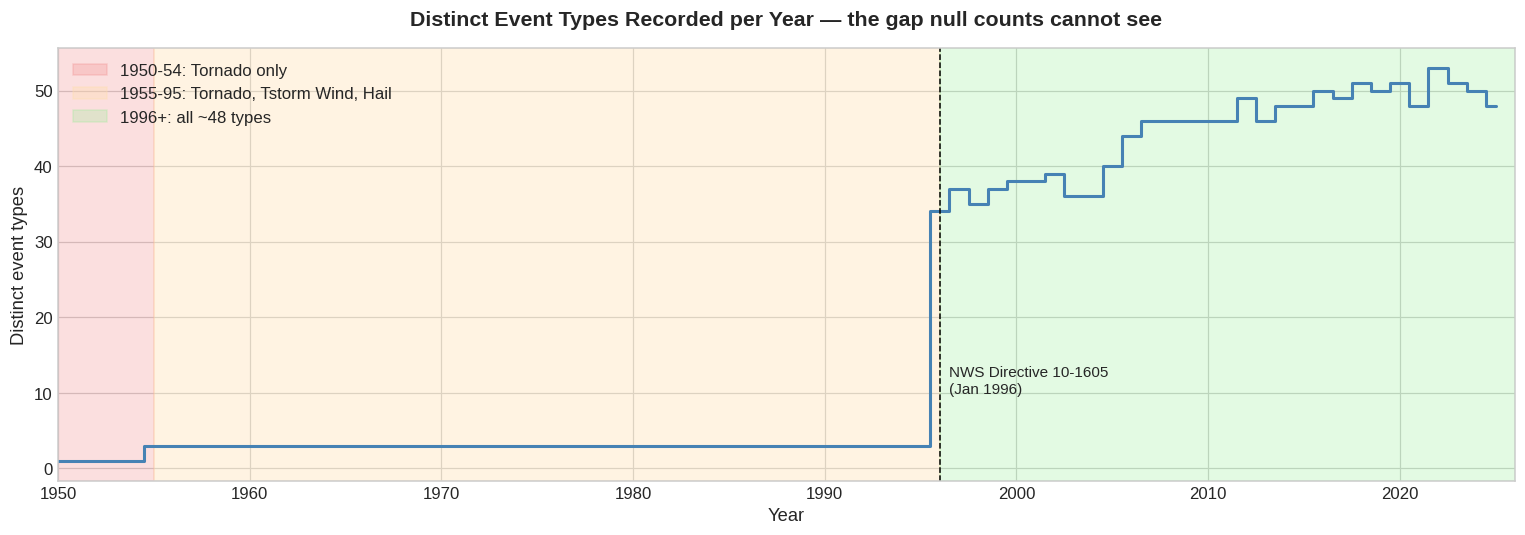

In [6]:
# Count how many distinct event types are recorded each year
types_per_year = (
    df.groupby("YEAR")["EVENT_TYPE"].nunique()
    .reset_index(name="distinct_types")
    .sort_values("YEAR")
)

plt.figure(figsize=(14, 5))

# Shade the three collection regimes
plt.axvspan(1950, 1955, color="lightcoral", alpha=0.25, label="1950-54: Tornado only")
plt.axvspan(1955, 1996, color="navajowhite", alpha=0.35, label="1955-95: Tornado, Tstorm Wind, Hail")
plt.axvspan(1996, 2026, color="lightgreen", alpha=0.25, label="1996+: all ~48 types")

# Step line of distinct event types per year
plt.step(types_per_year["YEAR"], types_per_year["distinct_types"],
         where="mid", color="steelblue", linewidth=2)

# Mark the regime change
plt.axvline(1996, color="black", linestyle="--", linewidth=1)
plt.text(1996.5, 10, "NWS Directive 10-1605\n(Jan 1996)", fontsize=10)

plt.title("Distinct Event Types Recorded per Year — the gap null counts cannot see",
          fontsize=14, pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Distinct event types", fontsize=12)
plt.legend(loc="upper left")
plt.xlim(1950, 2026)

plt.tight_layout()
plt.show()

## Consistency check — coverage per event group

Each event belongs to one of 17 **event groups**. Before any deeper analysis we take a quick look at how much history each group actually carries: the number of recorded events and the first and last year in which the group appears. Groups whose record only starts in 1996 reflect the NWS reporting change (Directive 10-1605), not a real absence of such events before then.

In [7]:
summary = (
    df.groupby('EVENT_GROUP', as_index=False)
      .agg(n_rows=('EVENT_ID', 'size'),
           start_year=('YEAR', 'min'),
           end_year=('YEAR', 'max'))
      .rename(columns={'EVENT_GROUP': 'event_group'})
      .sort_values('n_rows', ascending=False)
      .reset_index(drop=True)
)
summary

,event_group,n_rows,start_year,end_year
0,Thunderstorm,1032841,1955,2025
1,Winter_Storm,281745,1996,2025
2,Flooding,180665,1996,2025
3,High_Wind,168015,1996,2025
4,Tornado,90255,1950,2025
5,Drought,81383,1996,2025
6,Extreme_Heat,56077,1996,2025
7,Cold,51750,1996,2025
8,Coastal_Flood,24208,1996,2025
9,Dust,19738,1996,2025


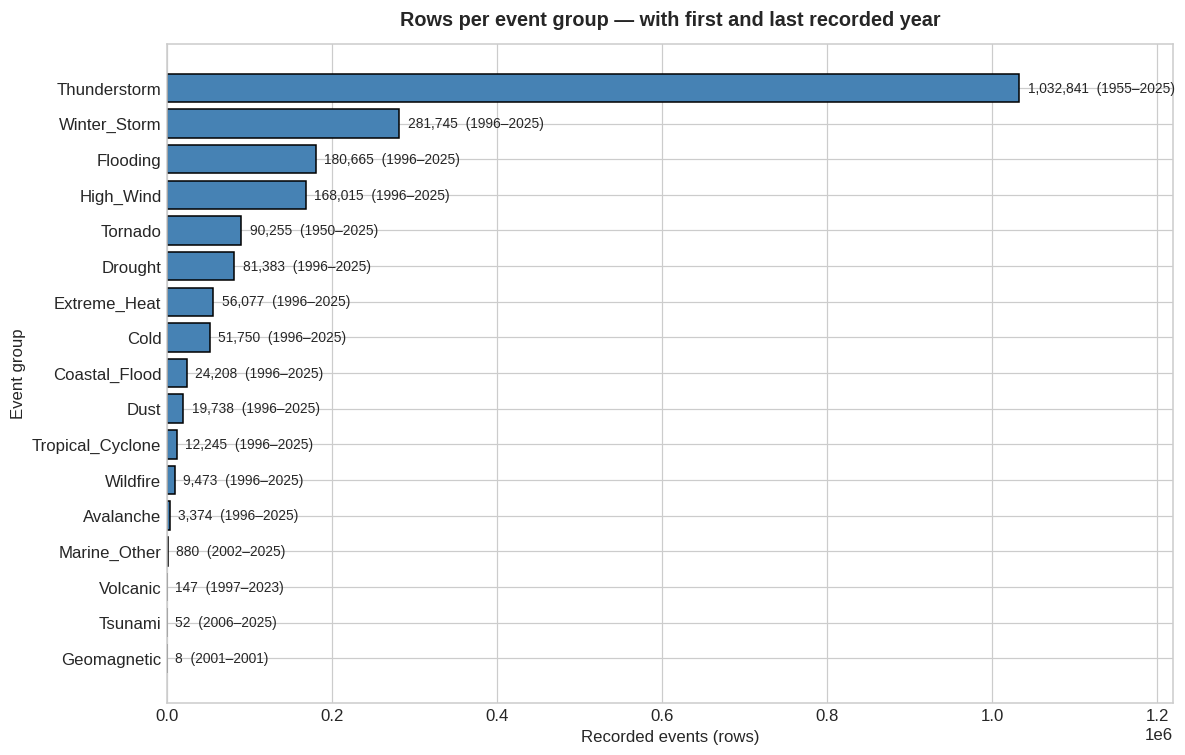

In [8]:
# Barplot: rows per event group, labeled with the recorded year range
plot_df = summary.sort_values('n_rows', ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(plot_df['event_group'], plot_df['n_rows'],
               color='steelblue', edgecolor='black')

ax.set_xlabel('Recorded events (rows)')
ax.set_ylabel('Event group')
ax.set_title('Rows per event group — with first and last recorded year',
             fontsize=13, pad=12)

ax.set_xlim(0, plot_df['n_rows'].max() * 1.18)

for bar, (_, r) in zip(bars, plot_df.iterrows()):
    ax.text(bar.get_width() + plot_df['n_rows'].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{int(r['n_rows']):,}  ({r['start_year']}–{r['end_year']})",
            va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.show()

## Build new features

In [9]:
# Distance of the event
def haversine_distance(lat1, lon1, lat2, lon2, radius_km=6371.0):
    lat1, lon1, lat2, lon2 = (np.radians(np.asarray(v, dtype='float64'))
                              for v in (lat1, lon1, lat2, lon2))
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2.0 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))
    return radius_km * c

In [10]:
# Created year, month, day, time begin/end feature
df_1 = df.copy()
df_1['YEAR_BEGIN'] = pd.DatetimeIndex(df_1['BEGIN_DATE_TIME']).year
df_1['MONTH_BEGIN'] = pd.DatetimeIndex(df_1['BEGIN_DATE_TIME']).month
df_1['DAY_BEGIN'] = pd.DatetimeIndex(df_1['BEGIN_DATE_TIME']).day
df_1['HOUR_BEGIN'] = pd.DatetimeIndex(df_1['BEGIN_DATE_TIME']).hour
df_1['YEAR_BEGIN']= df_1["YEAR_BEGIN"].astype("int64")
df_1['MONTH_BEGIN']= df_1["MONTH_BEGIN"].astype("int64")
df_1['DAY_BEGIN']= df_1["DAY_BEGIN"].astype("int64")
df_1['HOUR_BEGIN']= df_1["HOUR_BEGIN"].astype("int64")
df_1['YEAR_END'] = pd.DatetimeIndex(df_1['END_DATE_TIME']).year
df_1['MONTH_END'] = pd.DatetimeIndex(df_1['END_DATE_TIME']).month
df_1['DAY_END'] = pd.DatetimeIndex(df_1['END_DATE_TIME']).day
df_1['HOUR_END'] = pd.DatetimeIndex(df_1['END_DATE_TIME']).hour
df_1['YEAR_END']= df_1["YEAR_END"].astype("int64")
df_1['MONTH_END']= df_1["MONTH_END"].astype("int64")
df_1['DAY_END']= df_1["DAY_END"].astype("int64")
df_1['HOUR_END']= df_1["HOUR_END"].astype("int64")

# Calculate the difference between dates and convert it to days and hours
df_1['DAY_DURATION'] = (df_1['END_DATE_TIME'] - df_1['BEGIN_DATE_TIME']).dt.days
df_1['HOUR_DURATION'] = (df_1['END_DATE_TIME'] - df_1['BEGIN_DATE_TIME']).dt.total_seconds() / 3600

# Merge Origin and Destination to have a look at the round event
df_1['LOCATION_ORIGIN_DESTINATION'] = df_1['BEGIN_LOCATION']+'-'+df_1['END_LOCATION']

# Distance
df_1['DISTANCE'] = haversine_distance(df_1['BEGIN_LAT'], df_1['BEGIN_LON'],
                                      df_1['END_LAT'],   df_1['END_LON'])


In [11]:
# ── Target registry used across the notebook ─────────────────────────
INJURY_TARGETS = ['INJURIES_DIRECT', 'INJURIES_INDIRECT']
DEATH_TARGETS  = ['DEATHS_DIRECT',   'DEATHS_INDIRECT']
DAMAGE_TARGETS = ['DAMAGE_PROPERTY', 'DAMAGE_CROPS']
TARGETS=INJURY_TARGETS+DEATH_TARGETS+DAMAGE_TARGETS
print('Target variables:', TARGETS)


Target variables: ['INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT', 'DEATHS_INDIRECT', 'DAMAGE_PROPERTY', 'DAMAGE_CROPS']


## Dataset overview

In [12]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2012856 entries, 1950-04-28 14:45:00 to 2025-09-09 18:58:00
Data columns (total 70 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   EVENT_ID                     int64         
 1   STATE                        object        
 2   YEAR                         int64         
 3   MONTH_NAME                   object        
 4   EVENT_TYPE                   object        
 5   CZ_TYPE                      object        
 6   CZ_FIPS                      int64         
 7   CZ_NAME                      object        
 8   WFO                          object        
 9   BEGIN_DATE_TIME              datetime64[ns]
 10  CZ_TIMEZONE                  object        
 11  END_DATE_TIME                datetime64[ns]
 12  INJURIES_DIRECT              int64         
 13  INJURIES_INDIRECT            int64         
 14  DEATHS_DIRECT                int64         
 15  DEATHS_INDIRECT 

In [13]:
# Numerical variables
num_cols = [c for c in df_1.columns if pd.api.types.is_numeric_dtype(df_1[c])]
num = df_1[num_cols]
num.describe().T.style.format('{:,.2f}')

,count,mean,std,min,25%,50%,75%,max
EVENT_ID,"2,012,856.00","3,051,355.15","3,786,457.37",3.00,"532,394.75","1,061,972.50","5,452,187.25","990,000,013.00"
YEAR,"2,012,856.00","2,008.14",12.83,"1,950.00","2,001.00","2,010.00","2,018.00","2,025.00"
CZ_FIPS,"2,012,856.00",98.10,118.26,0.00,26.00,65.00,119.00,876.00
INJURIES_DIRECT,"2,012,856.00",0.08,3.58,0.00,0.00,0.00,0.00,"1,700.00"
INJURIES_INDIRECT,"2,012,856.00",0.01,1.80,0.00,0.00,0.00,0.00,"2,400.00"
DEATHS_DIRECT,"2,012,856.00",0.01,0.59,0.00,0.00,0.00,0.00,638.00
DEATHS_INDIRECT,"2,012,856.00",0.00,0.09,0.00,0.00,0.00,0.00,56.00
DAMAGE_PROPERTY,"2,012,856.00","299,088.07","29,614,811.57",0.00,0.00,0.00,0.00,"17,900,000,000.00"
DAMAGE_CROPS,"2,012,856.00","35,134.92","2,444,142.56",0.00,0.00,0.00,0.00,"1,500,000,000.00"
MAGNITUDE,"2,012,856.00",16.58,29.67,0.00,0.00,0.88,50.00,"22,000.00"


In [14]:
# Categorical variables
class_cols = [c for c in df_1.columns if pd.api.types.is_string_dtype(df_1[c])]
cat = df_1[class_cols]
cat.describe().T

,count,unique,top,freq
STATE,2012856,70,TEXAS,162357
MONTH_NAME,2012856,12,June,298913
EVENT_TYPE,2012856,56,Thunderstorm Wind,564181
CZ_TYPE,2012856,3,C,1290710
CZ_NAME,2012856,5843,WASHINGTON,16641
WFO,2012856,541,LWX,56665
CZ_TIMEZONE,2012856,29,CST-6,581226
SOURCE,2012856,57,Unknown,352611
FLOOD_CAUSE,2012856,9,Not Applicable,1832191
BEGIN_LOCATION,2012856,65021,COUNTYWIDE,78748


In [15]:
cardinality = cat.nunique()
print(cardinality)

STATE                               70
MONTH_NAME                          12
EVENT_TYPE                          56
CZ_TYPE                              3
CZ_NAME                           5843
WFO                                541
CZ_TIMEZONE                         29
SOURCE                              57
FLOOD_CAUSE                          9
BEGIN_LOCATION                   65021
END_LOCATION                     53767
EPISODE_NARRATIVE               555795
EVENT_NARRATIVE                1832118
DATA_SOURCE                          5
EVENT_GROUP                         17
risk                                 3
impact_type                          5
event_scope                          4
LOCATION_ORIGIN_DESTINATION     150914
dtype: int64


In [16]:
# data variables
date_cols = [cname for cname in df_1.columns if
             df_1[cname].dtype in ['datetime64[ns]']]
date_dist = df_1[date_cols]
date_dist.describe().T

,count,mean,min,25%,50%,75%,max
BEGIN_DATE_TIME,2012856,2008-08-05 21:10:20.058484736,1950-01-03 11:00:00,2001-07-10 16:58:45,2010-06-21 10:50:30,2018-07-04 17:05:30,2025-12-31 23:40:00
END_DATE_TIME,2012856,2008-08-07 09:57:00.149191424,1950-01-03 11:00:00,2001-07-11 18:23:00,2010-06-21 20:49:30,2018-07-06 11:35:15,2025-12-31 23:59:00


## Target variable profiles

In [17]:
def statistics(data, targets):
    rows = []
    for var in targets:
        s = data[var].dropna()
        rows.append({
            'target'   : var,
            'count'    : f'{s.shape[0]:,}',
            'mean'     : s.mean(),
            'std'      : s.std(),
            'max'      : s.max(),
            'skewness' : skew(s),
            'kurtosis' : kurtosis(s),
        })
    return pd.DataFrame(rows).set_index('target')

statistics(df_1, TARGETS).style.format({'mean':'{:,.3f}','std':'{:,.2f}','max':'{:,.0f}','skewness':'{:,.1f}','kurtosis':'{:,.1f}'})

,count,mean,std,max,skewness,kurtosis
target,,,,,,
INJURIES_DIRECT,"2,012,856",0.081,3.58,"1,700",184.2,"54,371.8"
INJURIES_INDIRECT,"2,012,856",0.008,1.80,"2,400","1,202.2","1,586,736.8"
DEATHS_DIRECT,"2,012,856",0.012,0.59,638,686.9,"703,536.3"
DEATHS_INDIRECT,"2,012,856",0.002,0.09,56,193.4,"81,703.1"
DAMAGE_PROPERTY,"2,012,856","299,088.070","29,614,811.57","17,900,000,000",332.4,"153,275.2"
DAMAGE_CROPS,"2,012,856","35,134.915","2,444,142.56","1,500,000,000",279.3,"118,716.8"


### Check target series stationarity

- **ADF** (Augmented Dickey–Fuller) — H0: *the series has a unit root (non-stationary)*. A small p-value (< 0.05) lets us **reject** H0 → evidence of **stationarity**.
- **KPSS** (Kwiatkowski–Phillips–Schmidt–Shin) — H0: *the series is stationary*. A small p-value (< 0.05) lets us **reject** H0 → evidence of **non-stationarity**.

When the two tests **disagree**, the combination still names the case:
- ADF *stationary* + KPSS *non-stationary* → **trend-stationary** (remove a deterministic trend).
- ADF *unit root* + KPSS *stationary* → **difference-stationary** (differencing removes the drift).


In [18]:
# ── Stationarity of the monthly target series: ADF beside KPSS ───────
ts_window = df_1[df_1['YEAR'] >= 1996]

def stationarity_tests(values, name, regression='c'):
    x = np.asarray(values, dtype=float)
    x = x[~np.isnan(x)]
    # ADF — H0: unit root (non-stationary)
    adf_stat, adf_p, *_ = adfuller(x, regression=regression, autolag='AIC')
    # KPSS — H0: stationary  (p-values are clipped/interpolated -> silence the warning)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(x, regression=regression, nlags='auto')

    return {
        'target'    : name,
        'ADF_stat'  : round(adf_stat, 4),
        'ADF_p'     : round(adf_p, 4),
        'ADF_says'  : 'stationary' if adf_p < 0.05 else 'non-stationary',
        'KPSS_stat' : round(kpss_stat, 4),
        'KPSS_p'    : round(kpss_p, 4),
        'KPSS_says' : 'stationary' if kpss_p >= 0.05 else 'non-stationary',
    }

rows = []
for t in TARGETS:
    # monthly total per target — plain groupby (Modin's .resample raises the 'convention' error)
    monthly = ts_window.groupby(['YEAR', 'MONTH_BEGIN'])[t].sum().to_numpy()
    rows.append(stationarity_tests(monthly, t))

stationarity = pd.DataFrame(rows).set_index('target')
stationarity

,ADF_stat,ADF_p,ADF_says,KPSS_stat,KPSS_p,KPSS_says
target,,,,,,
INJURIES_DIRECT,-8.6753,0.0000,stationary,0.8455,0.0100,non-stationary
INJURIES_INDIRECT,-7.2317,0.0000,stationary,0.4462,0.0572,stationary
DEATHS_DIRECT,-4.4664,0.0002,stationary,0.1567,0.1000,stationary
DEATHS_INDIRECT,-1.4699,0.5484,non-stationary,2.9258,0.0100,non-stationary
DAMAGE_PROPERTY,-15.9291,0.0000,stationary,0.1152,0.1000,stationary
DAMAGE_CROPS,-17.2555,0.0000,stationary,0.3282,0.1000,stationary


### Temporal Analysis

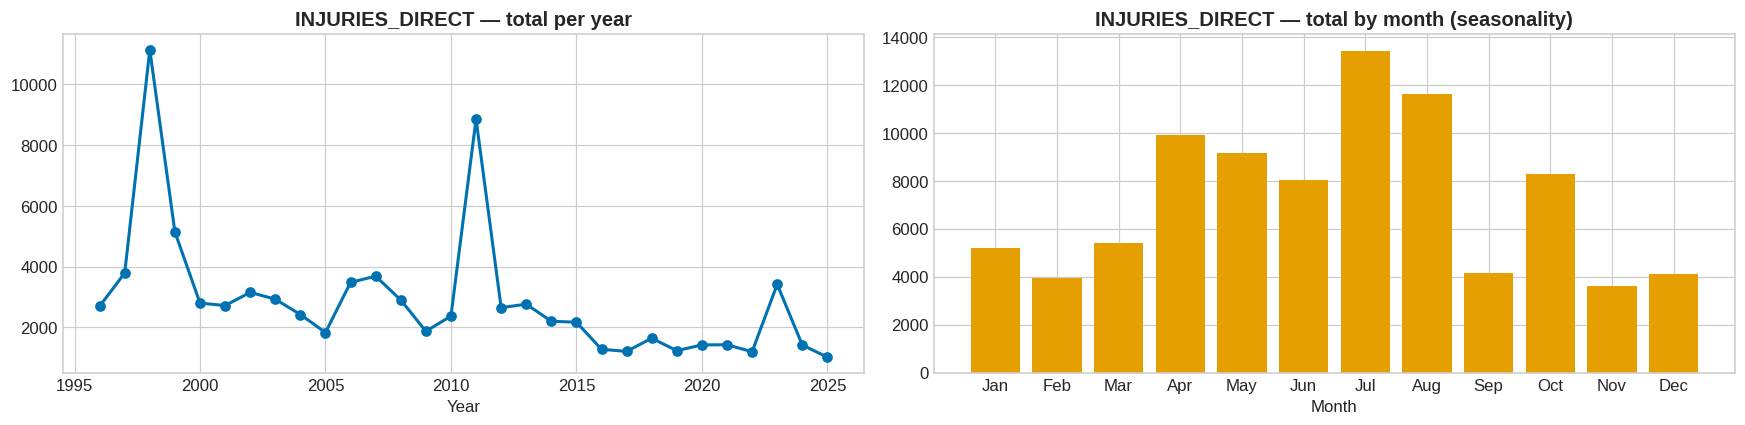

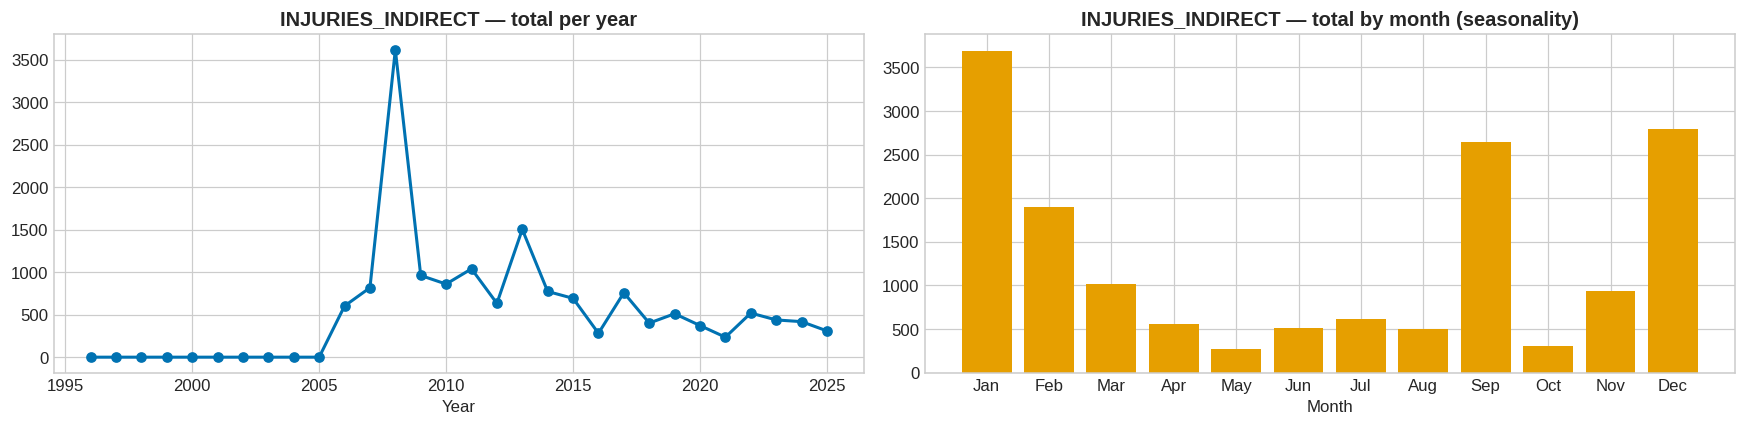

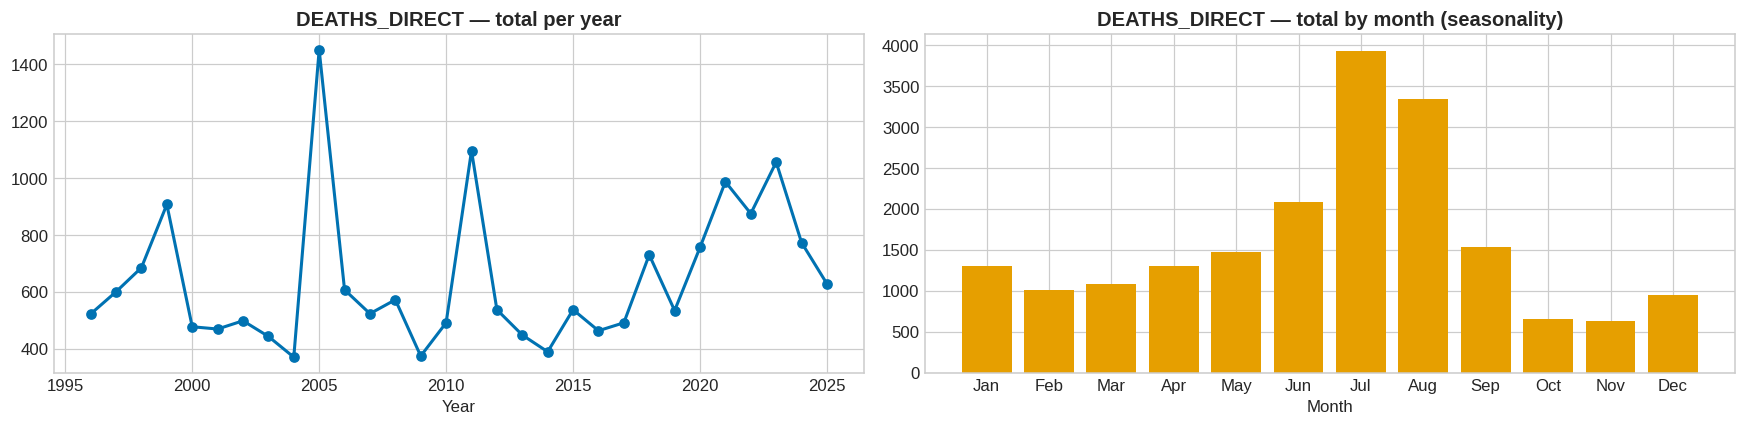

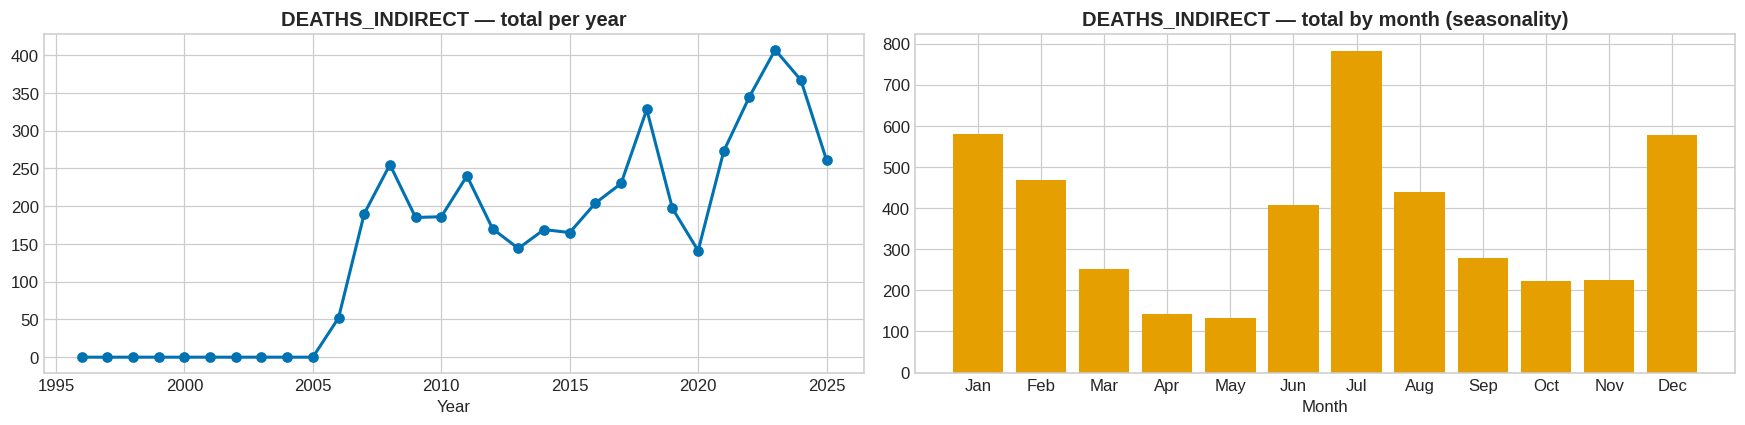

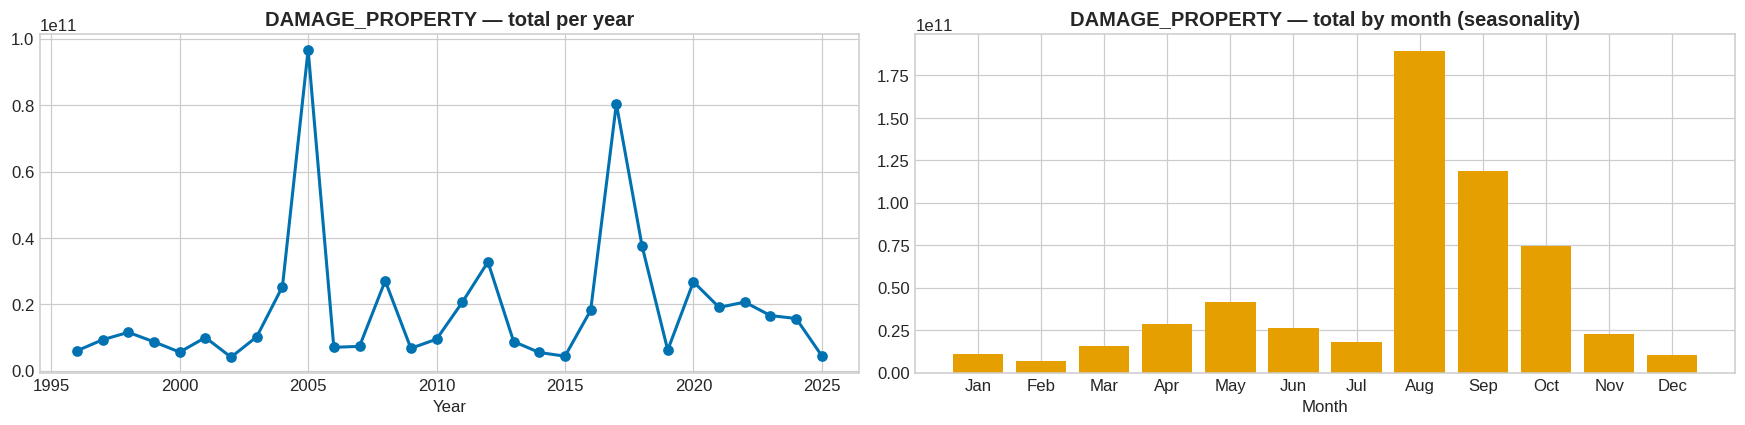

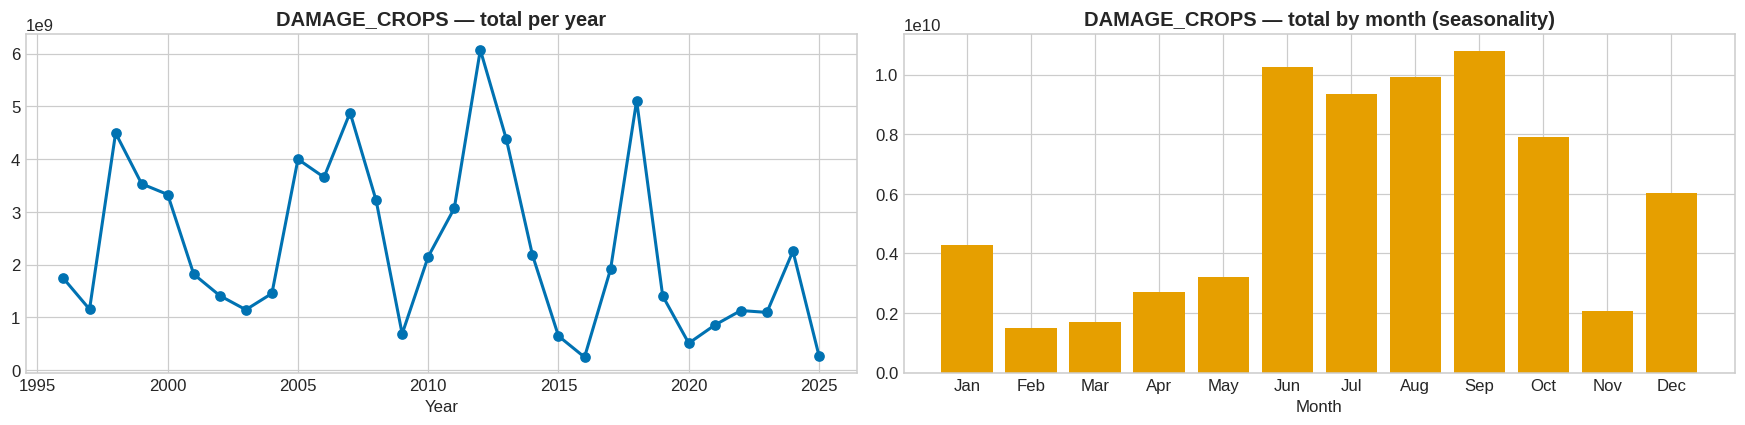

In [19]:
df_ts = df_1[df_1['YEAR'] >= 1996].copy()

MONTH_ORDER = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

def target_year_month(data, target):
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    # Yearly total
    yearly = data.groupby('YEAR')[target].sum()
    axes[0].plot(yearly.index, yearly.values, marker='o', color='#0072B2', lw=2)
    axes[0].set_title(f'{target} — total per year'); axes[0].set_xlabel('Year')
    # Monthly seasonality (summed then averaged shape)
    monthly = data.groupby('MONTH_BEGIN')[target].sum().reindex(range(1, 13))
    axes[1].bar(MONTH_ORDER, monthly.values, color='#E69F00')
    axes[1].set_title(f'{target} — total by month (seasonality)'); axes[1].set_xlabel('Month')
    plt.tight_layout()
    plt.show()

for t in TARGETS:
    target_year_month(df_ts, t)

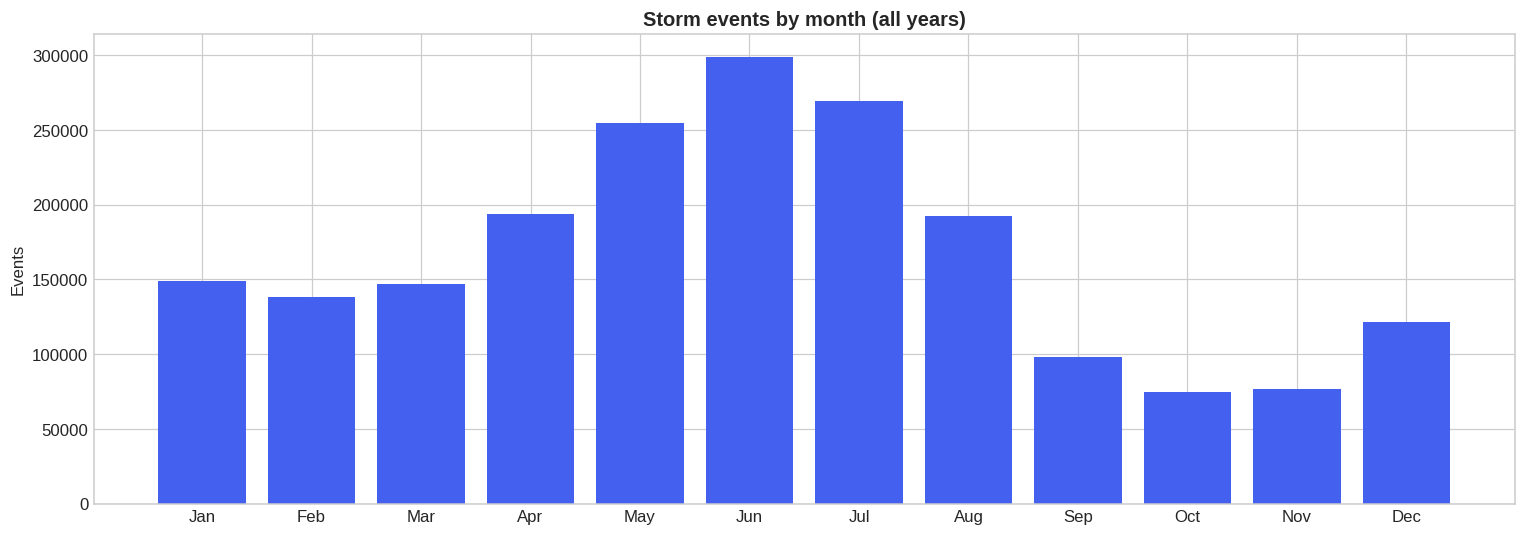

In [20]:
# Monthly seasonality of event counts
monthly_counts = df_1['MONTH_BEGIN'].value_counts().reindex(range(1, 13))
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(MONTH_ORDER, monthly_counts.values, color='#4361ee')
ax.set_title('Storm events by month (all years)')
ax.set_ylabel('Events')
plt.tight_layout()
plt.show()

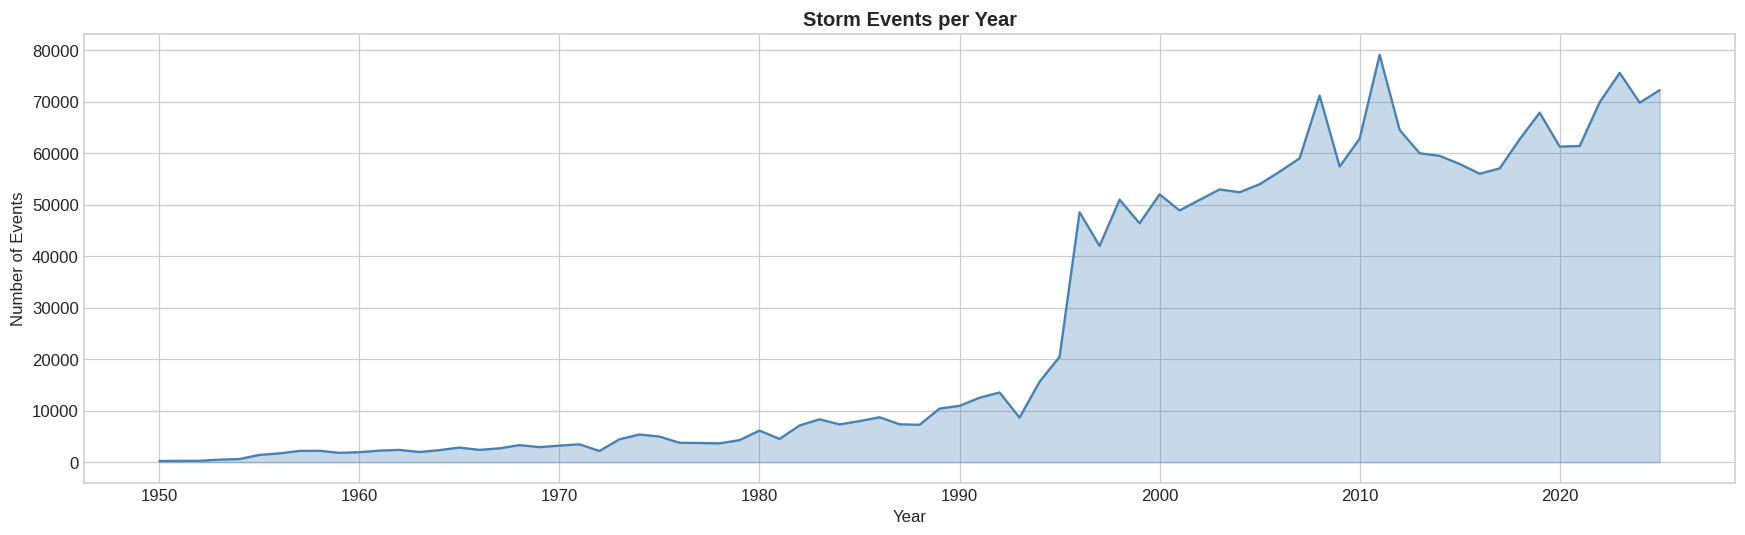

In [21]:
# ── Events per Year ──────────────────────────────────
events_year = df_1['YEAR'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(events_year.index, events_year.values, alpha=0.3, color='steelblue')
ax.plot(events_year.index, events_year.values, color='steelblue', linewidth=1.5)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Events')
ax.set_title('Storm Events per Year')
plt.tight_layout()
plt.show()

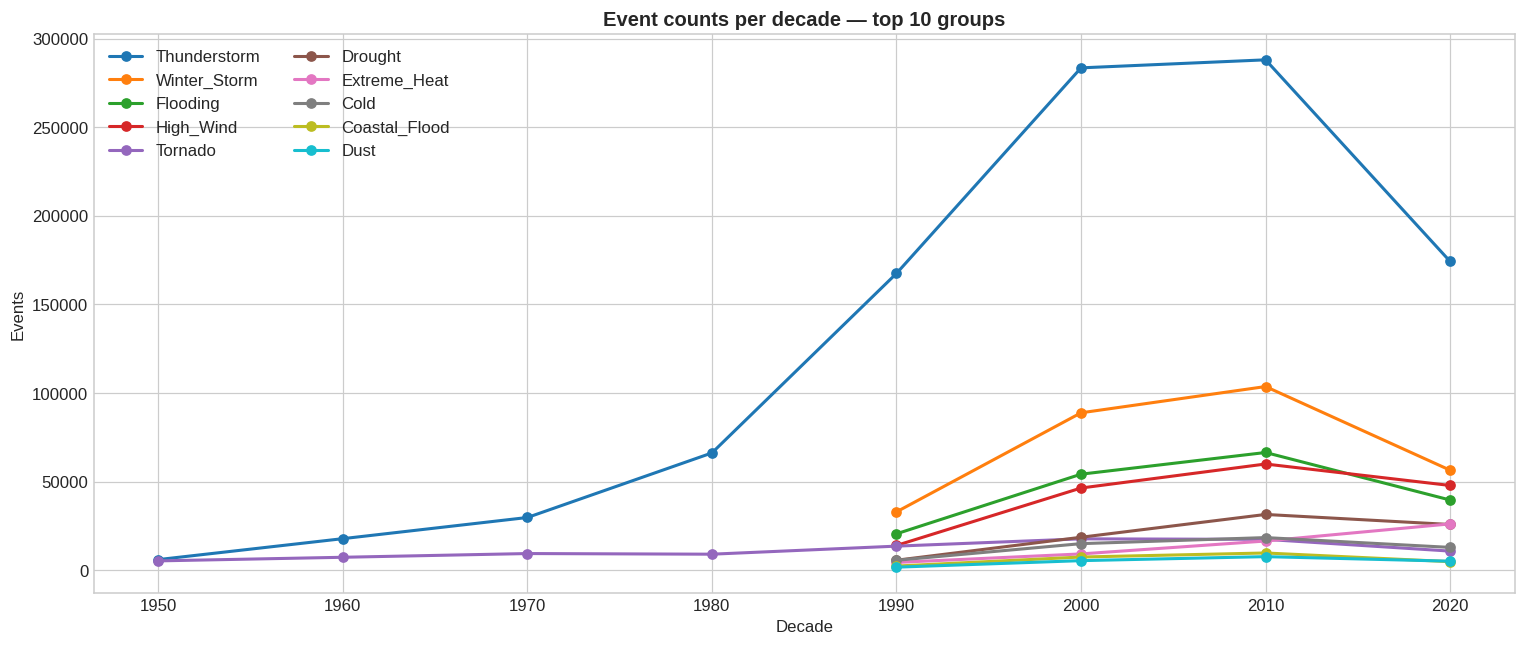

In [22]:
# Decade trend of the top-10 event groups
top10 = df_1['EVENT_GROUP'].value_counts().head(10).index.tolist()
dfd = df_1[df_1['EVENT_GROUP'].isin(top10)].copy()
dfd['DECADE'] = (dfd['YEAR'] // 10) * 10
trend = dfd.pivot_table(index='DECADE', columns='EVENT_GROUP', values='EVENT_ID', aggfunc='count')

colors = plt.get_cmap('tab10').colors
fig, ax = plt.subplots(figsize=(14, 6))
for g, c in zip(top10, colors):
    ax.plot(trend.index, trend[g], marker='o', lw=2, label=g, color=c)
ax.set_title('Event counts per decade — top 10 groups')
ax.set_xlabel('Decade'); ax.set_ylabel('Events')
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

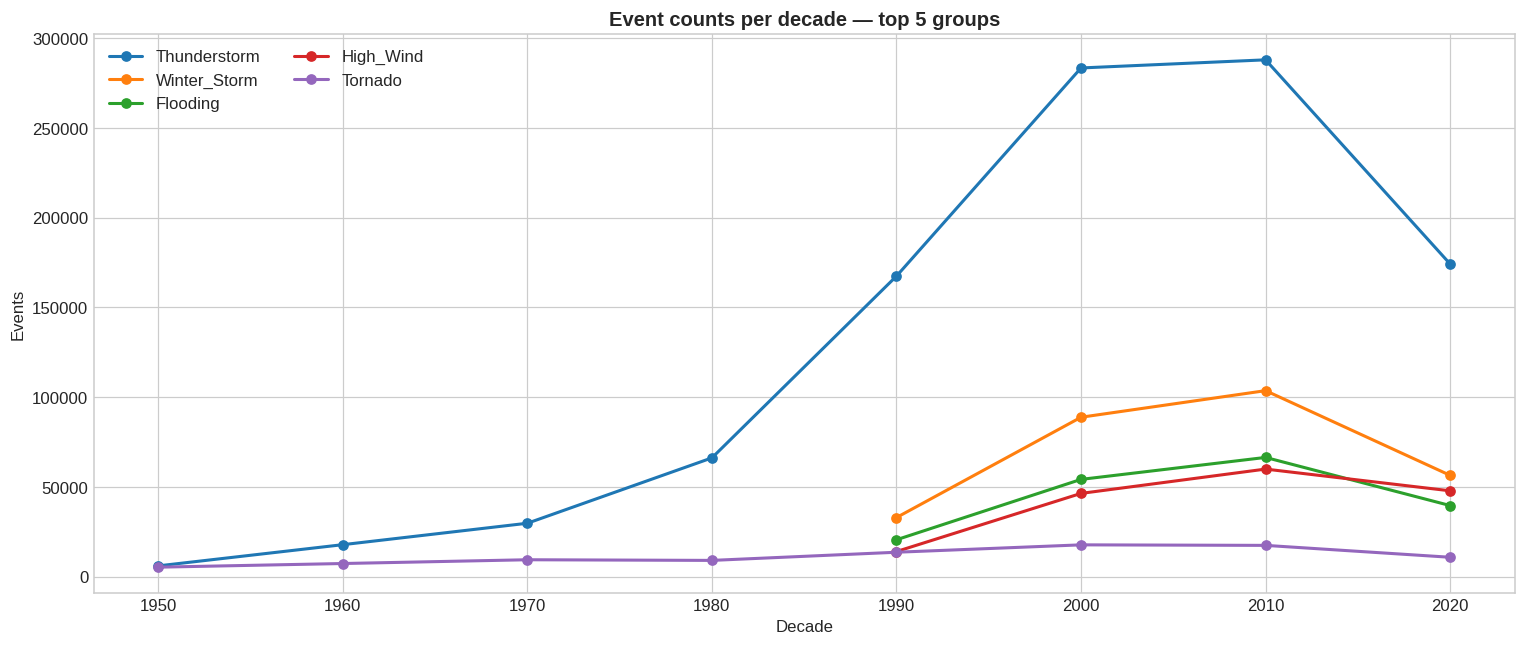

In [23]:
# Decade trend of the top-5 event groups
top5 = df_1['EVENT_GROUP'].value_counts().head(5).index.tolist()
dfd = df_1[df_1['EVENT_GROUP'].isin(top5)].copy()
dfd['DECADE'] = (dfd['YEAR'] // 10) * 10
trend = dfd.pivot_table(index='DECADE', columns='EVENT_GROUP', values='EVENT_ID', aggfunc='count')

colors = plt.get_cmap('tab10').colors
fig, ax = plt.subplots(figsize=(14, 6))
for g, c in zip(top5, colors):
    ax.plot(trend.index, trend[g], marker='o', lw=2, label=g, color=c)
ax.set_title('Event counts per decade — top 5 groups')
ax.set_xlabel('Decade'); ax.set_ylabel('Events')
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

### Seasonal Decomposition

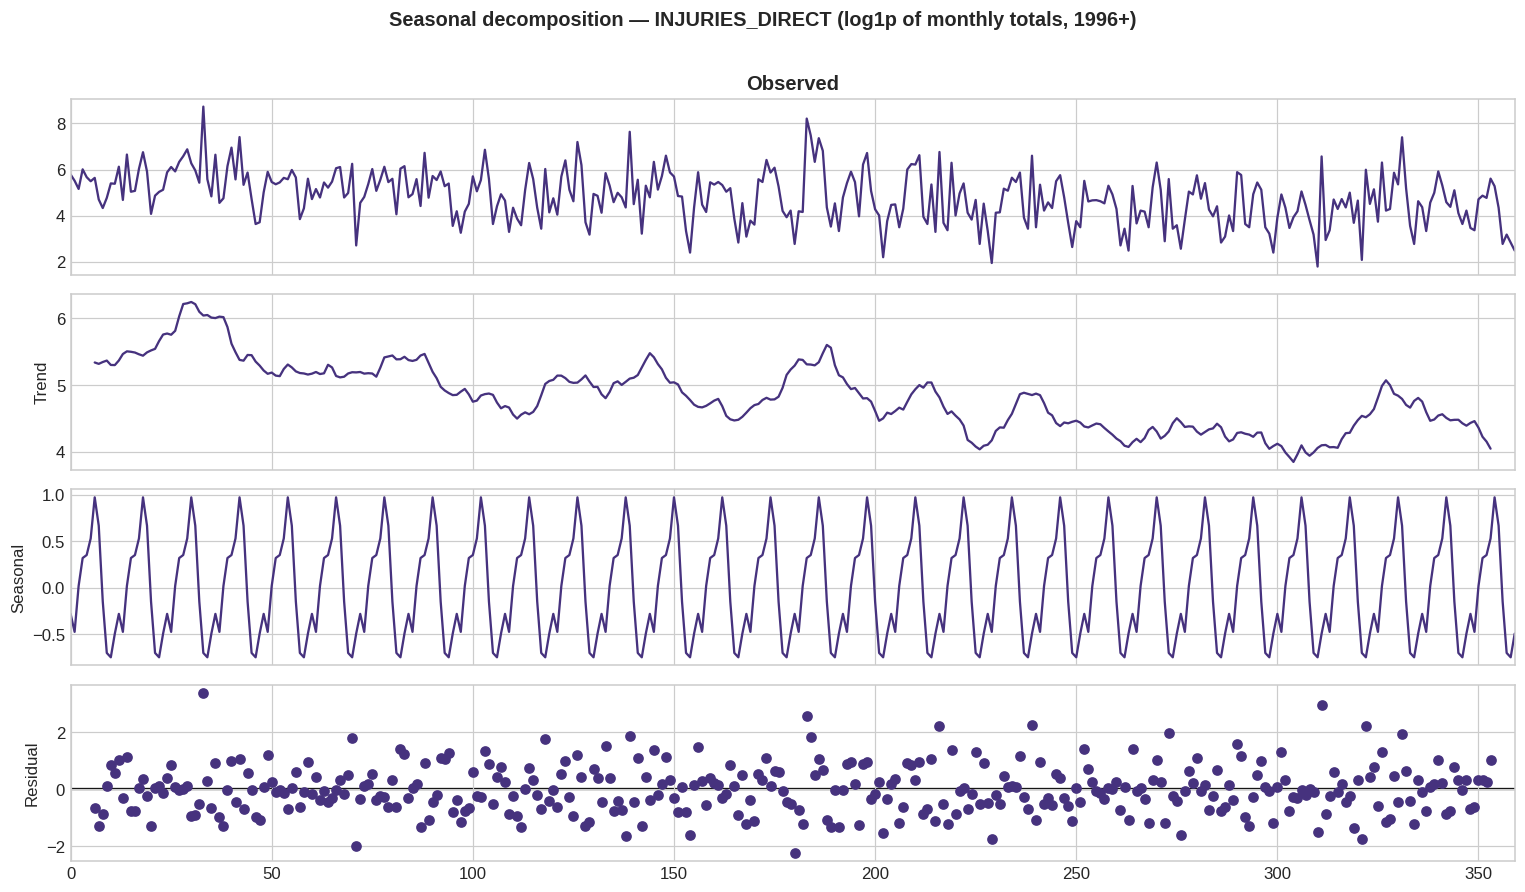

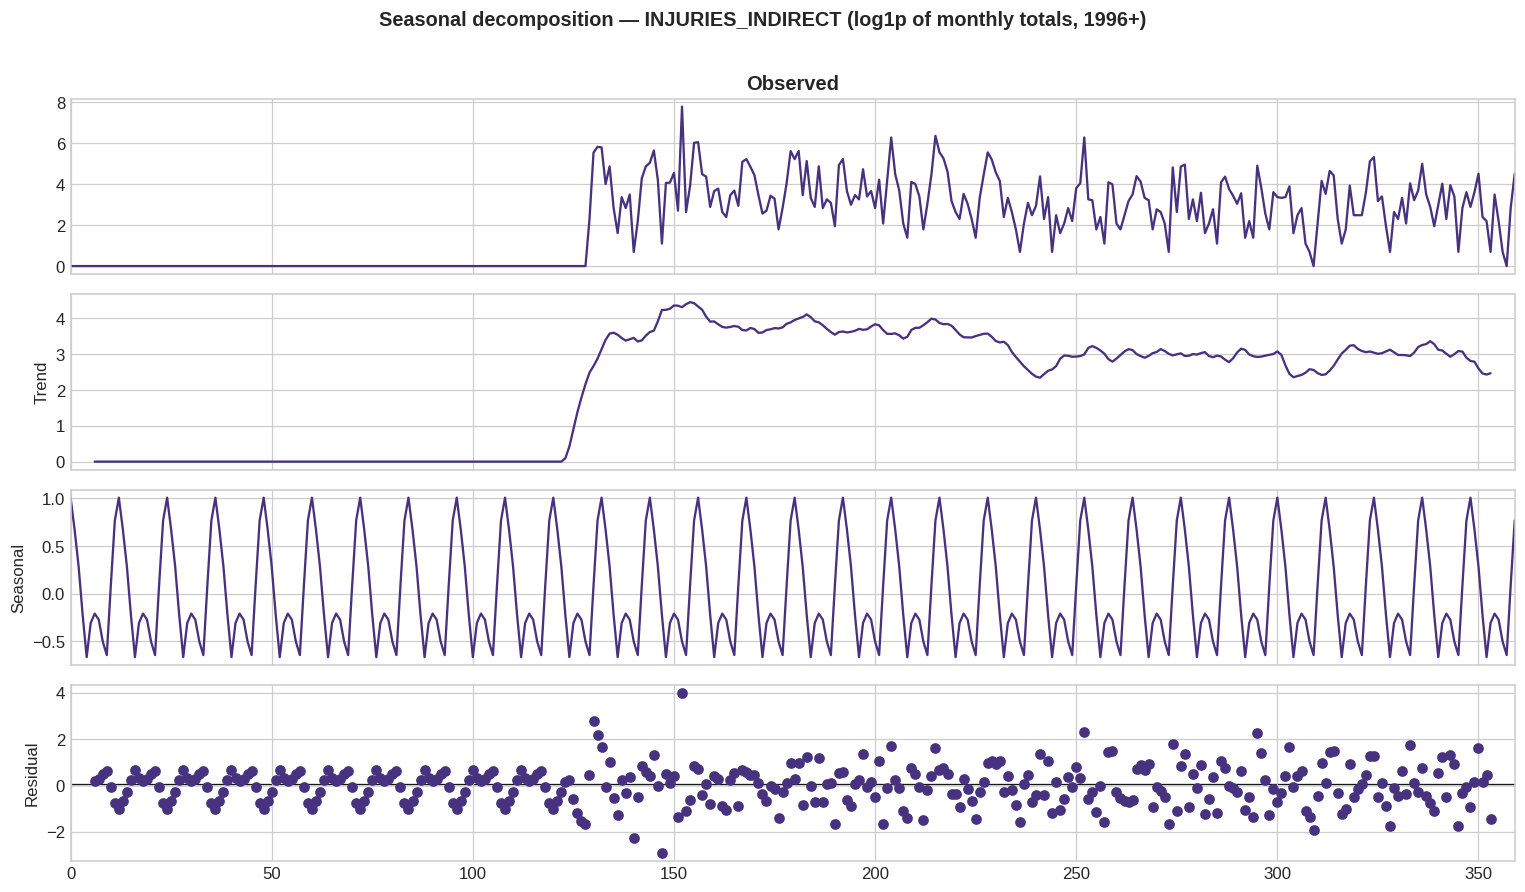

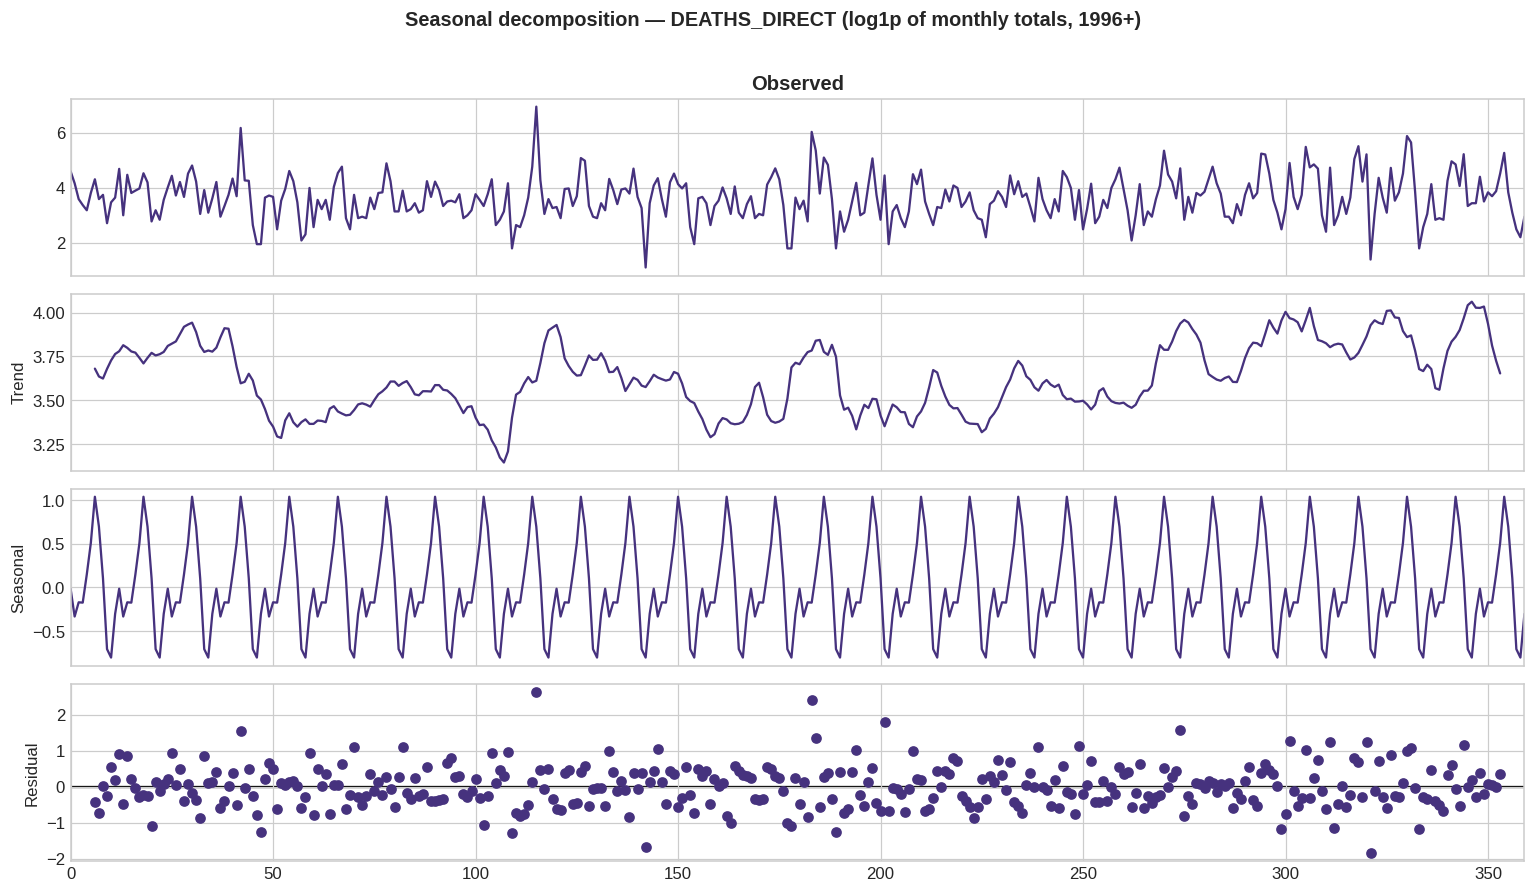

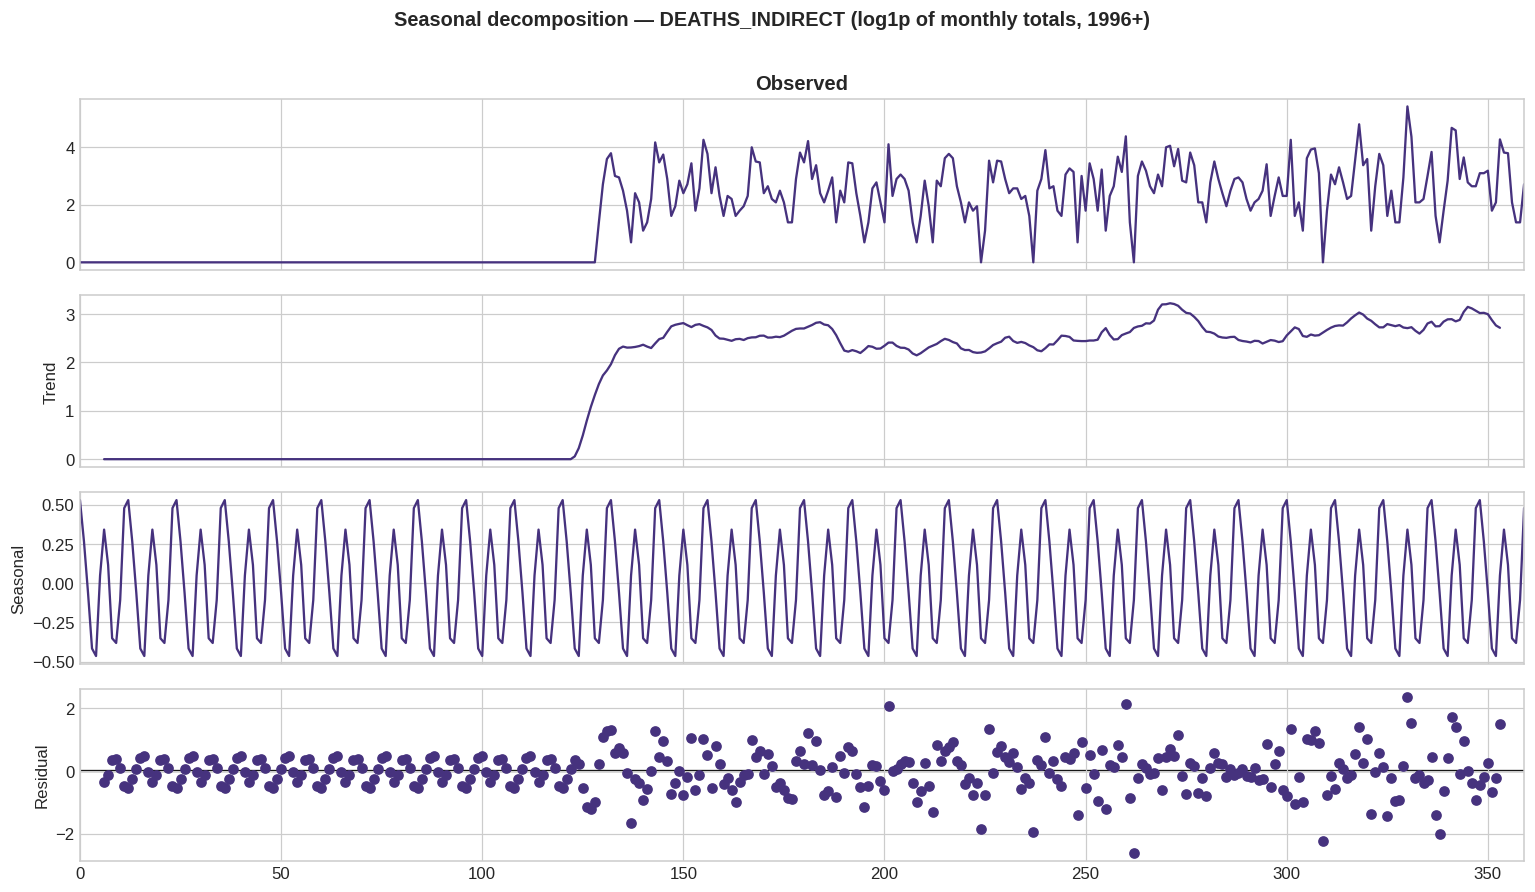

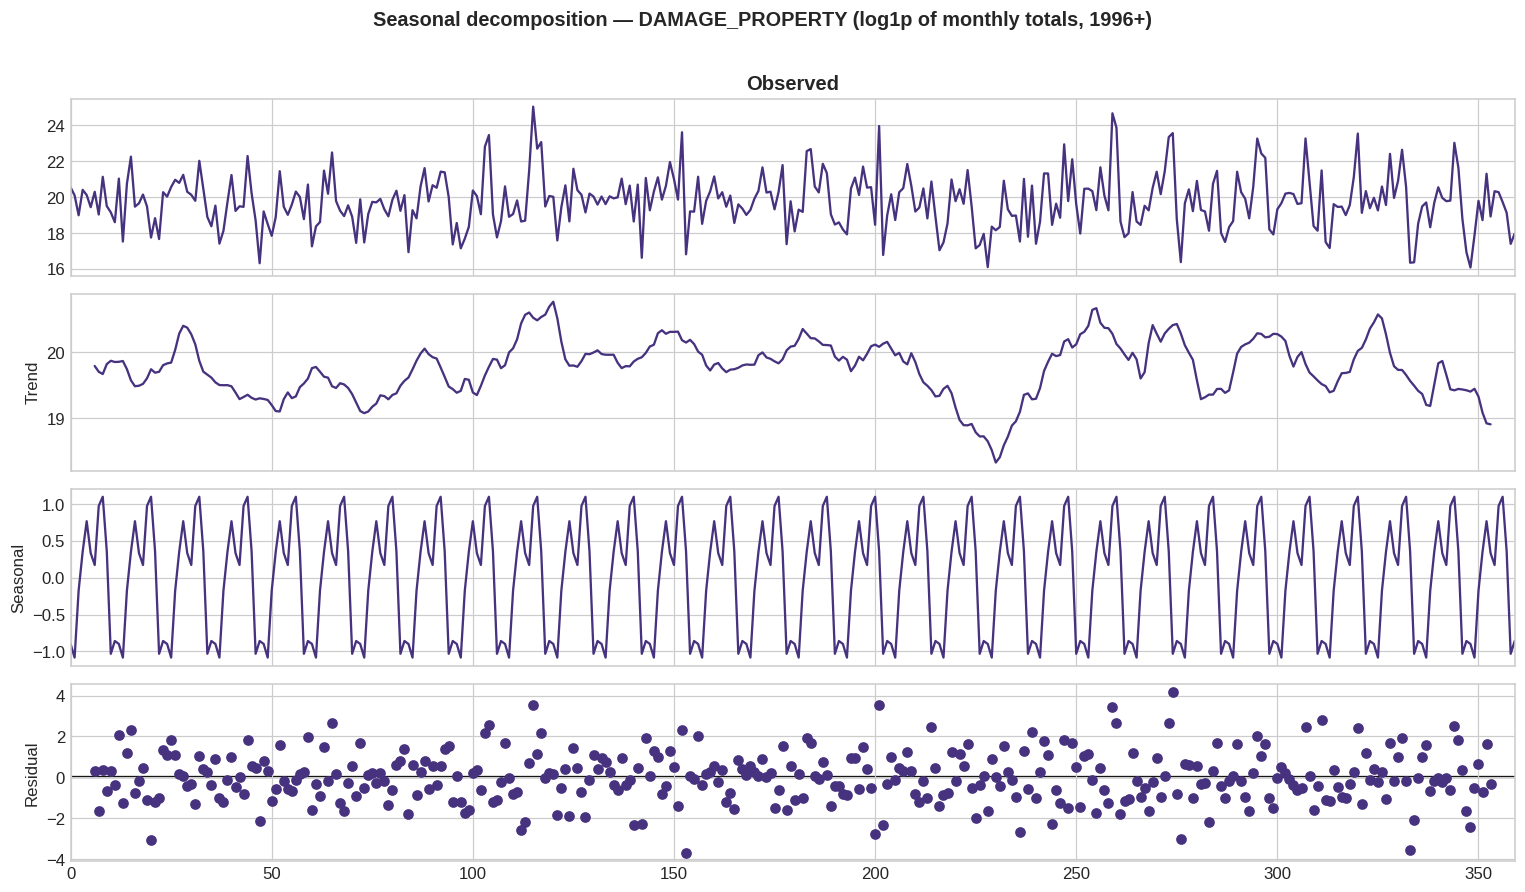

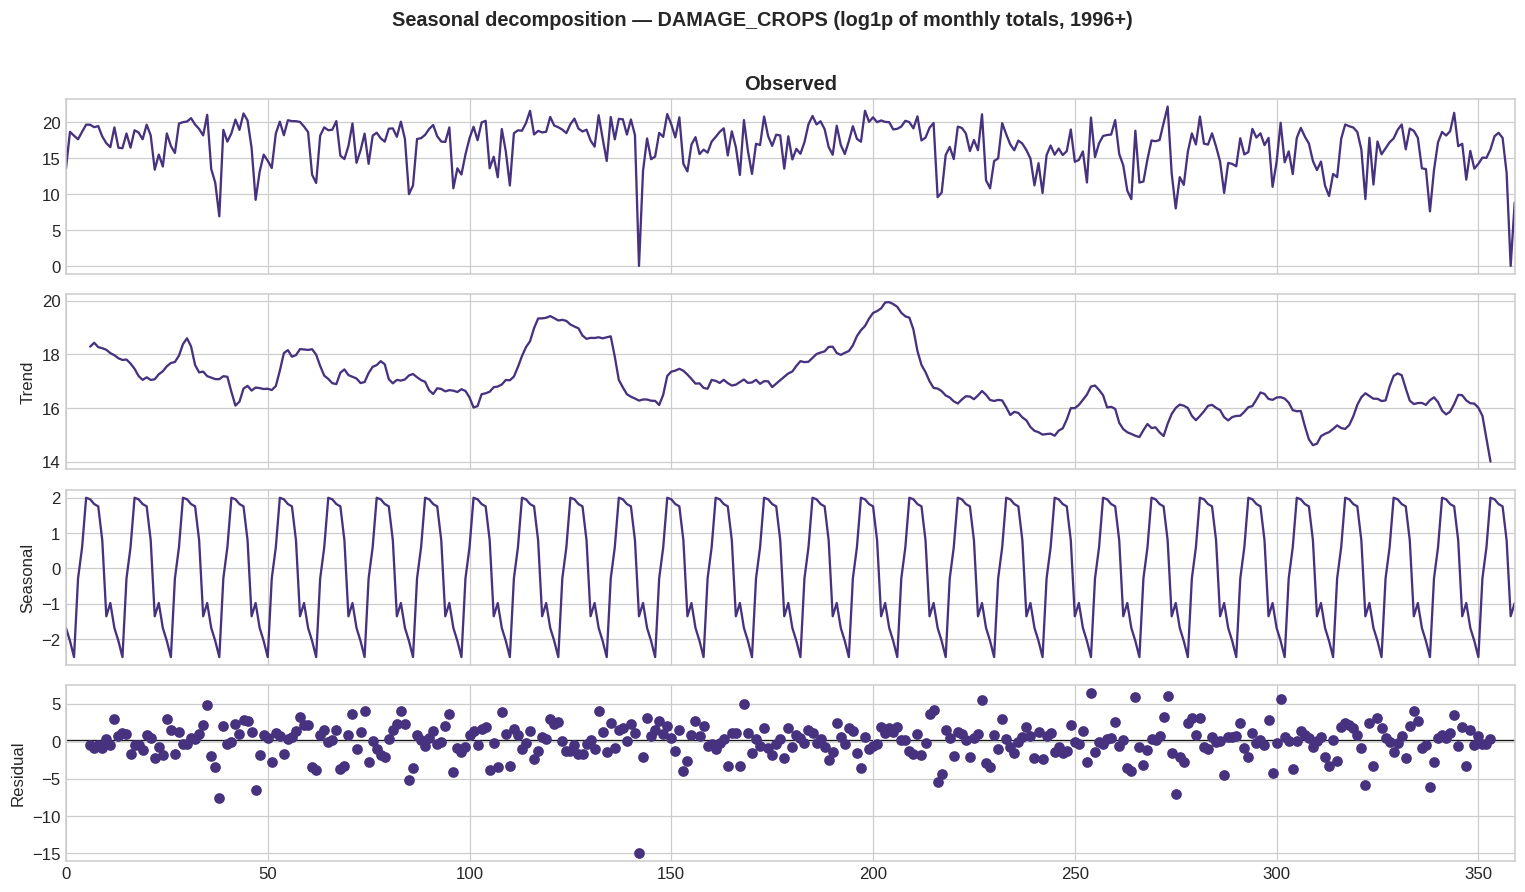

In [24]:
def decompose_target(data, target, period=12):
    monthly = data.groupby(['YEAR', 'MONTH_BEGIN'])[target].sum().to_numpy()
    monthly = np.log1p(monthly)          # log(t·s·r) = log t + log s + log r, and handles zeros
    result = seasonal_decompose(monthly, model='additive', period=period)
    fig = result.plot()
    fig.set_size_inches(14, 8)
    fig.suptitle(f'Seasonal decomposition — {target} (log1p of monthly totals, 1996+)',
                 y=1.01, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

for t in TARGETS:
    decompose_target(df_ts, t)

### Geographical Distribution

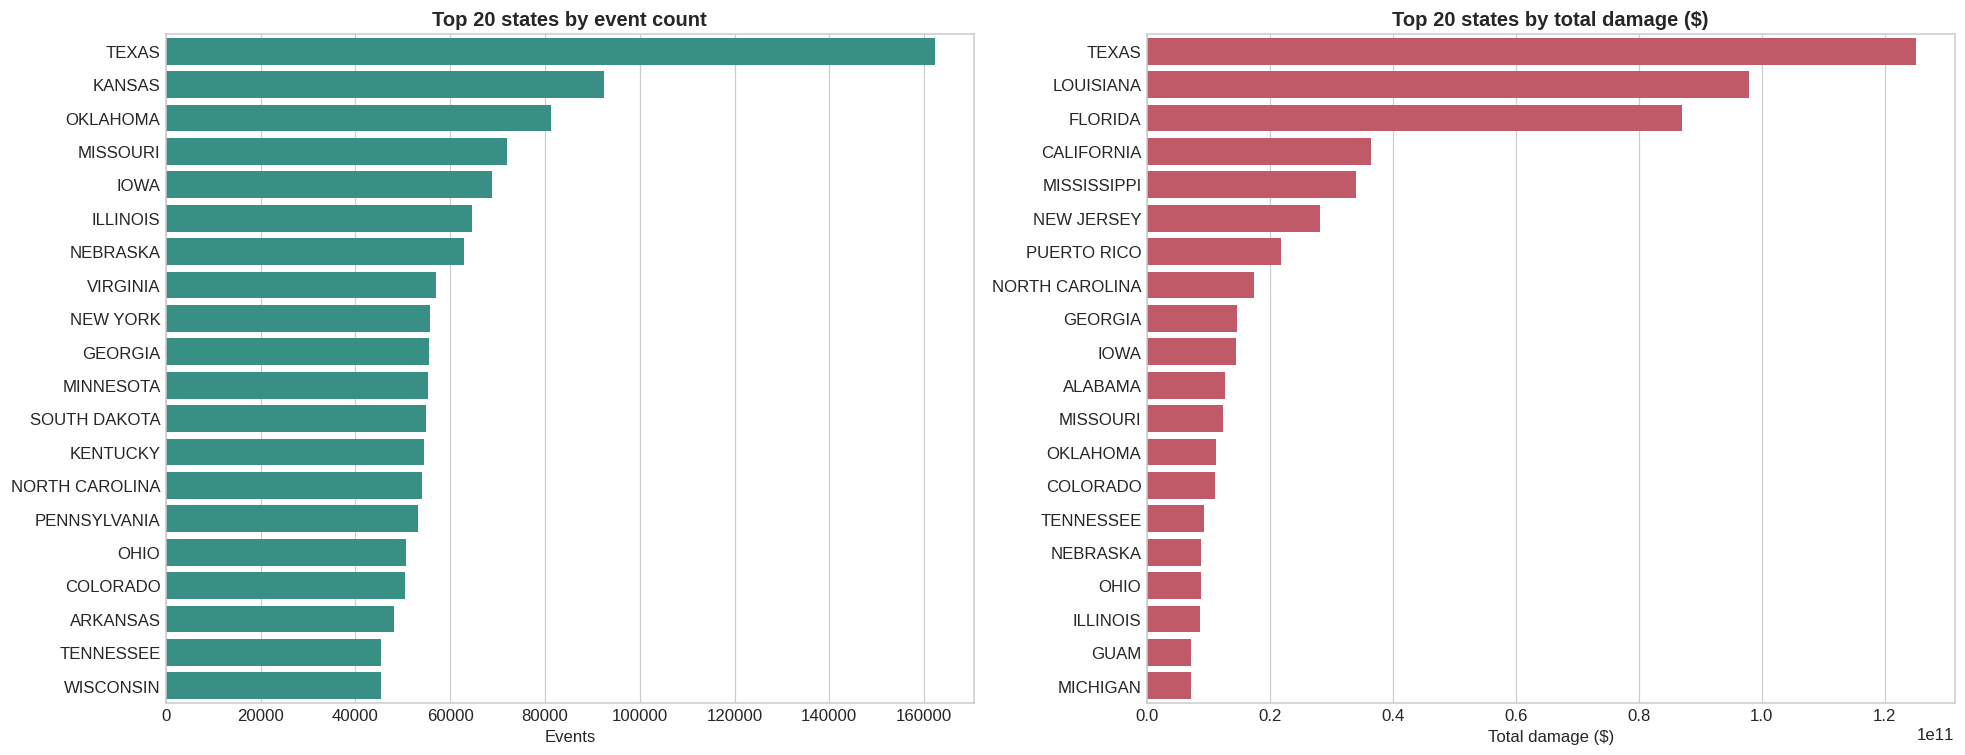

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

state_counts = df_1['STATE'].value_counts().head(20)
sns.barplot(x=state_counts.to_numpy(), y=list(state_counts.index), ax=axes[0], color='#2a9d8f')
axes[0].set_title('Top 20 states by event count'); axes[0].set_xlabel('Events')

# Total damage per state = DAMAGE_PROPERTY + DAMAGE_CROPS (DAMAGE_TARGETS)
damage_state = (df_1.groupby('STATE')[DAMAGE_TARGETS].sum().sum(axis=1)
                  .sort_values(ascending=False).head(20))
sns.barplot(x=damage_state.to_numpy(), y=list(damage_state.index), ax=axes[1], color='#d1495b')
axes[1].set_title('Top 20 states by total damage ($)'); axes[1].set_xlabel('Total damage ($)')
plt.tight_layout()
plt.show()

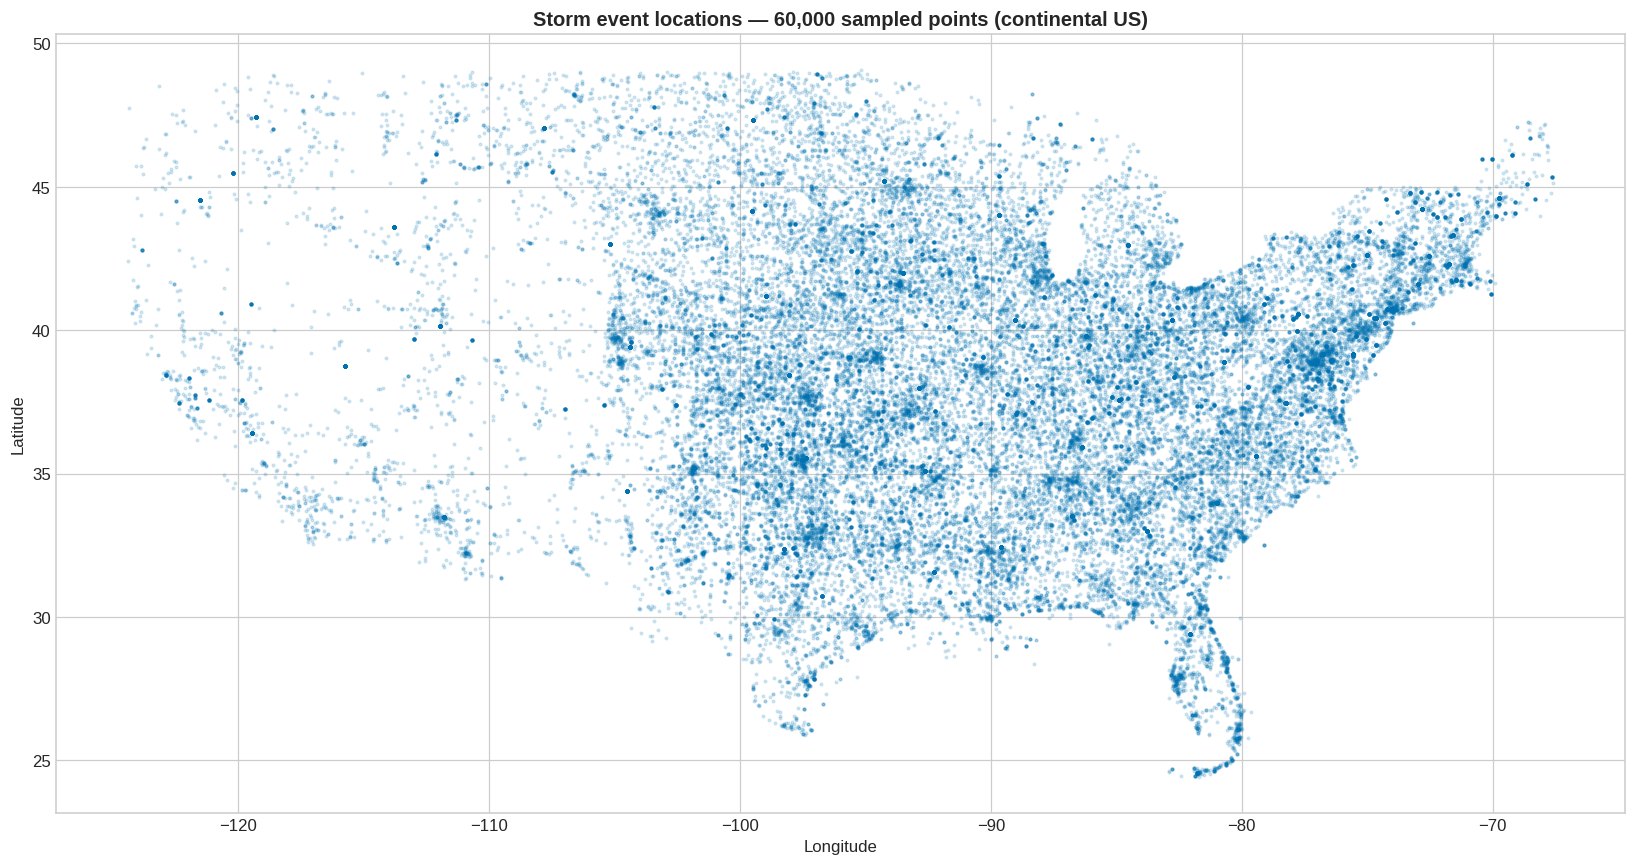

In [26]:
# Sampled geographic scatter (continental US bounds)
geo = df_1.dropna(subset=['BEGIN_LAT', 'BEGIN_LON'])
geo = geo[(geo['BEGIN_LAT'].between(24, 50)) & (geo['BEGIN_LON'].between(-125, -66))]
geo = geo.sample(n=min(60_000, len(geo)), random_state=42)

fig, ax = plt.subplots(figsize=(15, 8))
sc = ax.scatter(geo['BEGIN_LON'], geo['BEGIN_LAT'], s=3, alpha=0.15, c='#0072B2')
ax.set_title(f'Storm event locations — {len(geo):,} sampled points (continental US)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

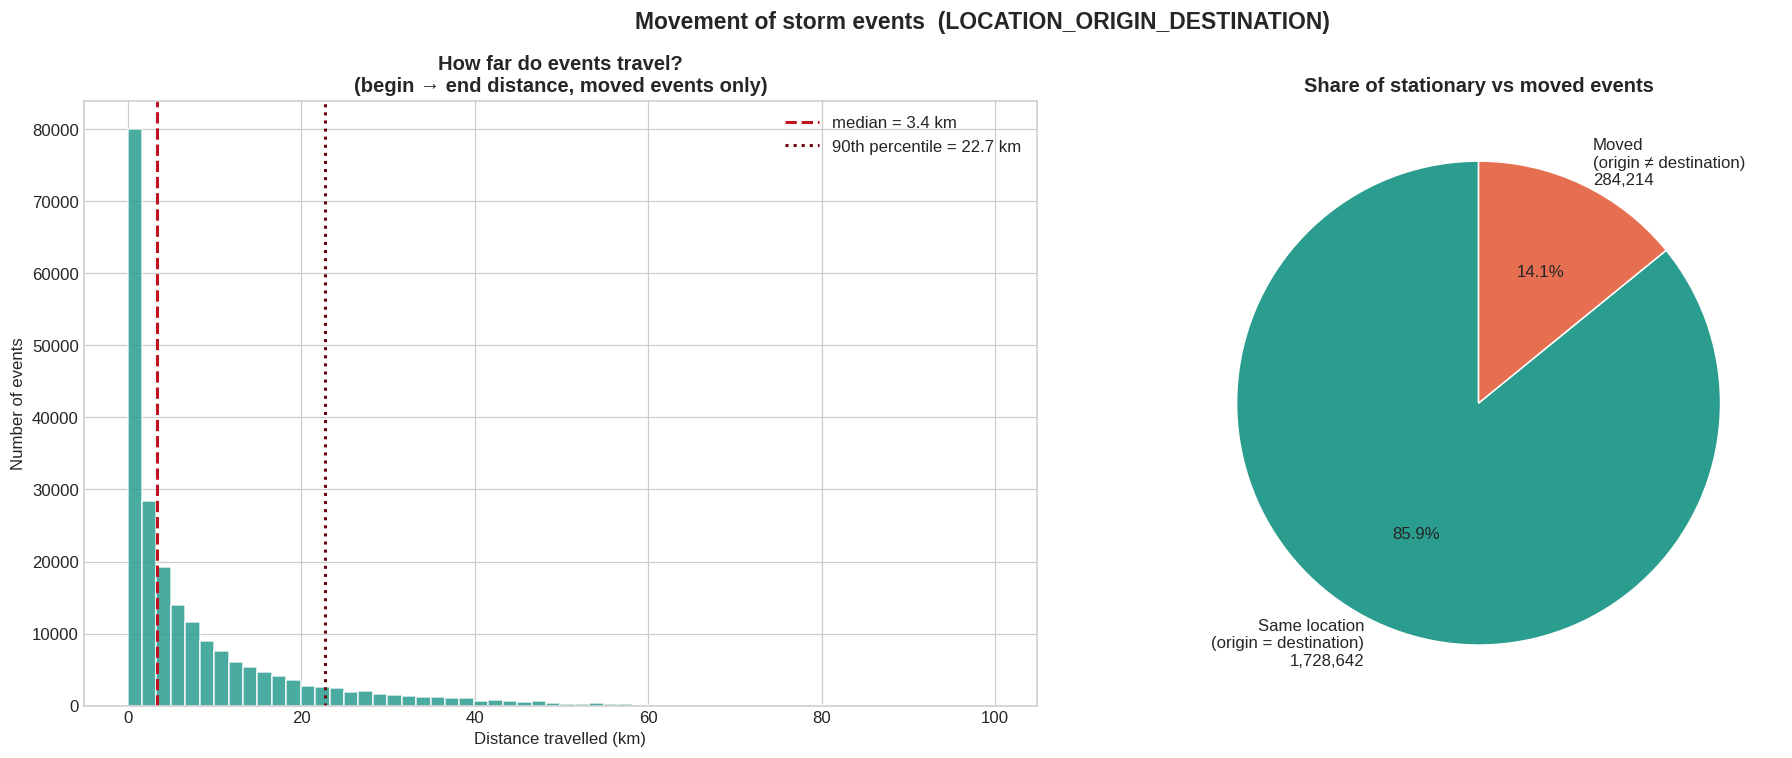

In [27]:
# -- LOCATION_ORIGIN_DESTINATION -- movement of storm events --------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: how far events travel (begin -> end distance), moved events only.
dist = df_1['DISTANCE'].to_numpy()
dist = dist[(~np.isnan(dist)) & (dist > 0) & (dist <= 100)]
med, p90 = np.median(dist), np.percentile(dist, 90)

axes[0].hist(dist, bins=60, color='#2a9d8f', edgecolor='white', alpha=0.85)
axes[0].axvline(med, color='#c1121f', ls='--', lw=2, label=f'median = {med:.1f} km')
axes[0].axvline(p90, color='#6a040f', ls=':',  lw=2, label=f'90th percentile = {p90:.1f} km')
axes[0].set_title('How far do events travel?\n(begin → end distance, moved events only)')
axes[0].set_xlabel('Distance travelled (km)')
axes[0].set_ylabel('Number of events')
axes[0].legend()

# Right: share of stationary vs moved events
loc = df_1[['BEGIN_LOCATION', 'END_LOCATION']].dropna()
same  = int((loc['BEGIN_LOCATION'] == loc['END_LOCATION']).sum())
moved = int(len(loc) - same)
axes[1].pie([same, moved],
            labels=[f'Same location\n(origin = destination)\n{same:,}',
                    f'Moved\n(origin ≠ destination)\n{moved:,}'],
            autopct='%1.1f%%', startangle=90,
            colors=['#2a9d8f', '#e76f51'], wedgeprops={'edgecolor': 'white'},
            textprops={'fontsize': 11})
axes[1].set_title('Share of stationary vs moved events')

fig.suptitle('Movement of storm events  (LOCATION_ORIGIN_DESTINATION)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

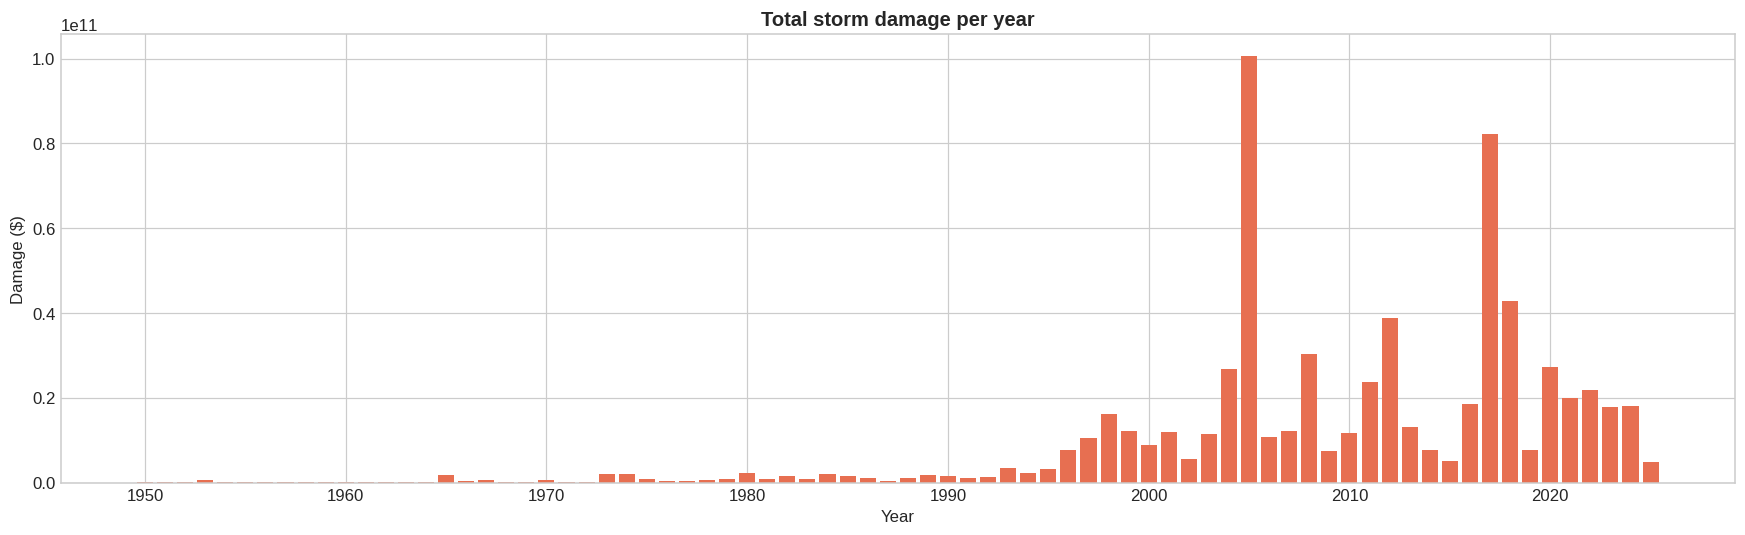

In [28]:
# Total storm damage per year = DAMAGE_PROPERTY + DAMAGE_CROPS
damage_year = df_1.groupby('YEAR')[DAMAGE_TARGETS].sum().sum(axis=1)

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(damage_year.index.to_numpy(), damage_year.to_numpy(), color='#e76f51')
ax.set_title('Total storm damage per year')
ax.set_ylabel('Damage ($)'); ax.set_xlabel('Year')
plt.tight_layout()
plt.show()

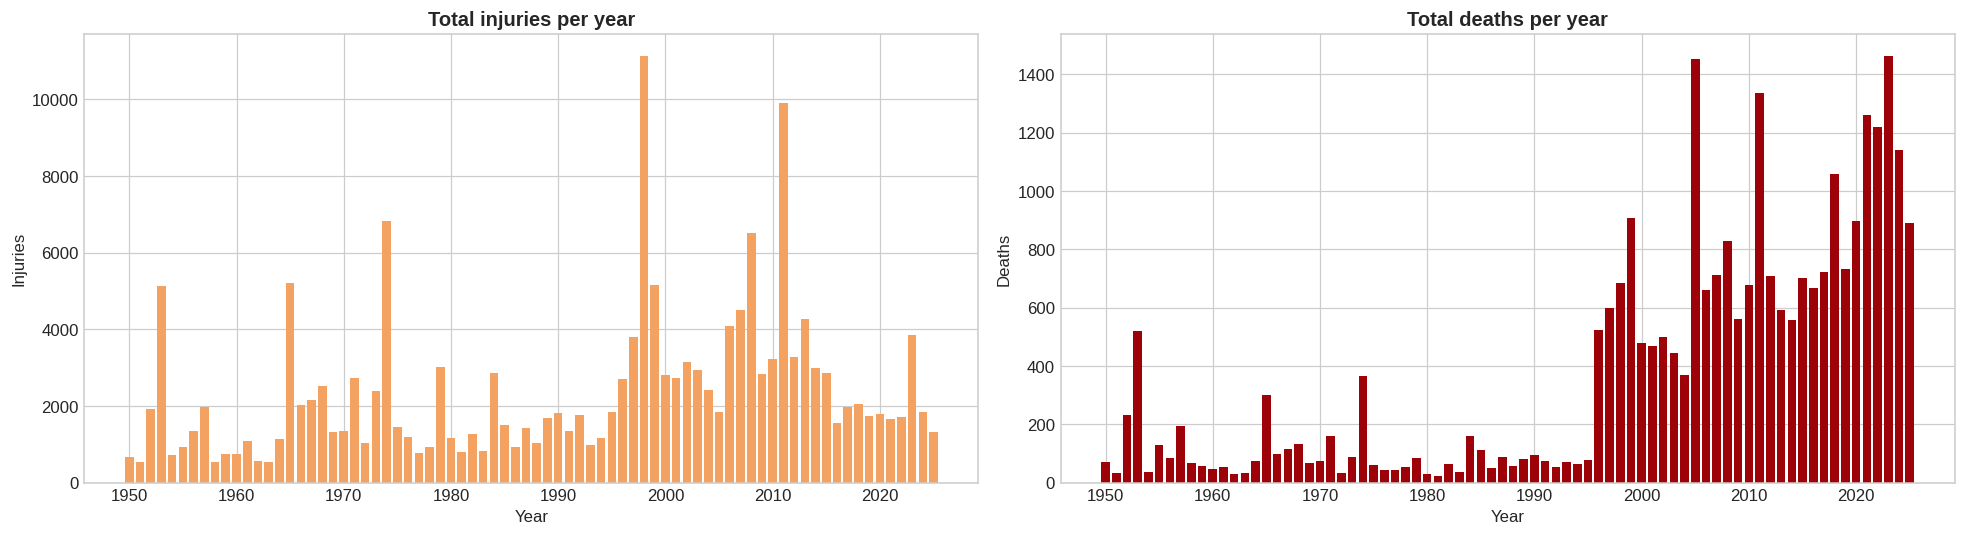

In [29]:
# Total injuries and deaths per year (direct + indirect)
human_impact_year = df_1.groupby('YEAR')[INJURY_TARGETS + DEATH_TARGETS].sum()
injuries = human_impact_year[INJURY_TARGETS].sum(axis=1)
deaths   = human_impact_year[DEATH_TARGETS].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
axes[0].bar(injuries.index.to_numpy(), injuries.to_numpy(), color='#f4a261')
axes[0].set_title('Total injuries per year'); axes[0].set_ylabel('Injuries'); axes[0].set_xlabel('Year')
axes[1].bar(deaths.index.to_numpy(), deaths.to_numpy(), color='#9d0208')
axes[1].set_title('Total deaths per year'); axes[1].set_ylabel('Deaths'); axes[1].set_xlabel('Year')
plt.tight_layout()
plt.show()

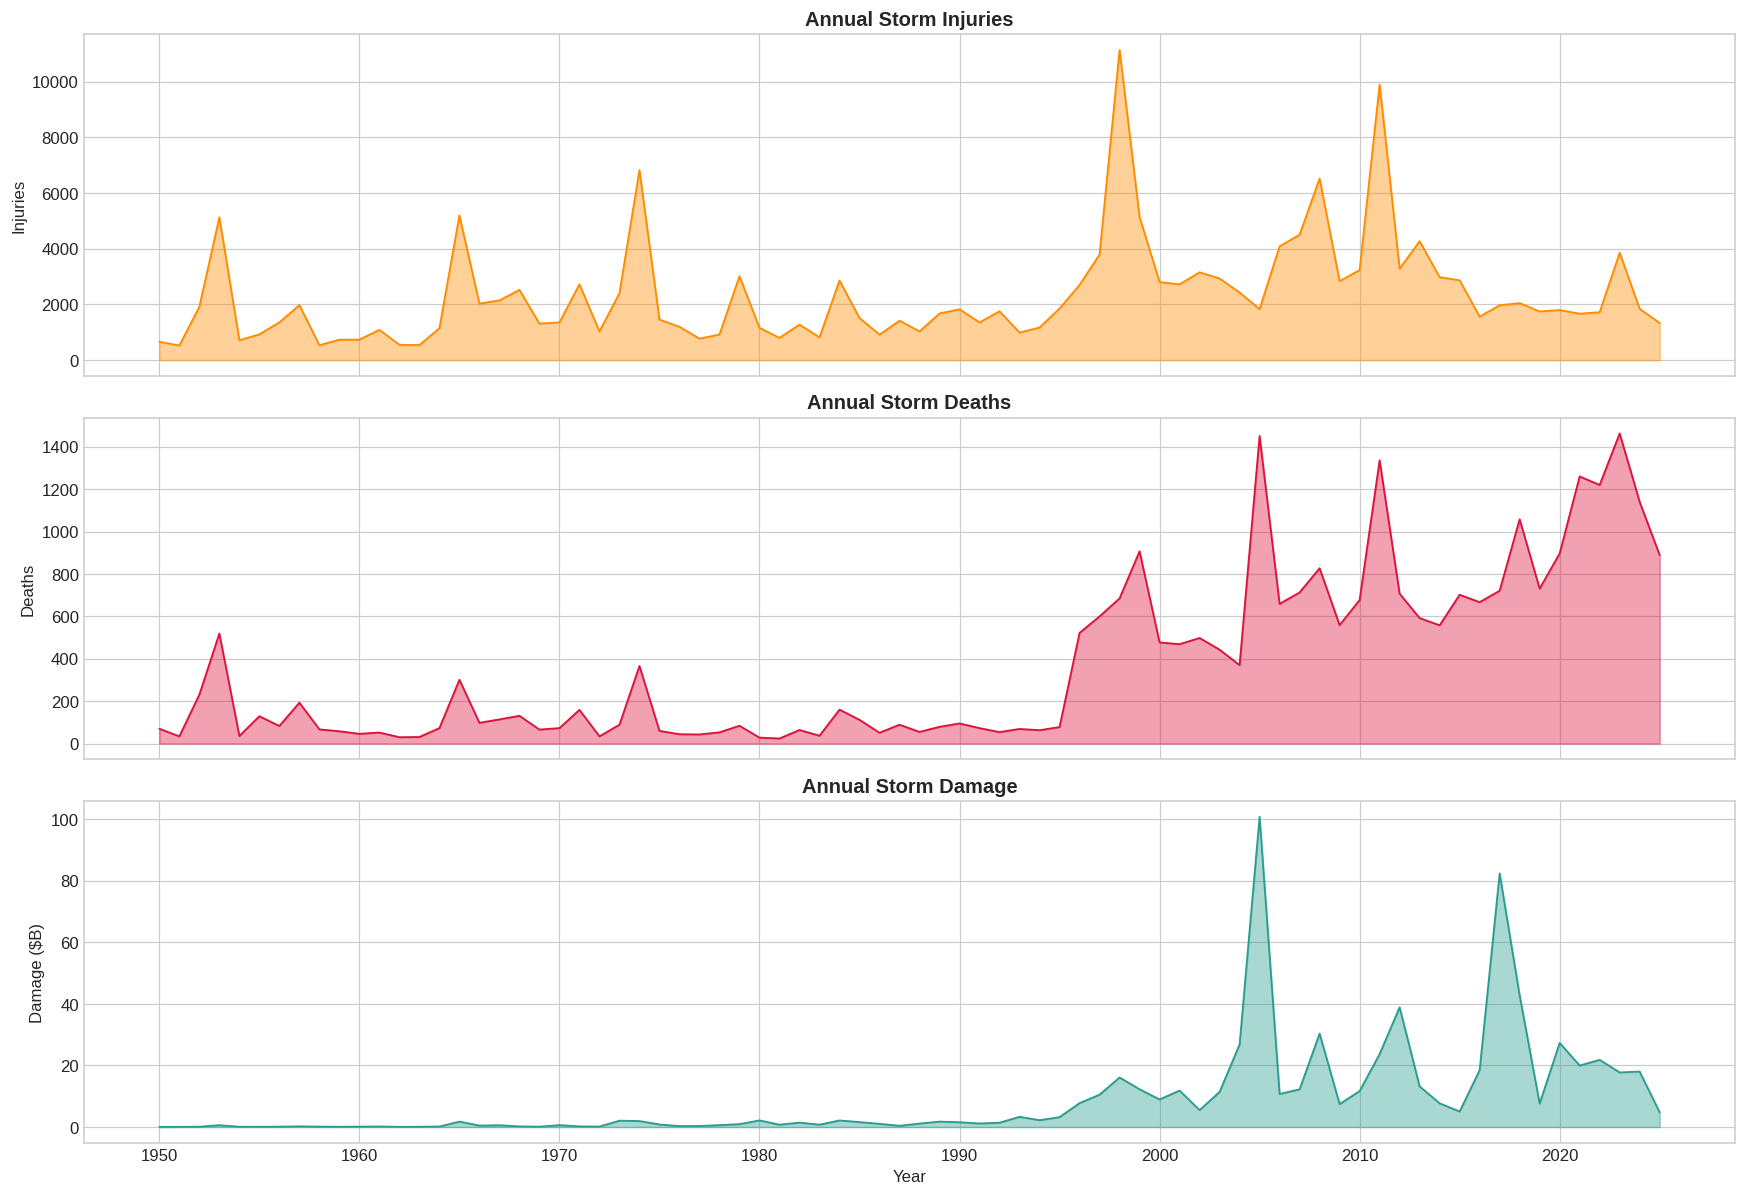

In [30]:
# ── Injuries, Deaths & Damage per Year ───────────────────────
impact_year = df_1.groupby('YEAR')[INJURY_TARGETS + DEATH_TARGETS + DAMAGE_TARGETS].sum()

years = list(range(int(impact_year.index.min()), int(impact_year.index.max()) + 1))
injuries = impact_year[INJURY_TARGETS].sum(axis=1).reindex(years)
deaths   = impact_year[DEATH_TARGETS].sum(axis=1).reindex(years)
damage   = impact_year[DAMAGE_TARGETS].sum(axis=1).reindex(years) / 1e9   # $ billions
x = np.asarray(years)

fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)

axes[0].fill_between(x, injuries.to_numpy(), alpha=0.4, color='darkorange')
axes[0].plot(x, injuries.to_numpy(), color='darkorange', linewidth=1.2)
axes[0].set_ylabel('Injuries')
axes[0].set_title('Annual Storm Injuries')

axes[1].fill_between(x, deaths.to_numpy(), alpha=0.4, color='crimson')
axes[1].plot(x, deaths.to_numpy(), color='crimson', linewidth=1.2)
axes[1].set_ylabel('Deaths')
axes[1].set_title('Annual Storm Deaths')

axes[2].fill_between(x, damage.to_numpy(), alpha=0.4, color='#2a9d8f')
axes[2].plot(x, damage.to_numpy(), color='#2a9d8f', linewidth=1.2)
axes[2].set_ylabel('Damage ($B)')
axes[2].set_xlabel('Year')
axes[2].set_title('Annual Storm Damage')

for ax in axes:
    ax.xaxis

plt.tight_layout()
plt.show()

## Categorical Drivers on Impacts

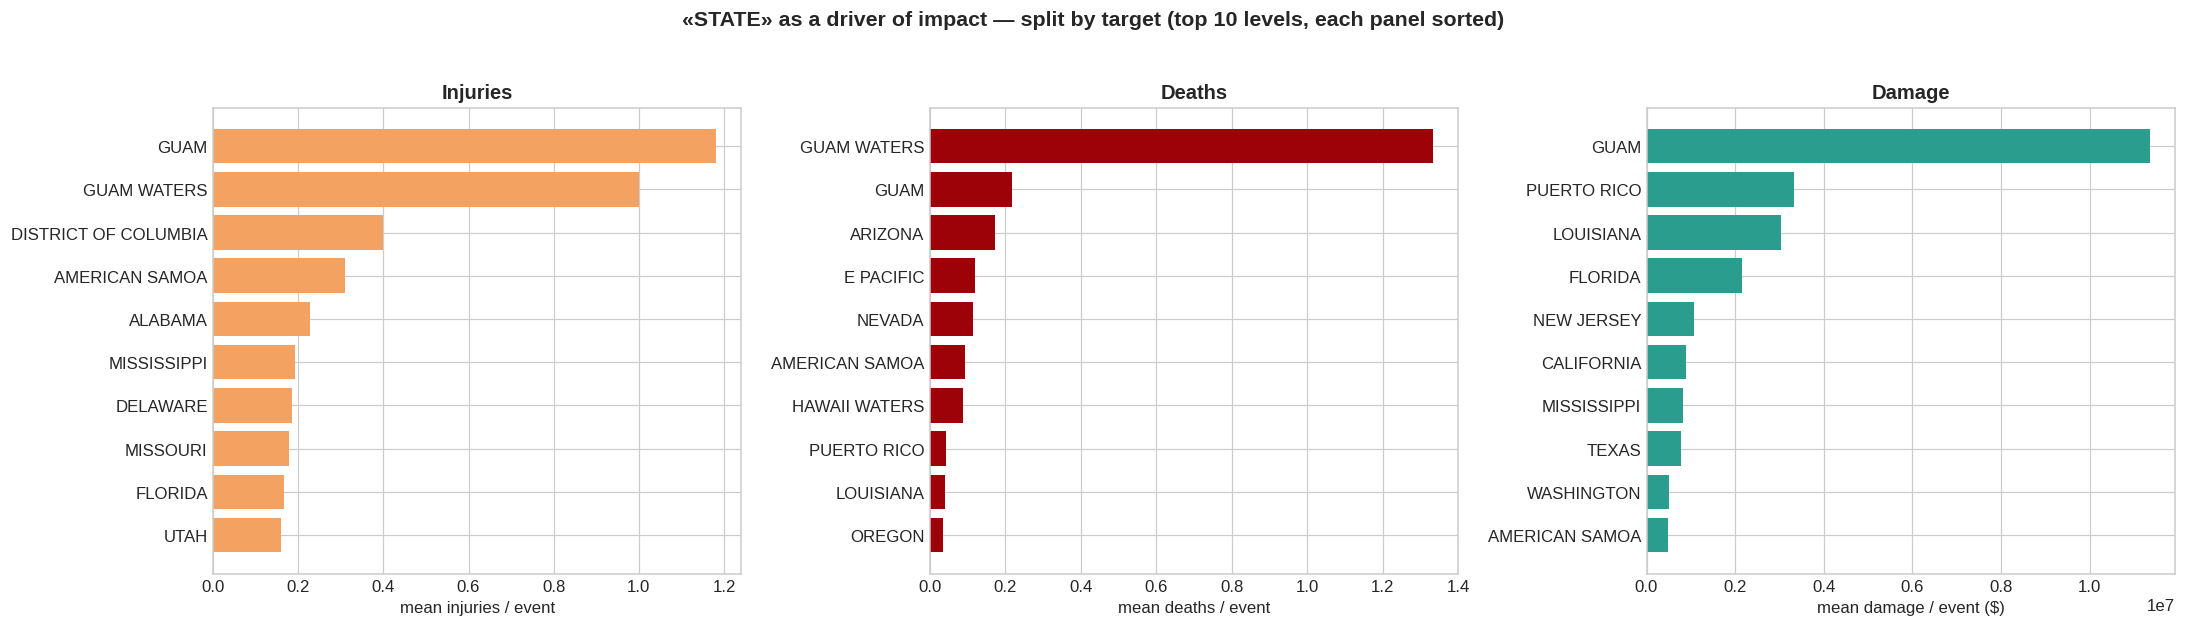

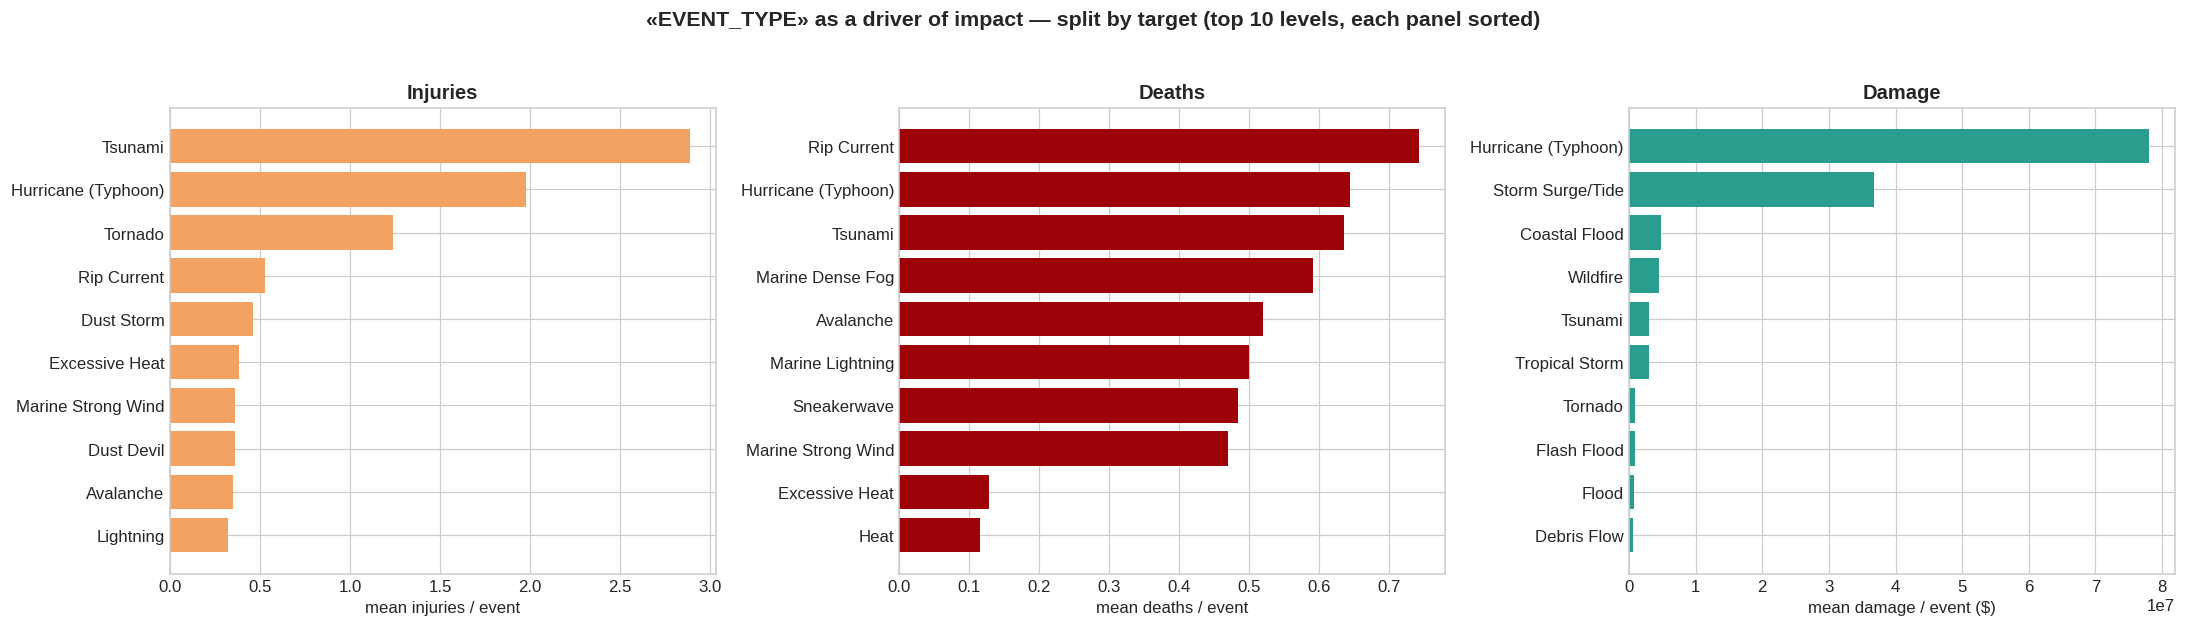

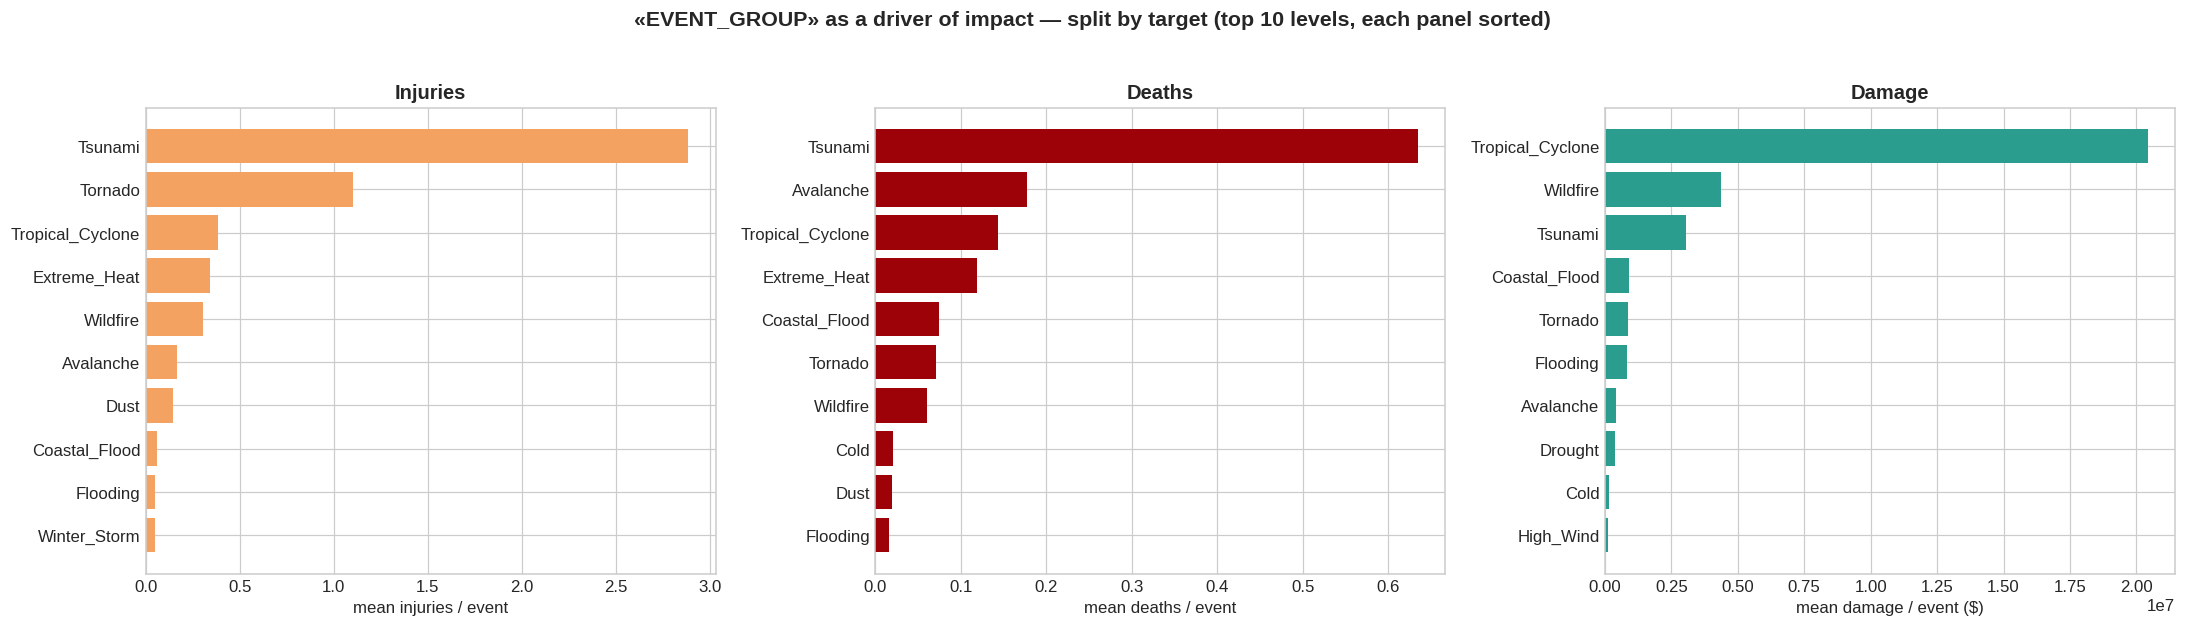

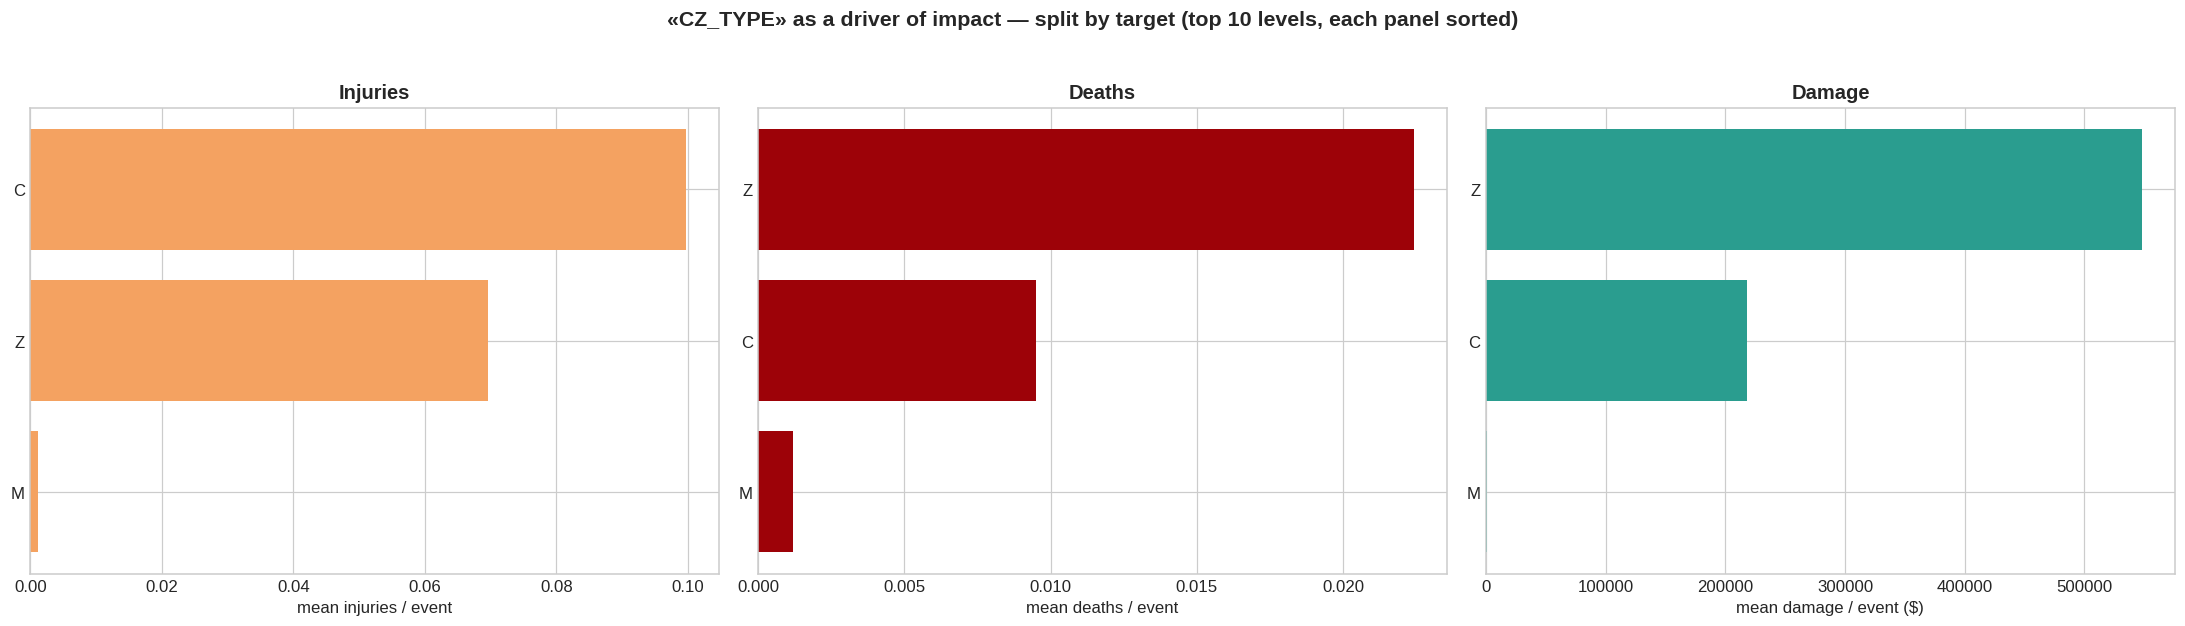

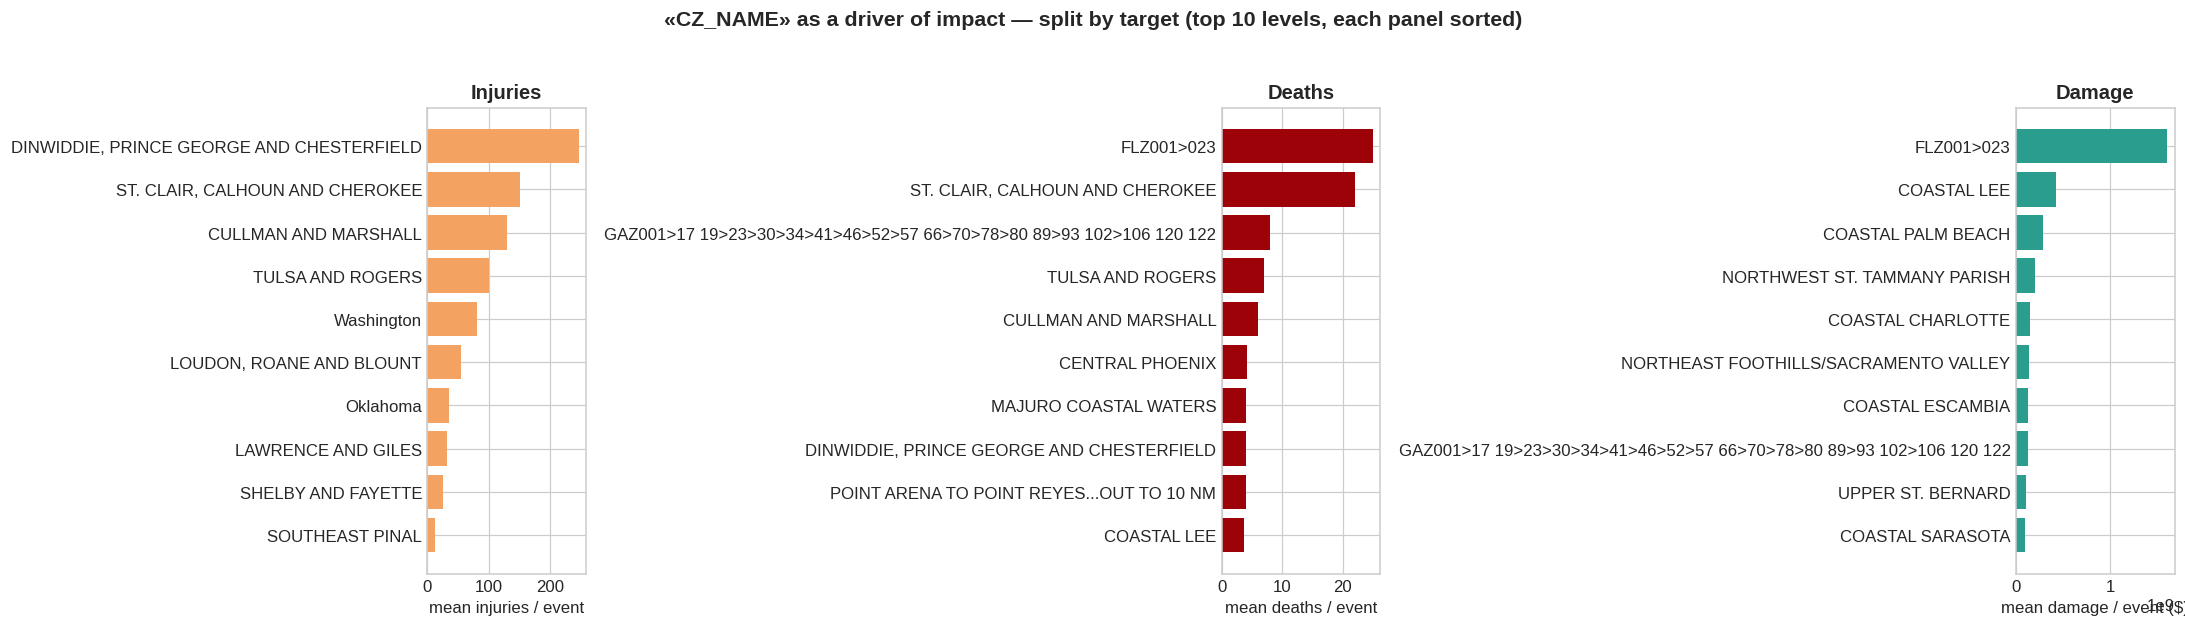

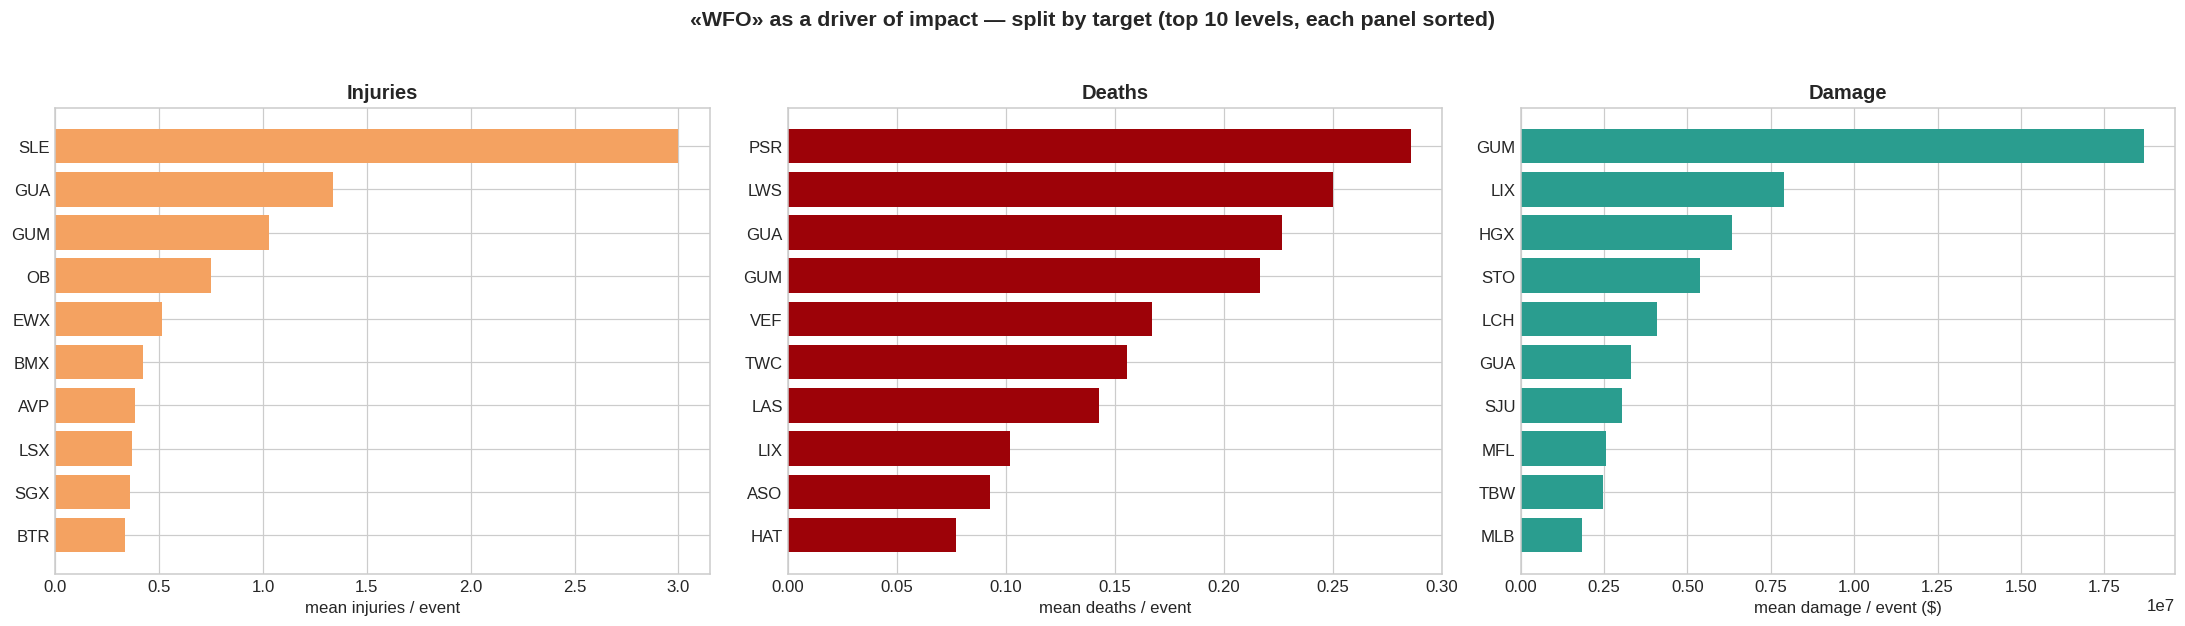

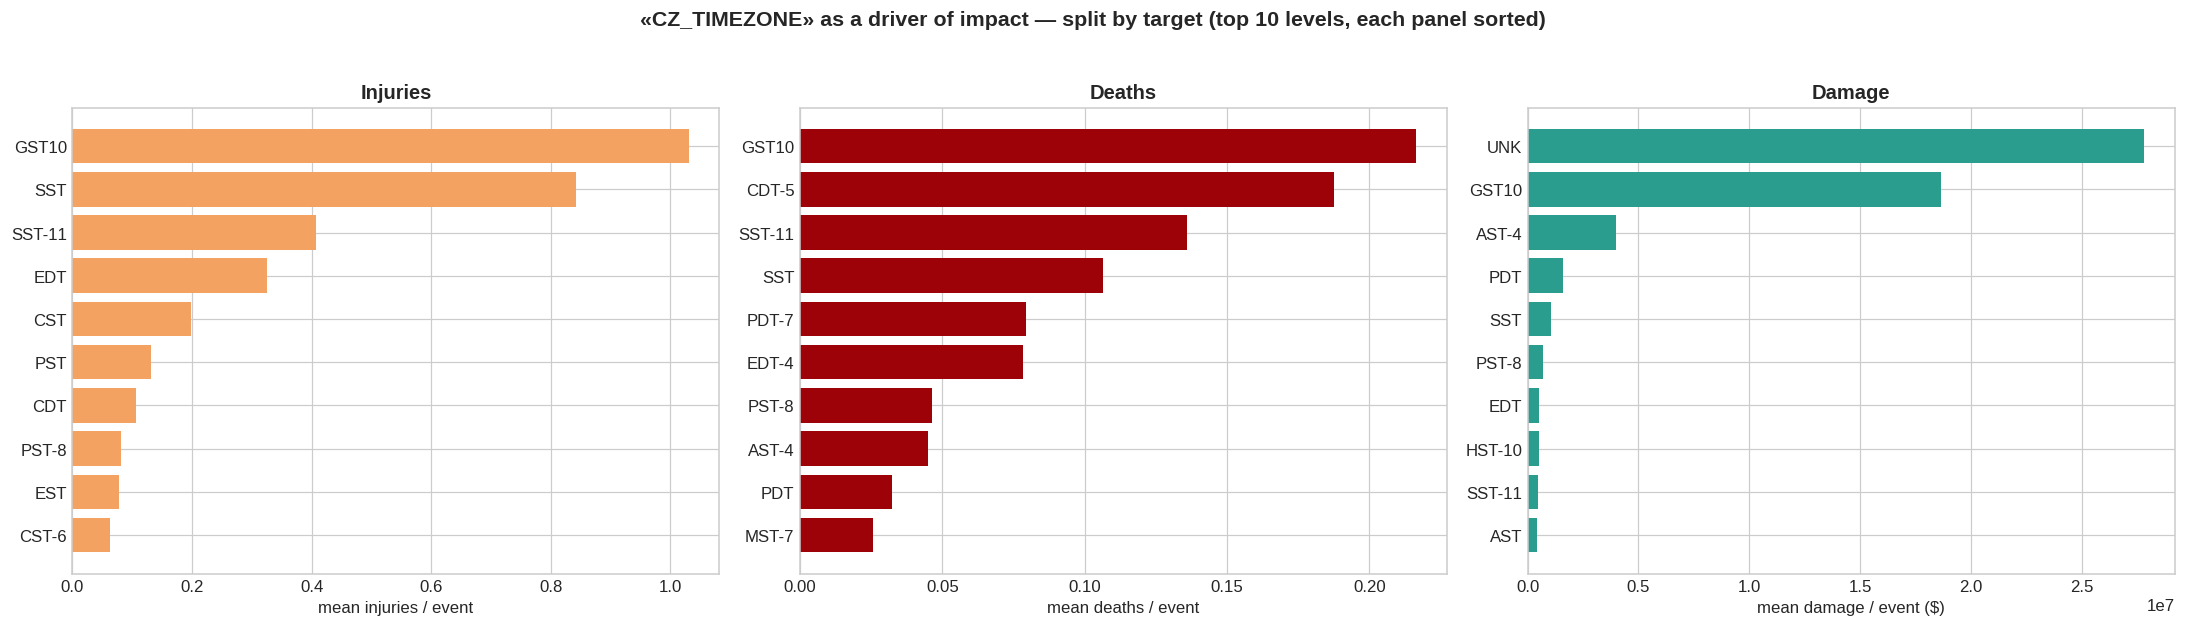

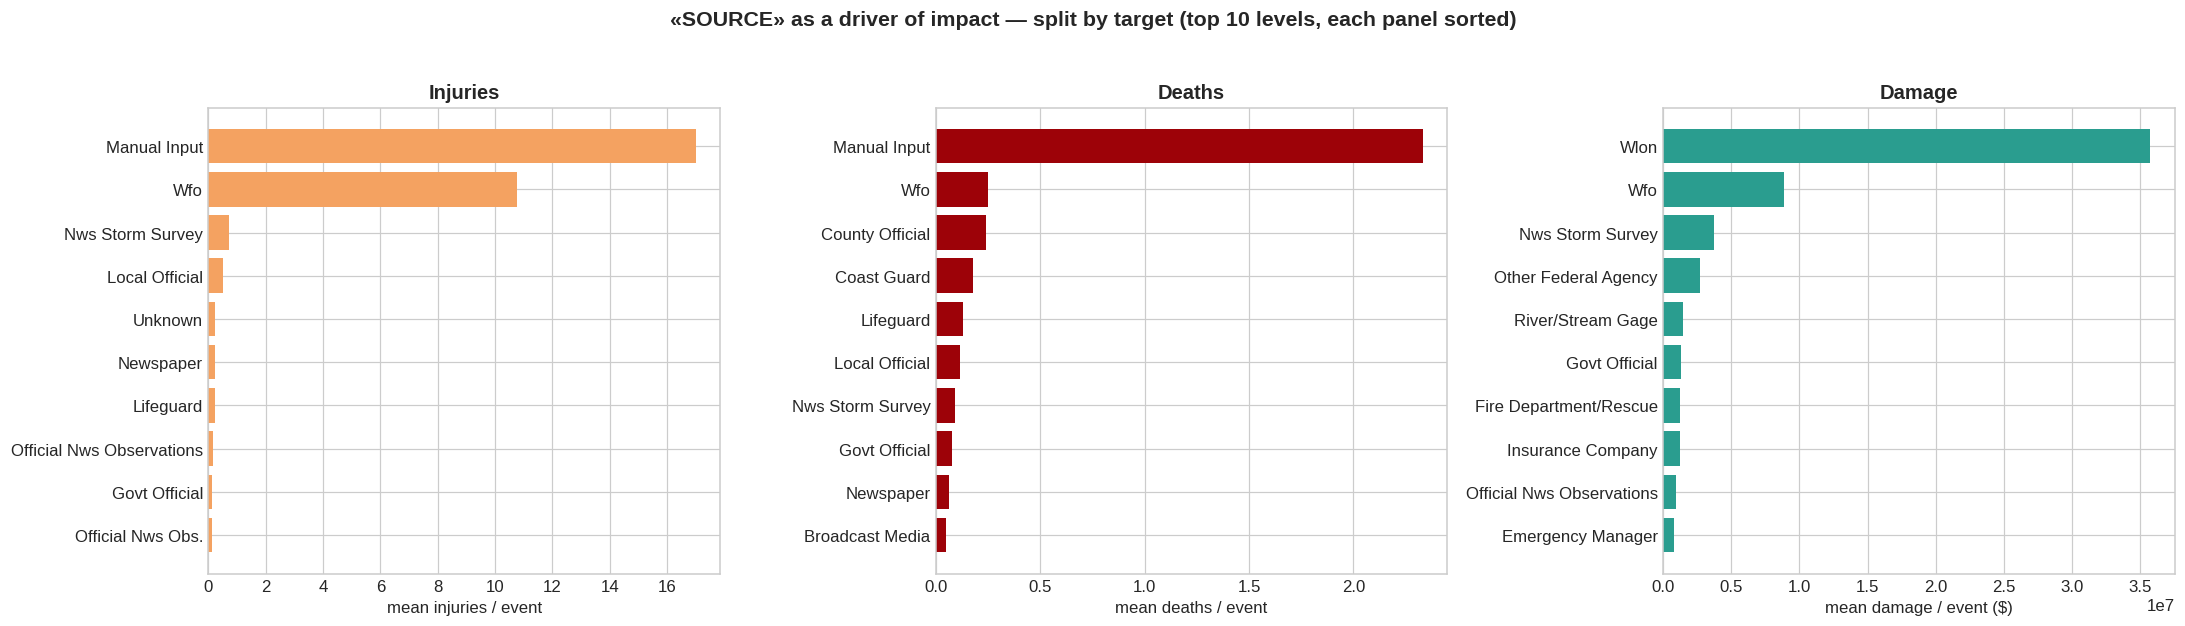

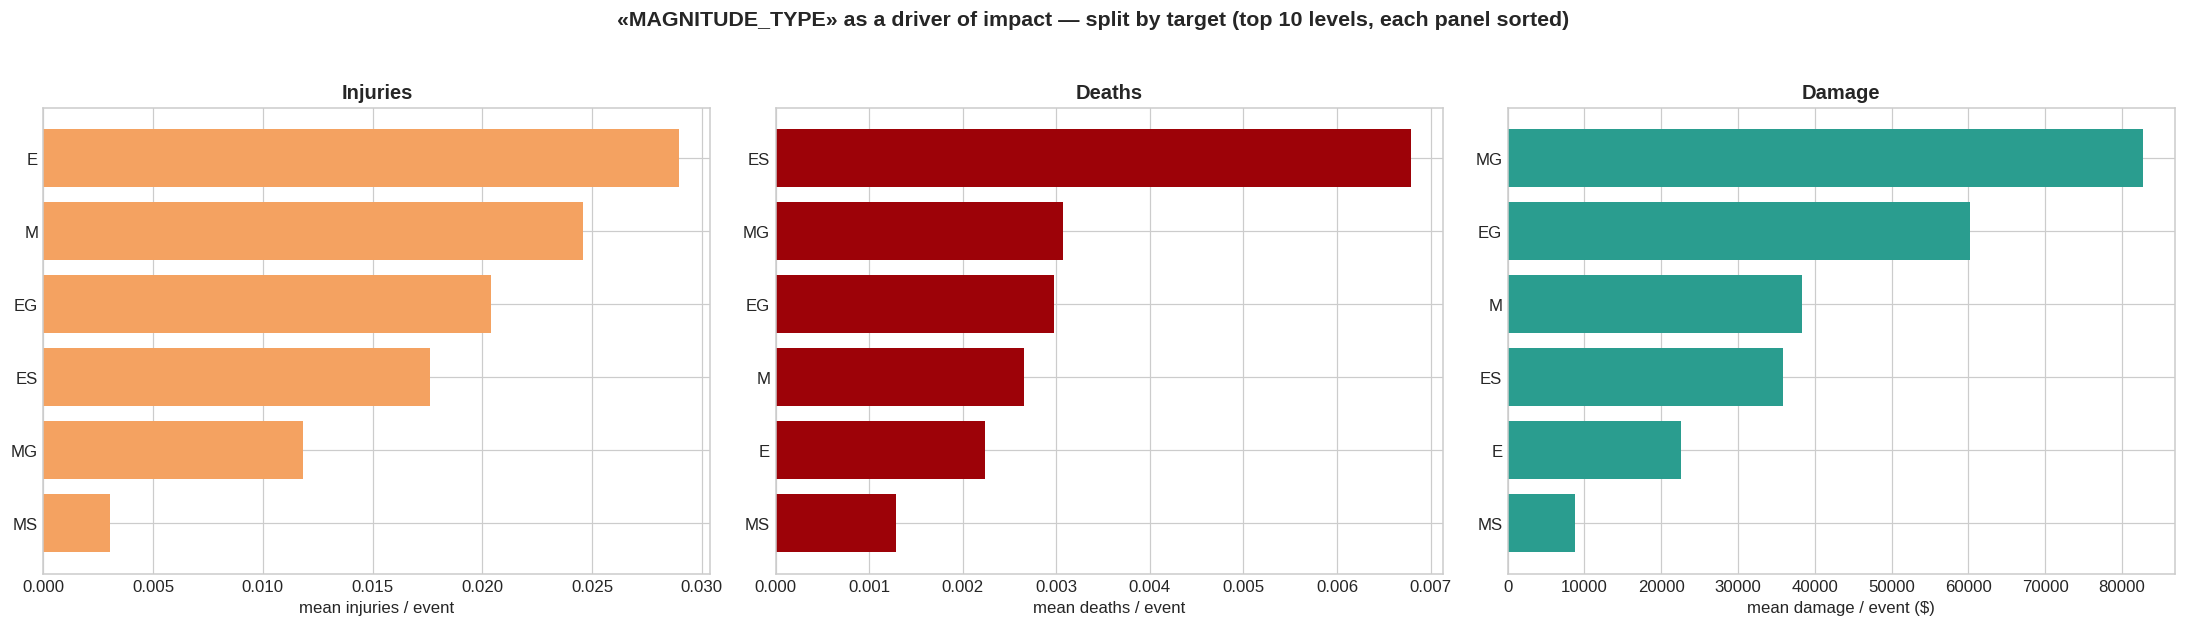

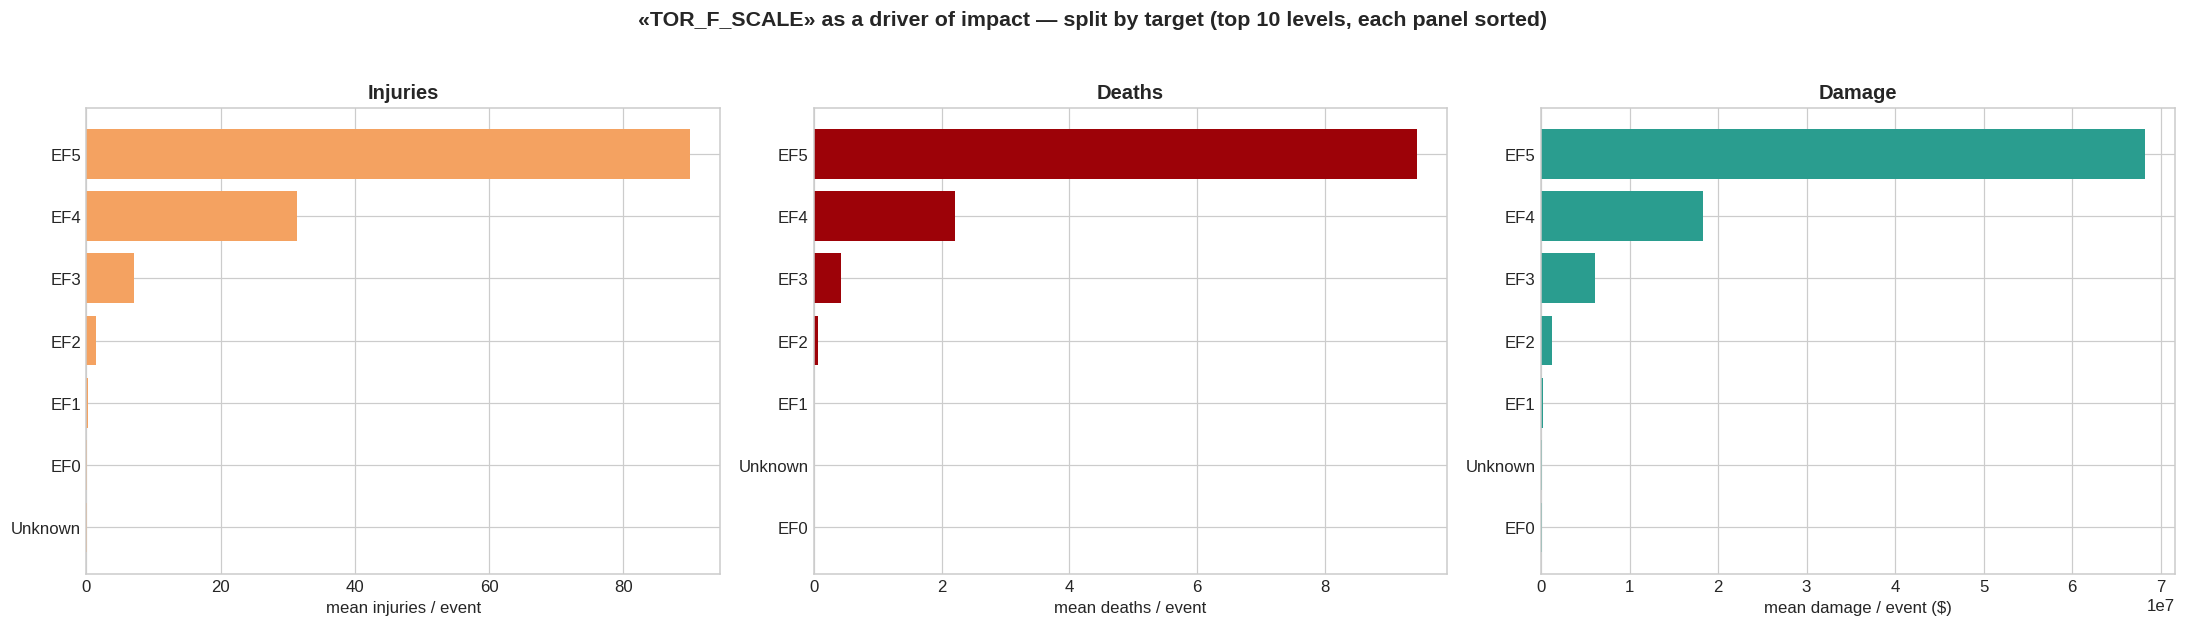

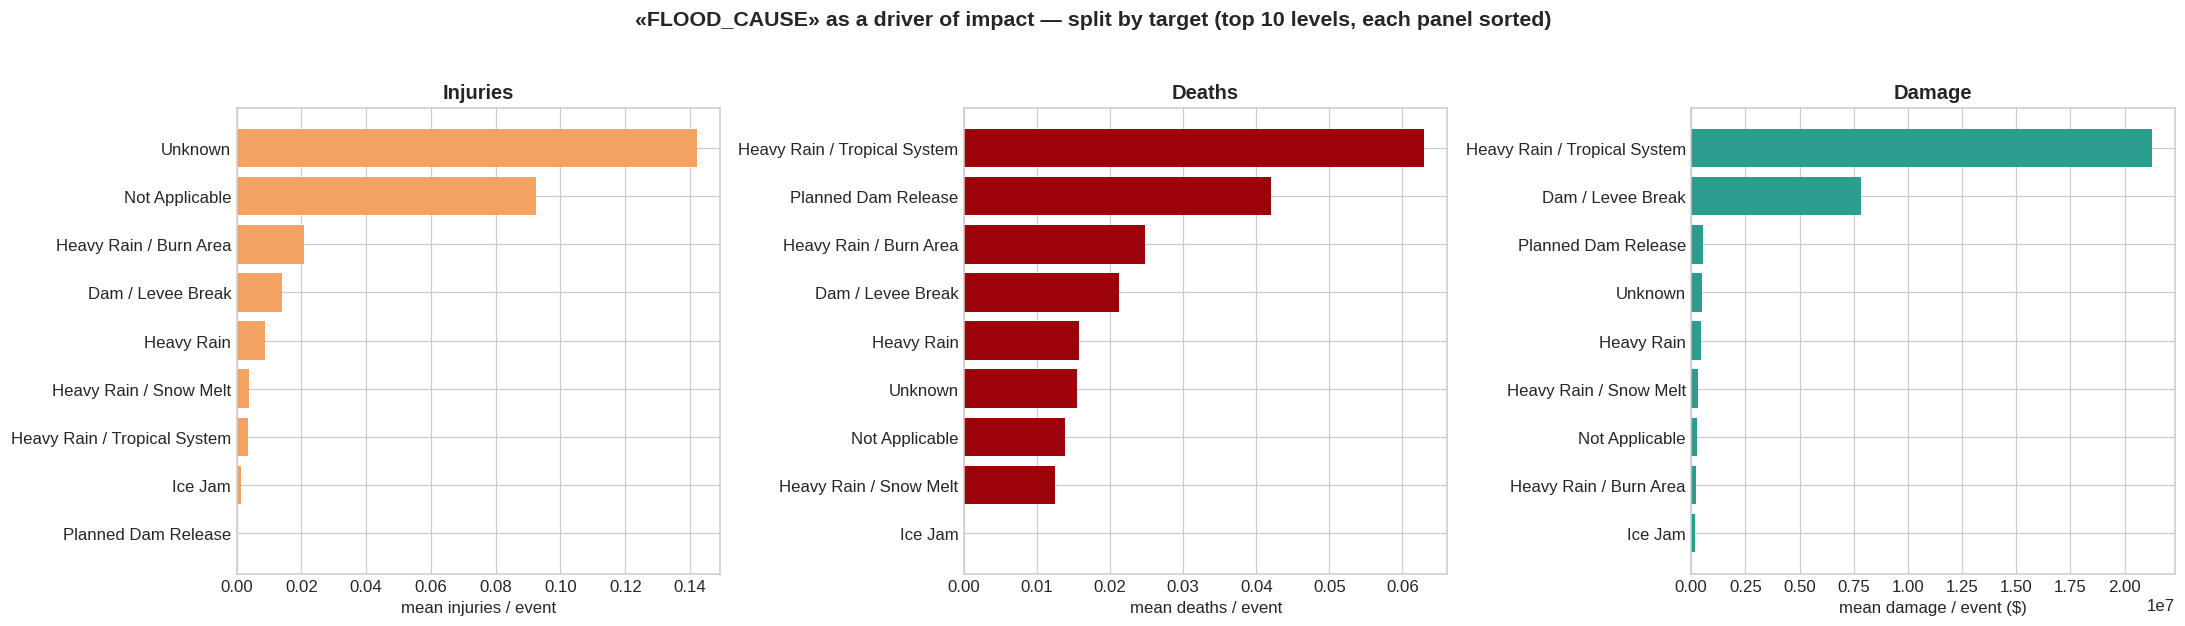

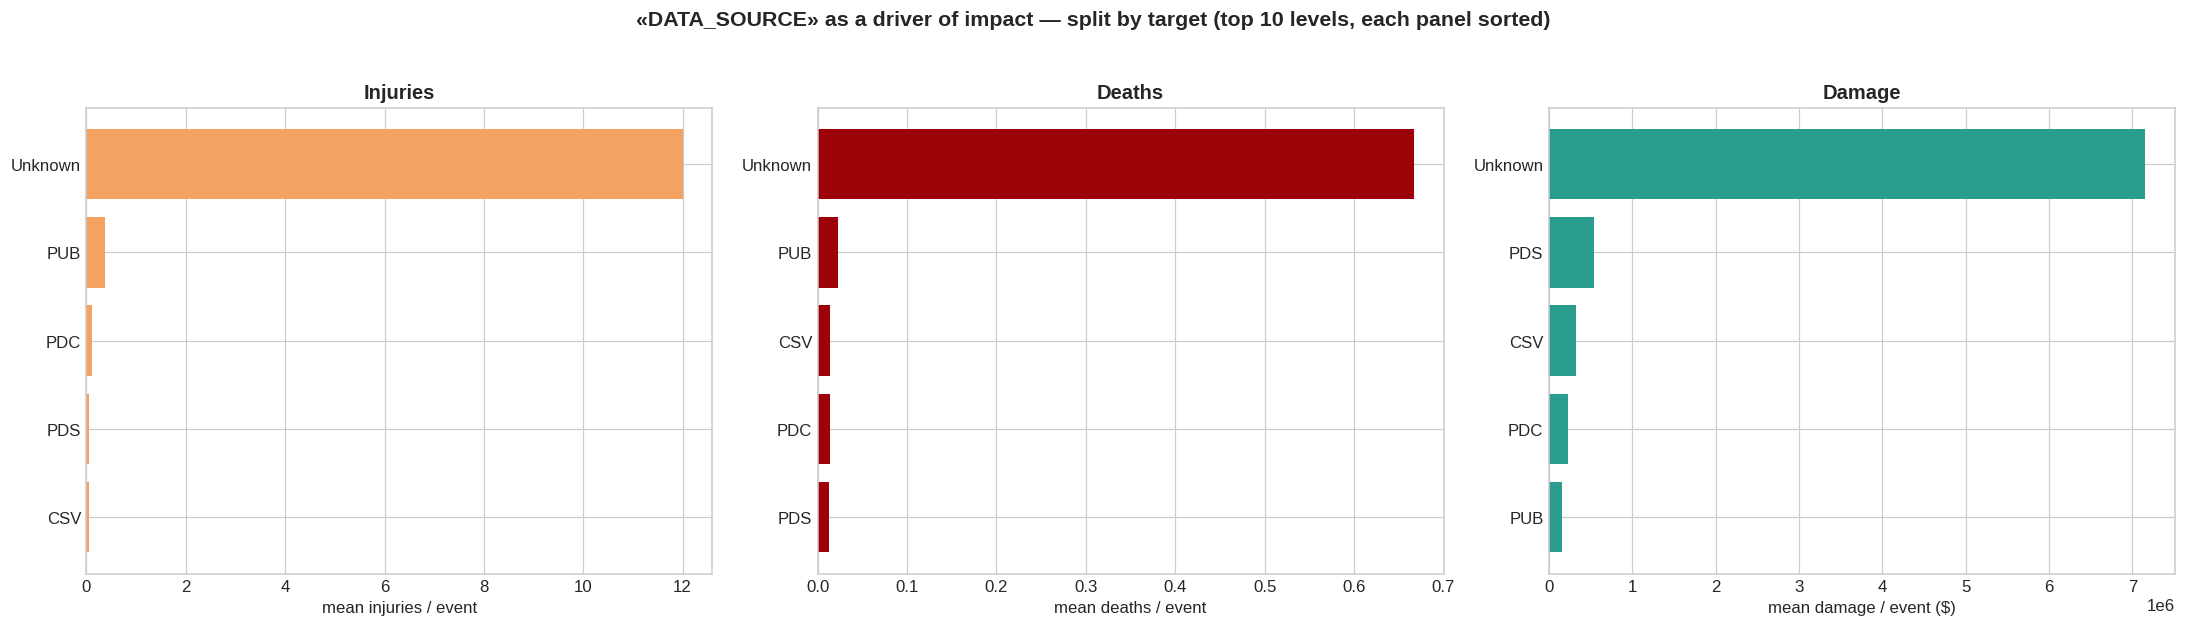

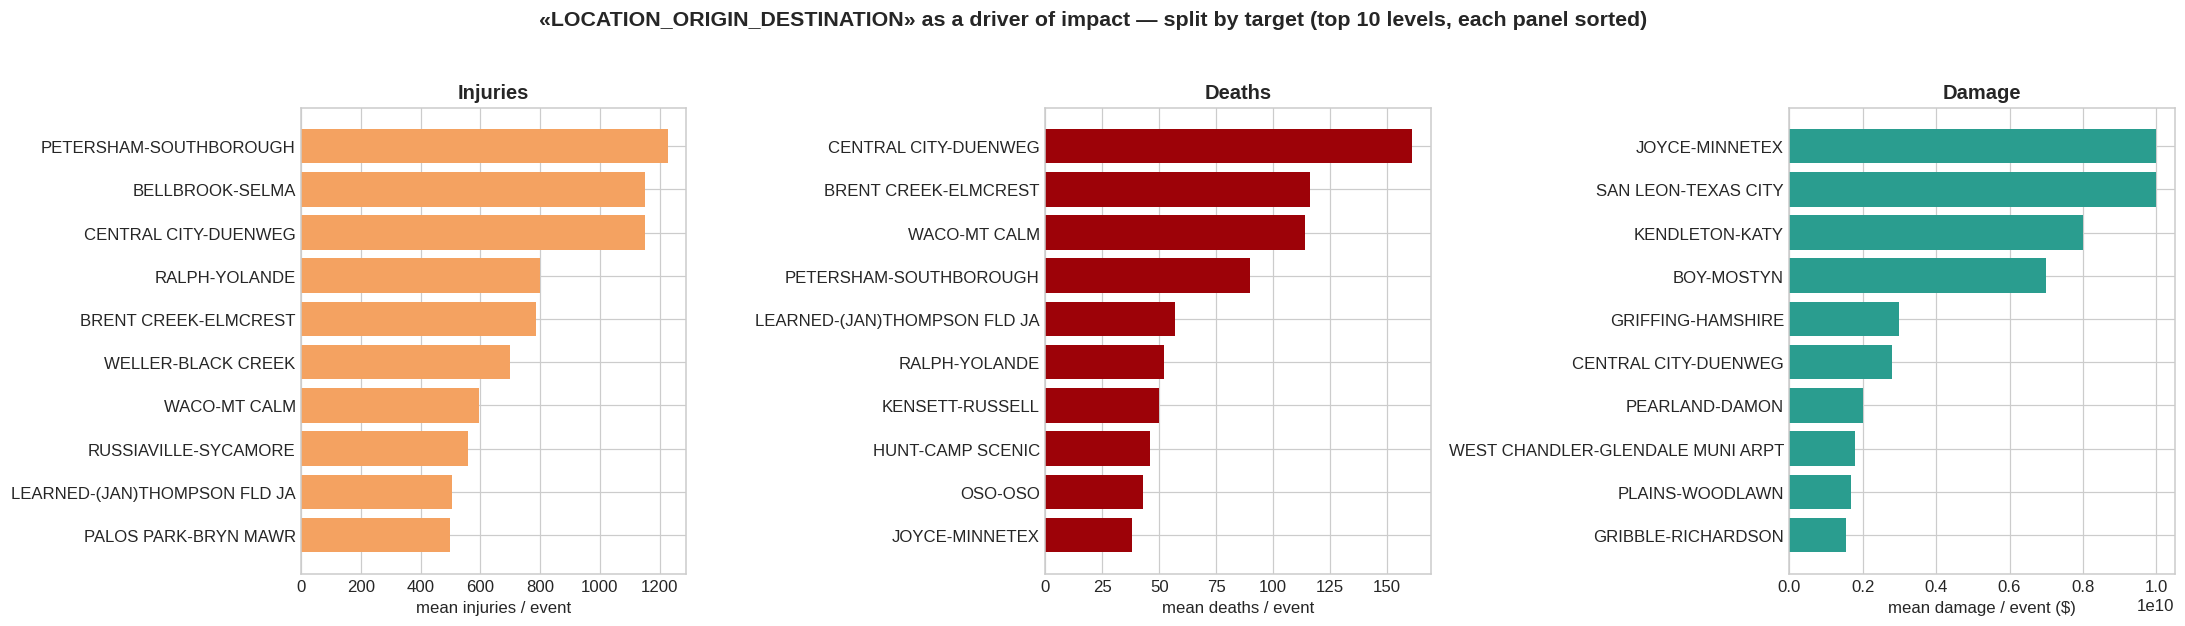

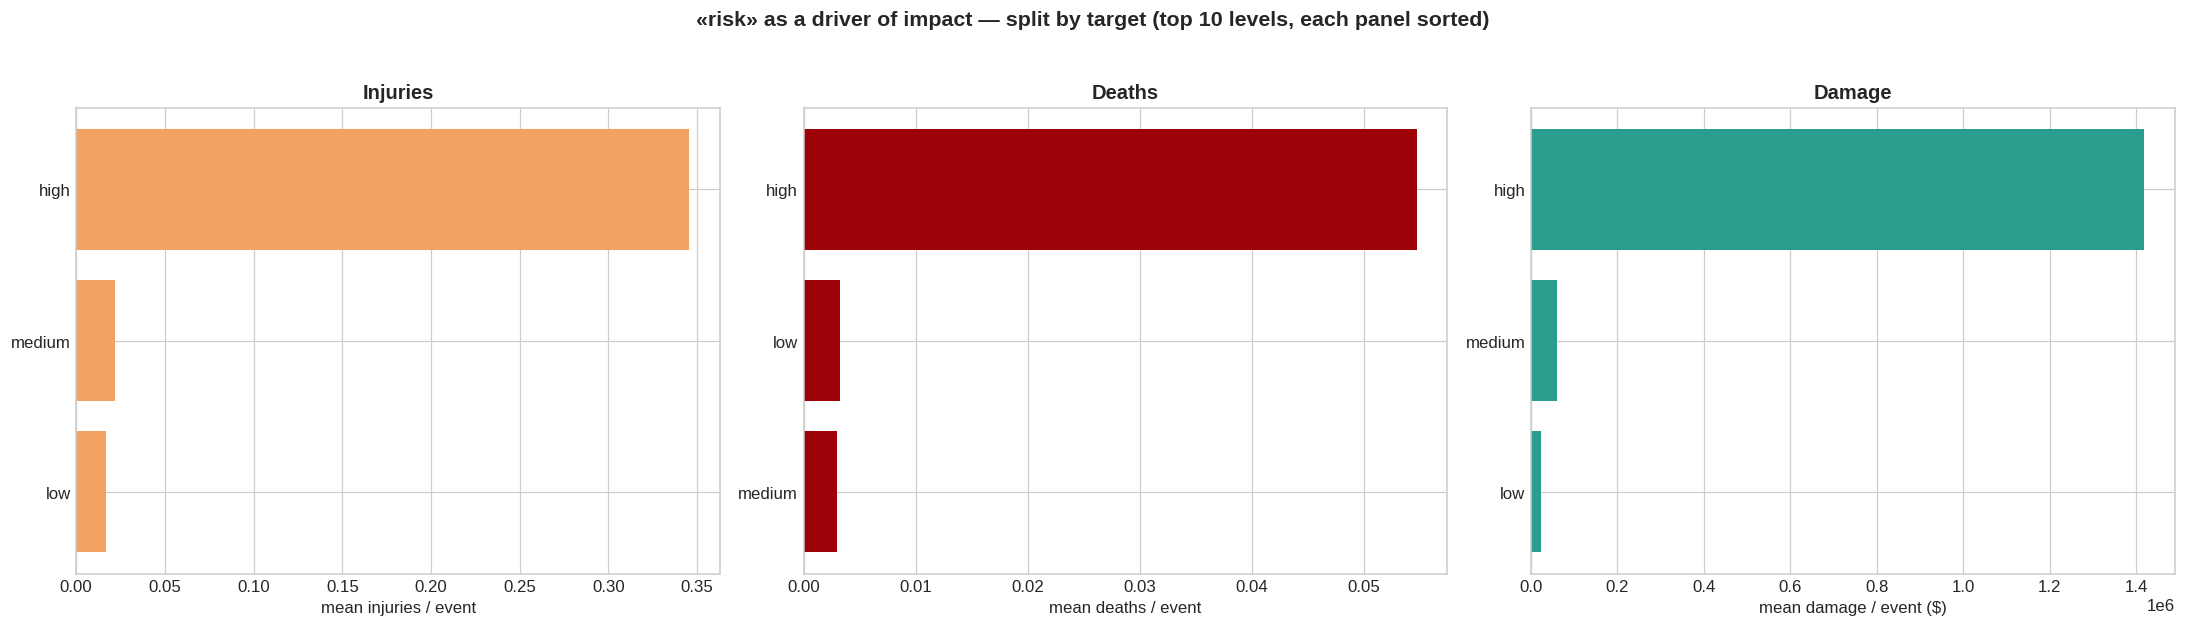

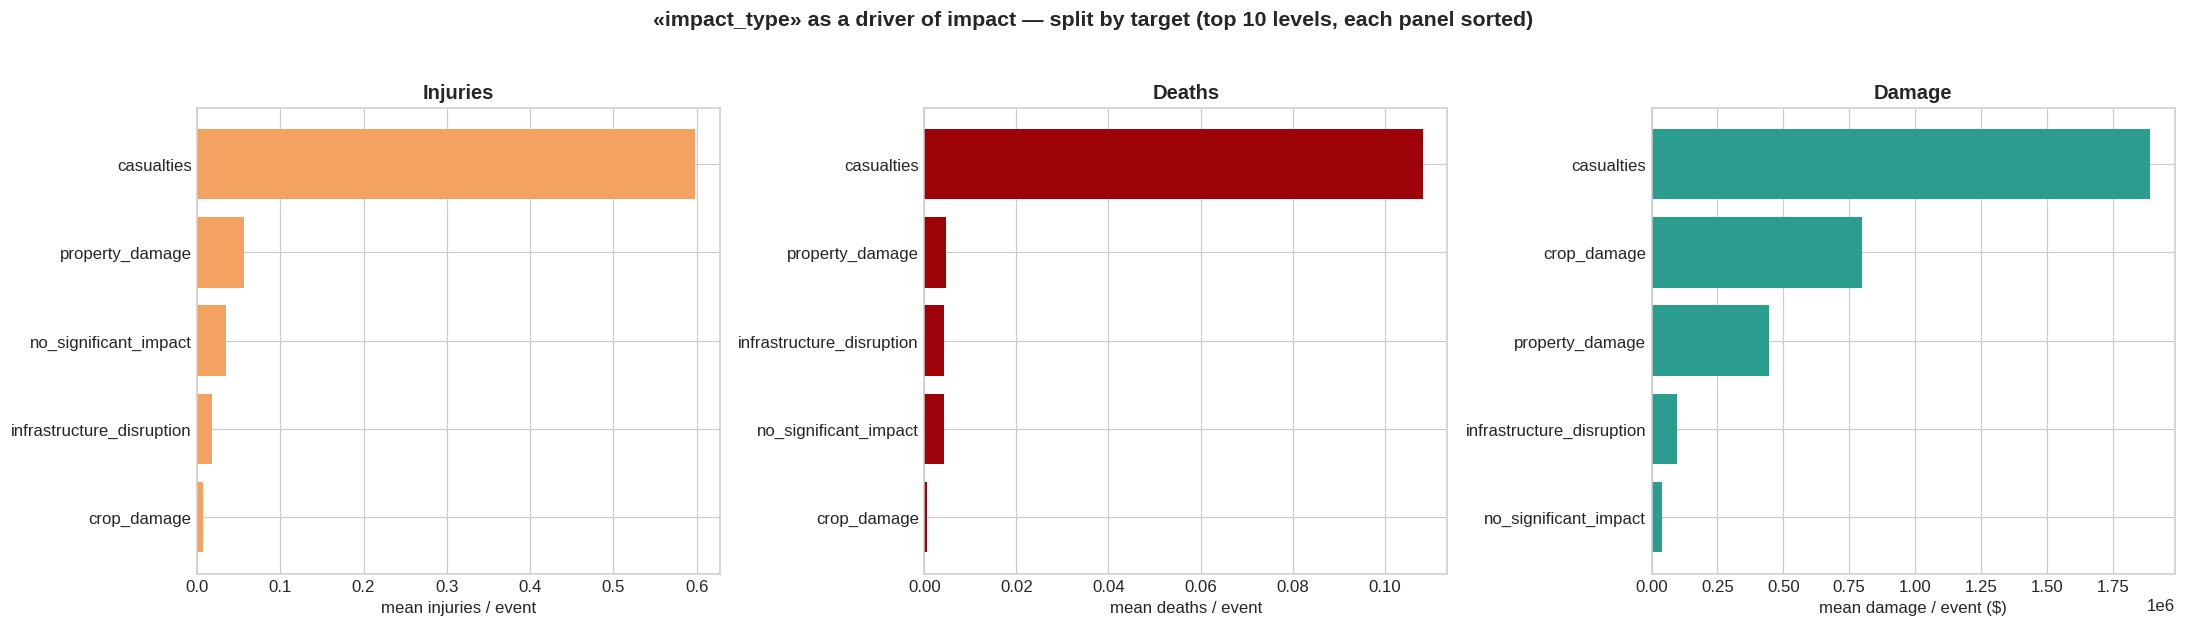

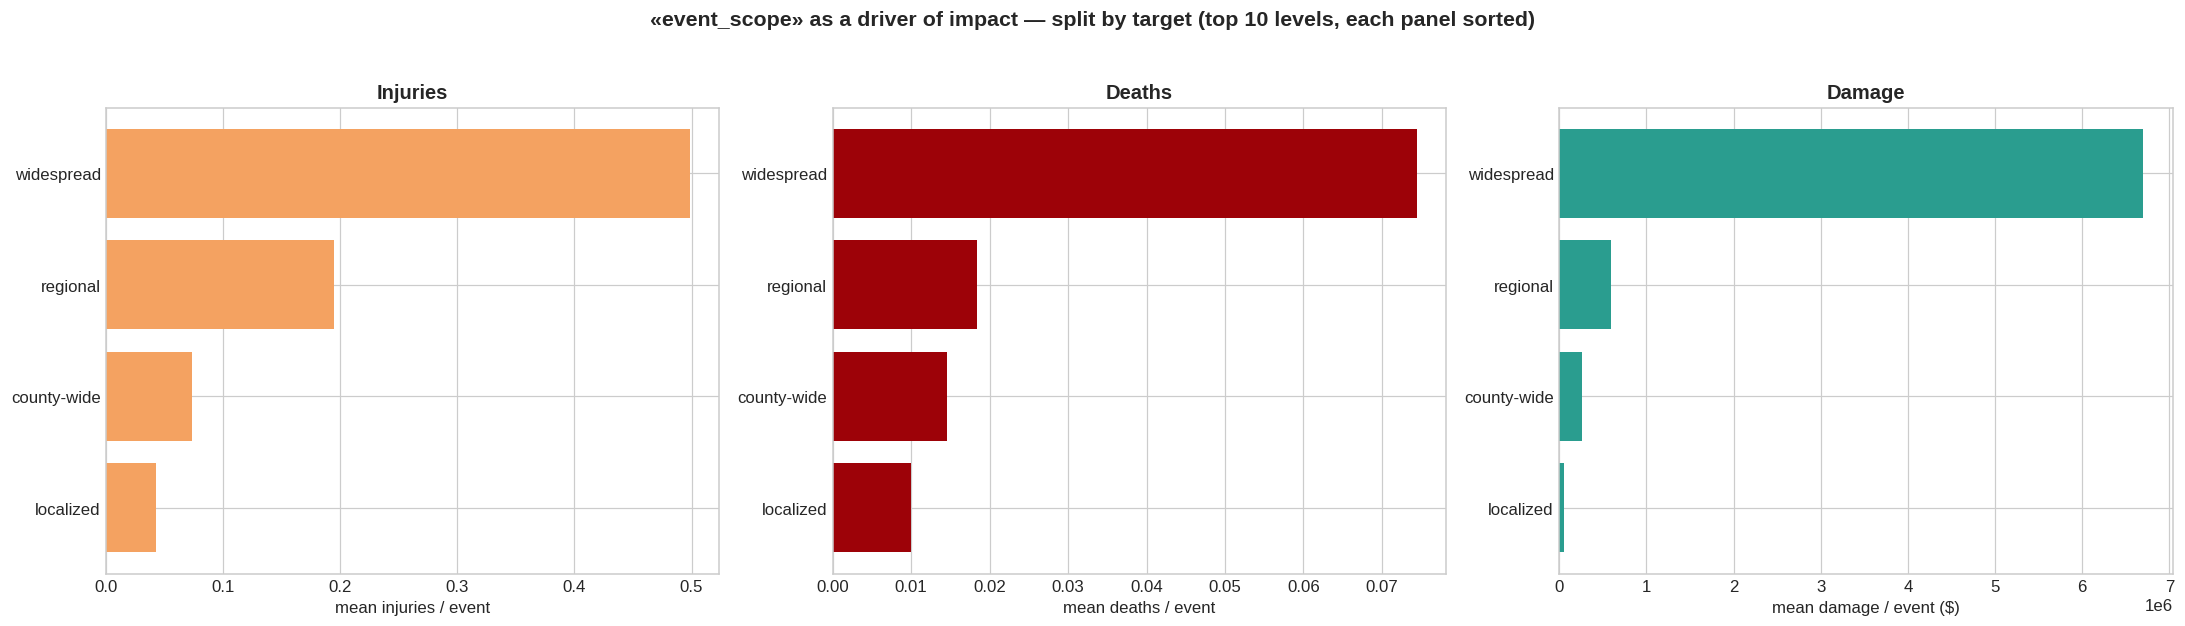

In [31]:
# ── Categorical drivers of impact, split by the 3 targets ────────────
# For each categorical: mean impact PER EVENT across its levels, one panel per target.
cat_drivers = ['STATE','EVENT_TYPE','EVENT_GROUP', 'CZ_TYPE','CZ_NAME','WFO','CZ_TIMEZONE',
               'SOURCE','MAGNITUDE_TYPE', 'TOR_F_SCALE', 'FLOOD_CAUSE','DATA_SOURCE','LOCATION_ORIGIN_DESTINATION',
               'risk', 'impact_type', 'event_scope']

imp = df_1[cat_drivers].copy()
imp['Injuries'] = df_1['INJURIES_DIRECT'] + df_1['INJURIES_INDIRECT']
imp['Deaths']   = df_1['DEATHS_DIRECT']   + df_1['DEATHS_INDIRECT']
imp['Damage']   = df_1['DAMAGE_PROPERTY'] + df_1['DAMAGE_CROPS']

specs = [('Injuries', '#f4a261', 'mean injuries / event'),
         ('Deaths',   '#9d0208', 'mean deaths / event'),
         ('Damage',   '#2a9d8f', 'mean damage / event ($)')]

def cat_vs_targets(cat, top=10):
    g = imp.groupby(cat)[['Injuries', 'Deaths', 'Damage']].mean()
    fig, axes = plt.subplots(1, 3, figsize=(20, max(3.5, 0.55 * top)))
    for ax, (t, color, xl) in zip(axes, specs):
        s = g[t].sort_values(ascending=False).head(top)      # top N by THIS target, descending
        vals = s.to_numpy()[::-1]                            # reverse so the largest lands on top
        labs = [str(v) for v in s.index][::-1]
        ax.barh(labs, vals, color=color)
        ax.set_title(t, fontweight='bold'); ax.set_xlabel(xl)
    fig.suptitle(f'«{cat}» as a driver of impact — split by target (top {top} levels, each panel sorted)',
                 fontsize=14, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.show()

for cat in cat_drivers:
    cat_vs_targets(cat)

## Numerical Drivers on Impacts

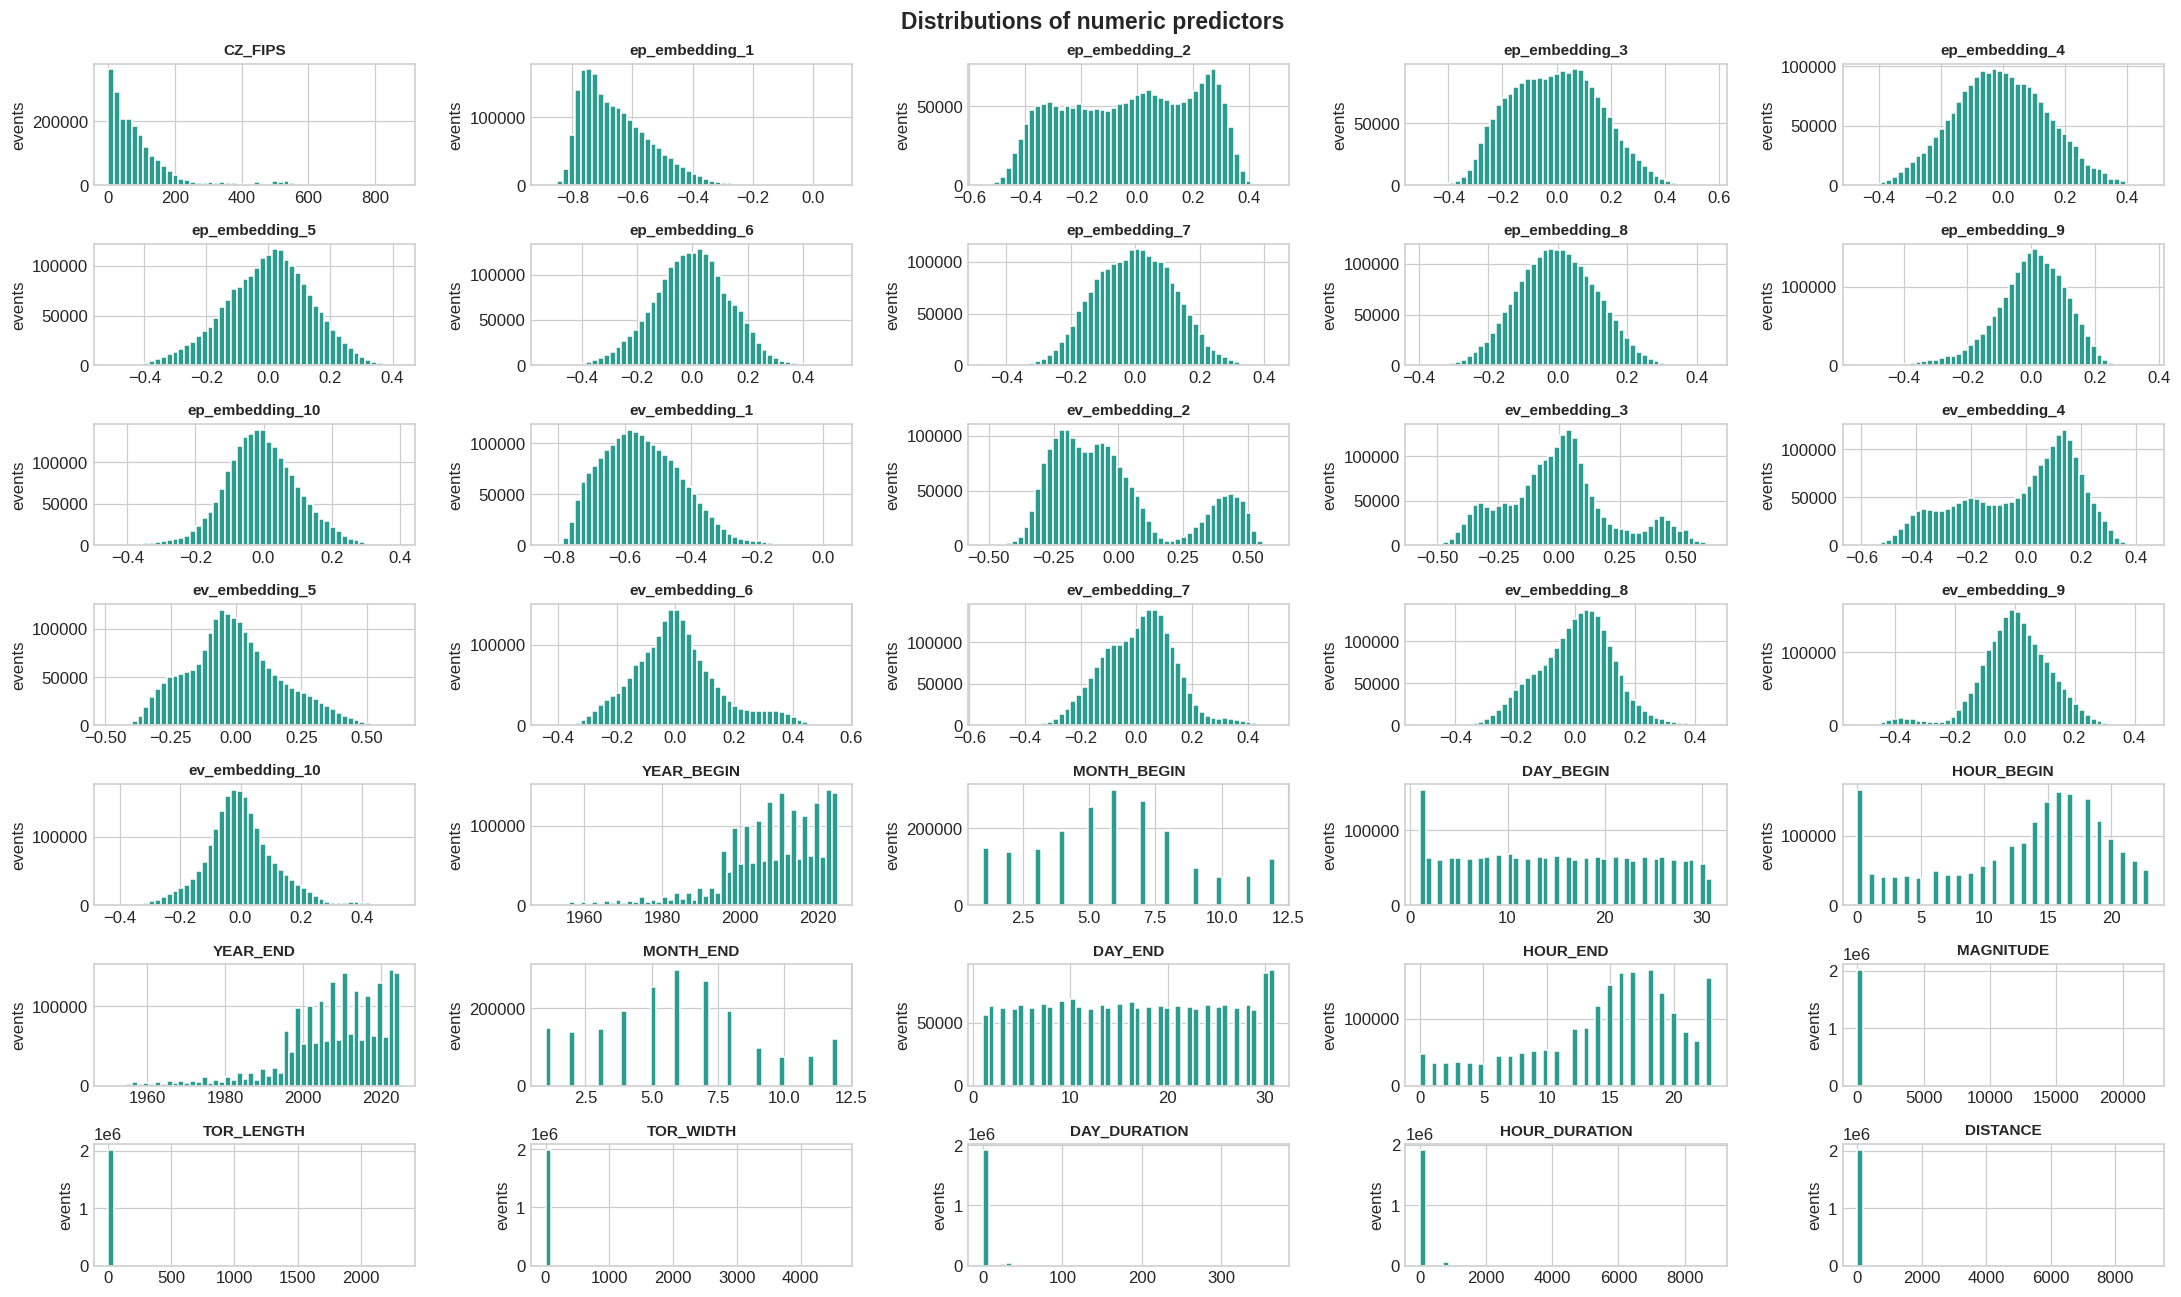

In [32]:
# ── Distributions of numeric predictors ──────────────────────────────
pred_cols = [
'CZ_FIPS',
'ep_embedding_1','ep_embedding_2','ep_embedding_3','ep_embedding_4','ep_embedding_5',
'ep_embedding_6','ep_embedding_7','ep_embedding_8','ep_embedding_9','ep_embedding_10',
'ev_embedding_1','ev_embedding_2','ev_embedding_3','ev_embedding_4','ev_embedding_5',
'ev_embedding_6','ev_embedding_7','ev_embedding_8','ev_embedding_9','ev_embedding_10',
'YEAR_BEGIN','MONTH_BEGIN','DAY_BEGIN','HOUR_BEGIN','YEAR_END','MONTH_END','DAY_END','HOUR_END',
'MAGNITUDE','TOR_LENGTH','TOR_WIDTH','DAY_DURATION','HOUR_DURATION','DISTANCE'
]

fig, axes = plt.subplots(7, 5, figsize=(20, 12))
for ax, col in zip(axes.ravel(), pred_cols):
    v = df_1[col].to_numpy(dtype=float)
    ax.hist(v, bins=50, color='#2a9d8f', edgecolor='white')
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('events')

fig.suptitle('Distributions of numeric predictors', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
# normality test — per column
pred_cols = ['CZ_FIPS',
'ep_embedding_1','ep_embedding_2','ep_embedding_3','ep_embedding_4','ep_embedding_5',
'ep_embedding_6','ep_embedding_7','ep_embedding_8','ep_embedding_9','ep_embedding_10',
'ev_embedding_1','ev_embedding_2','ev_embedding_3','ev_embedding_4','ev_embedding_5',
'ev_embedding_6','ev_embedding_7','ev_embedding_8','ev_embedding_9','ev_embedding_10',
'YEAR_BEGIN','MONTH_BEGIN','DAY_BEGIN','HOUR_BEGIN','YEAR_END','MONTH_END','DAY_END','HOUR_END',
'MAGNITUDE','TOR_LENGTH','TOR_WIDTH','DAY_DURATION','HOUR_DURATION','DISTANCE']
df_inj = pd.concat([df_1[pred_cols], df_1[INJURY_TARGETS]], axis=1)
df_death=pd.concat([df_1[pred_cols], df_1[DEATH_TARGETS]], axis=1)
df_damage=pd.concat([df_1[pred_cols], df_1[DAMAGE_TARGETS]], axis=1)

def normality_test(data):
    rng = np.random.default_rng(0)
    rows = []
    for c in data.columns:
        x = data[c].to_numpy(dtype='float64', na_value=np.nan)
        x = x[~np.isnan(x)]
        if len(x) < 3:
            continue
        xs = x if len(x) <= 5000 else rng.choice(x, 5000, replace=False)
        stat, pval = shapiro(xs)
        rows.append({'column': c, 'W': round(stat, 3), 'p': pval,
                 'verdict': 'Gaussian' if pval > 0.05 else 'non-Gaussian'})

    norm = pd.DataFrame(rows).set_index('column')

    n_non = int((norm['verdict'] == 'non-Gaussian').sum())
    corr_method = 'pearson' if n_non == 0 else 'spearman'
    print(f'\n{n_non}/{len(norm)} columns non-Gaussian  ->  use {corr_method}')

In [34]:
normality_test(df_inj)


37/37 columns non-Gaussian  ->  use spearman


In [35]:
normality_test(df_death)


37/37 columns non-Gaussian  ->  use spearman


In [36]:
normality_test(df_damage)


37/37 columns non-Gaussian  ->  use spearman


In [37]:
# corr heatmap
def corr_heatmap(data, label):
    corr_matrix = data.corr(method='spearman')
    labels = list(corr_matrix.columns)

    fig, ax = plt.subplots(figsize=(20, 20))
    sns.heatmap(corr_matrix.to_numpy(),
            xticklabels=labels, yticklabels=labels,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'shrink': 0.6, 'label': 'Spearman ρ'}, ax=ax)
    ax.set_title(f'Correlation Heatmap with TARGET {label}', size=20, pad=16)
    plt.xticks(fontsize=12, rotation=90)
    plt.yticks(fontsize=12, rotation=0)
    plt.tight_layout()
    plt.show()

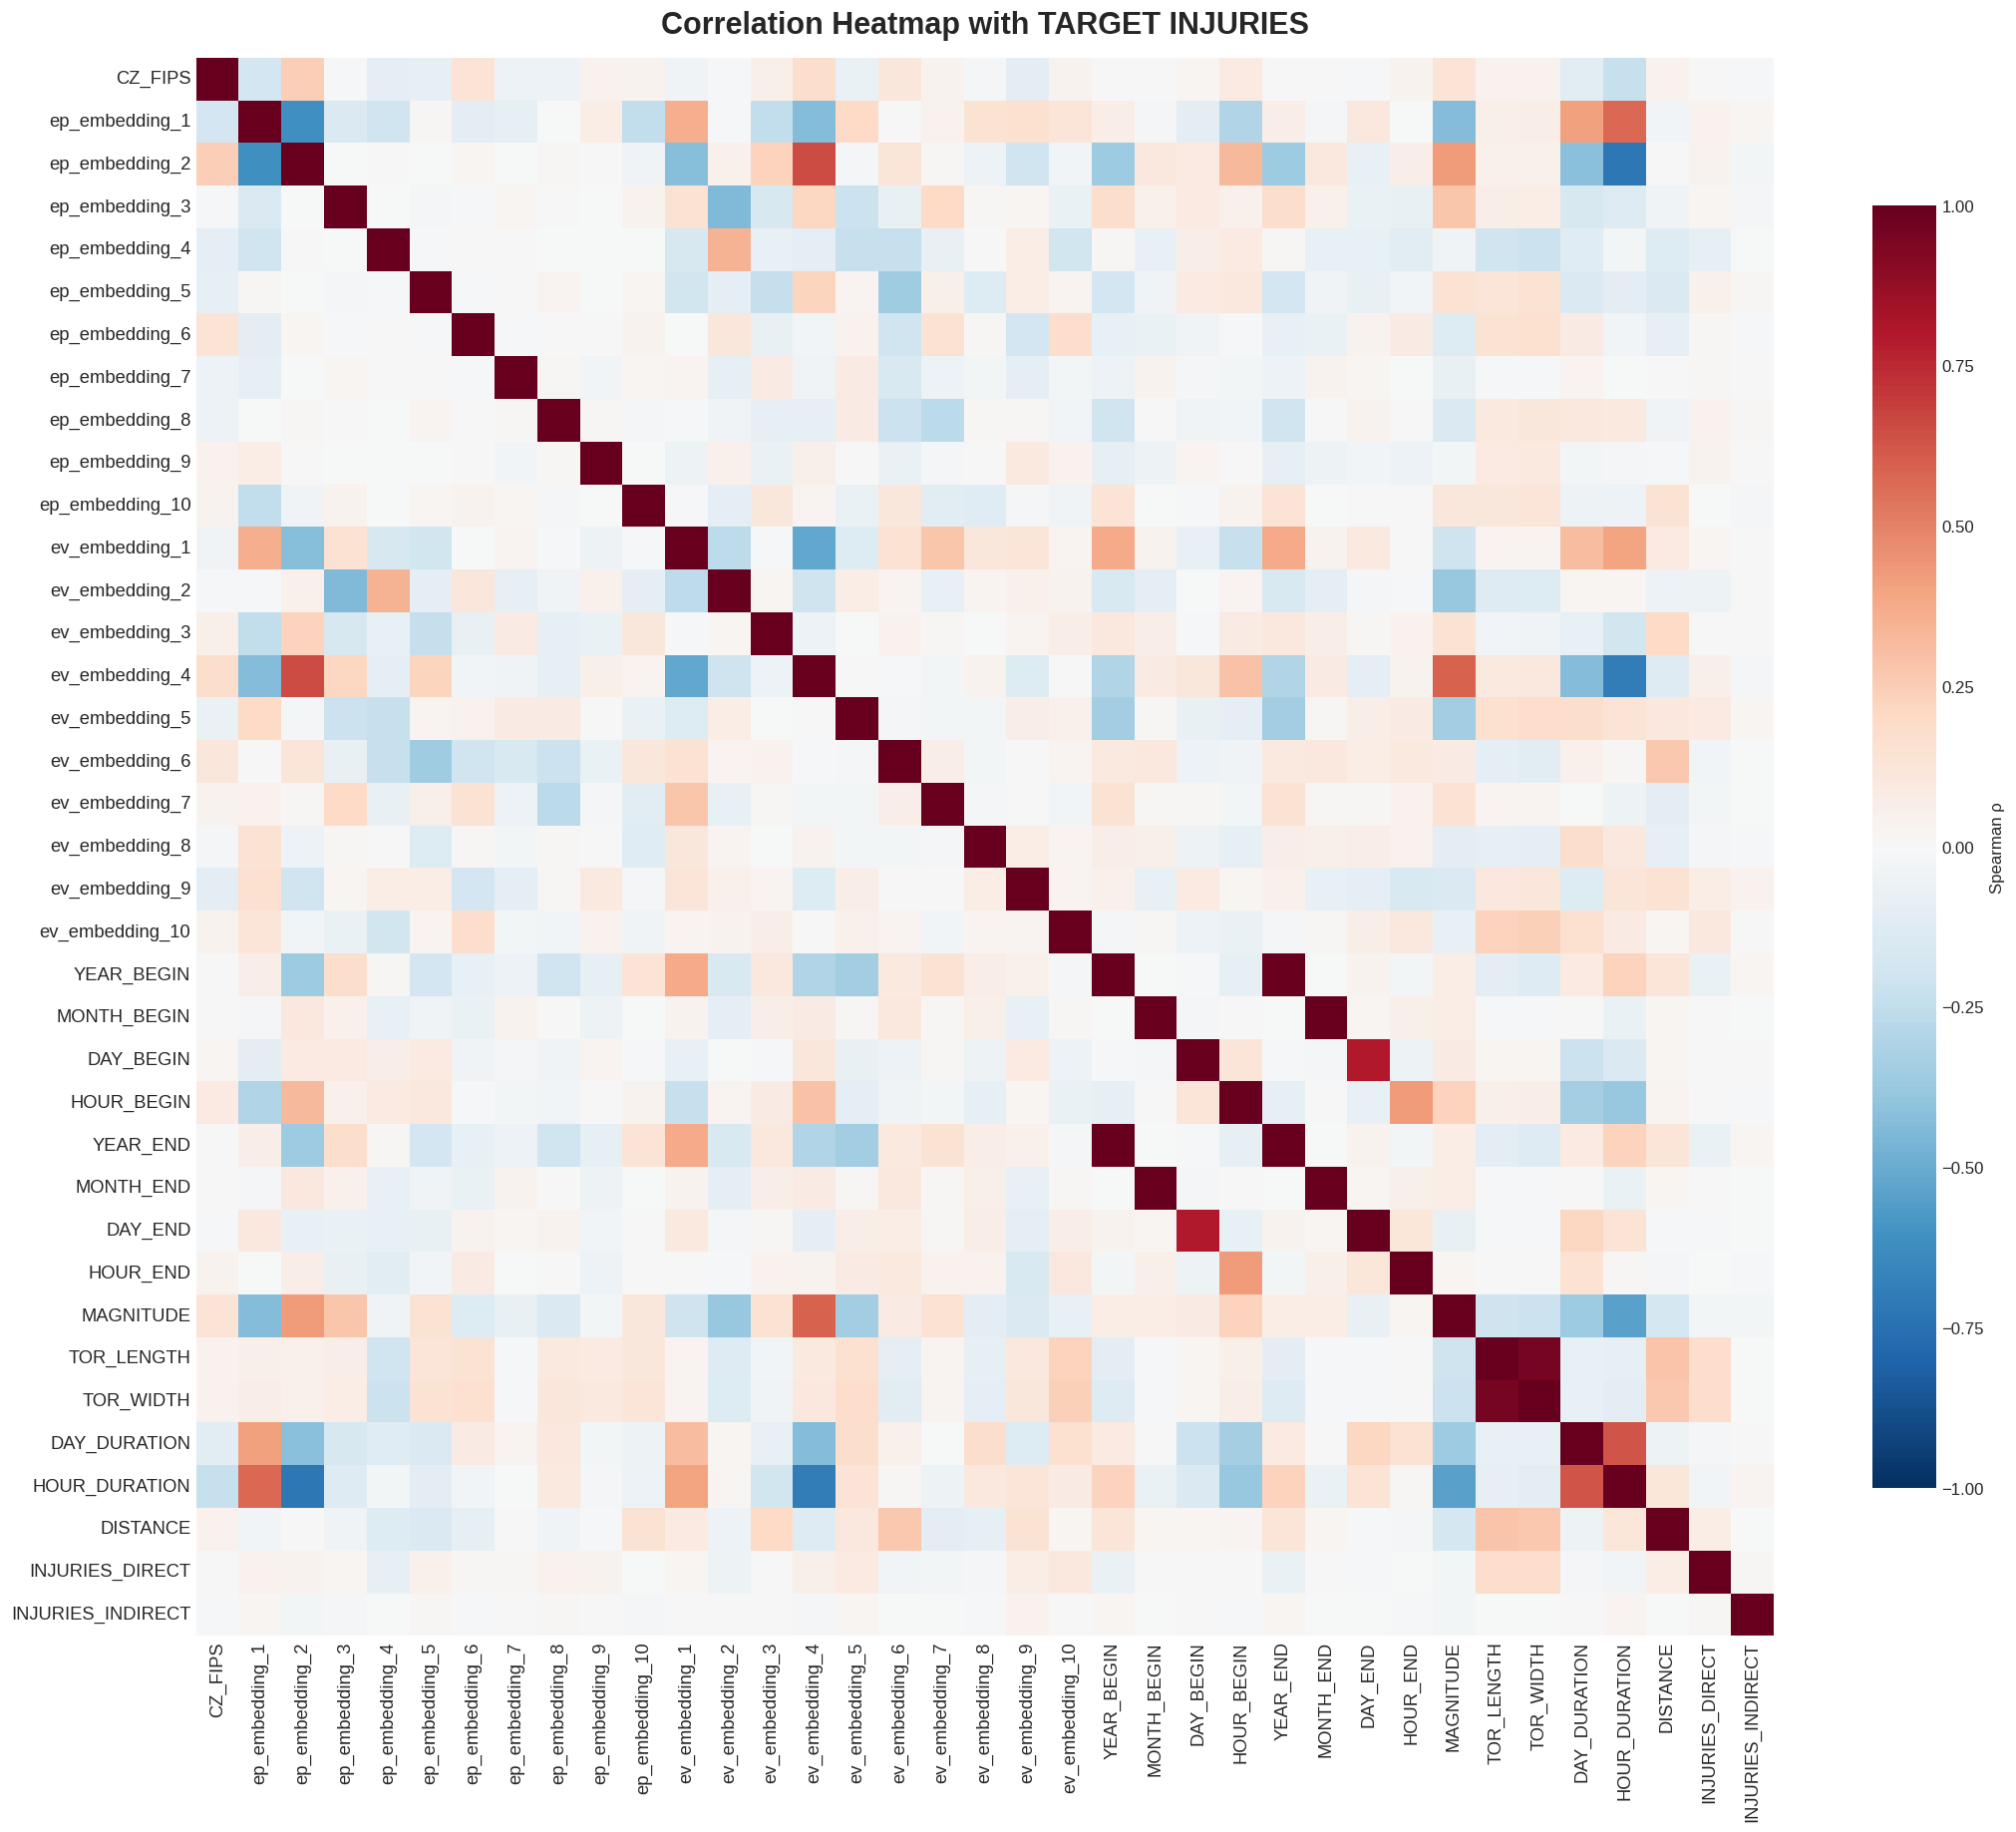

In [38]:
corr_heatmap(df_inj, label='INJURIES')

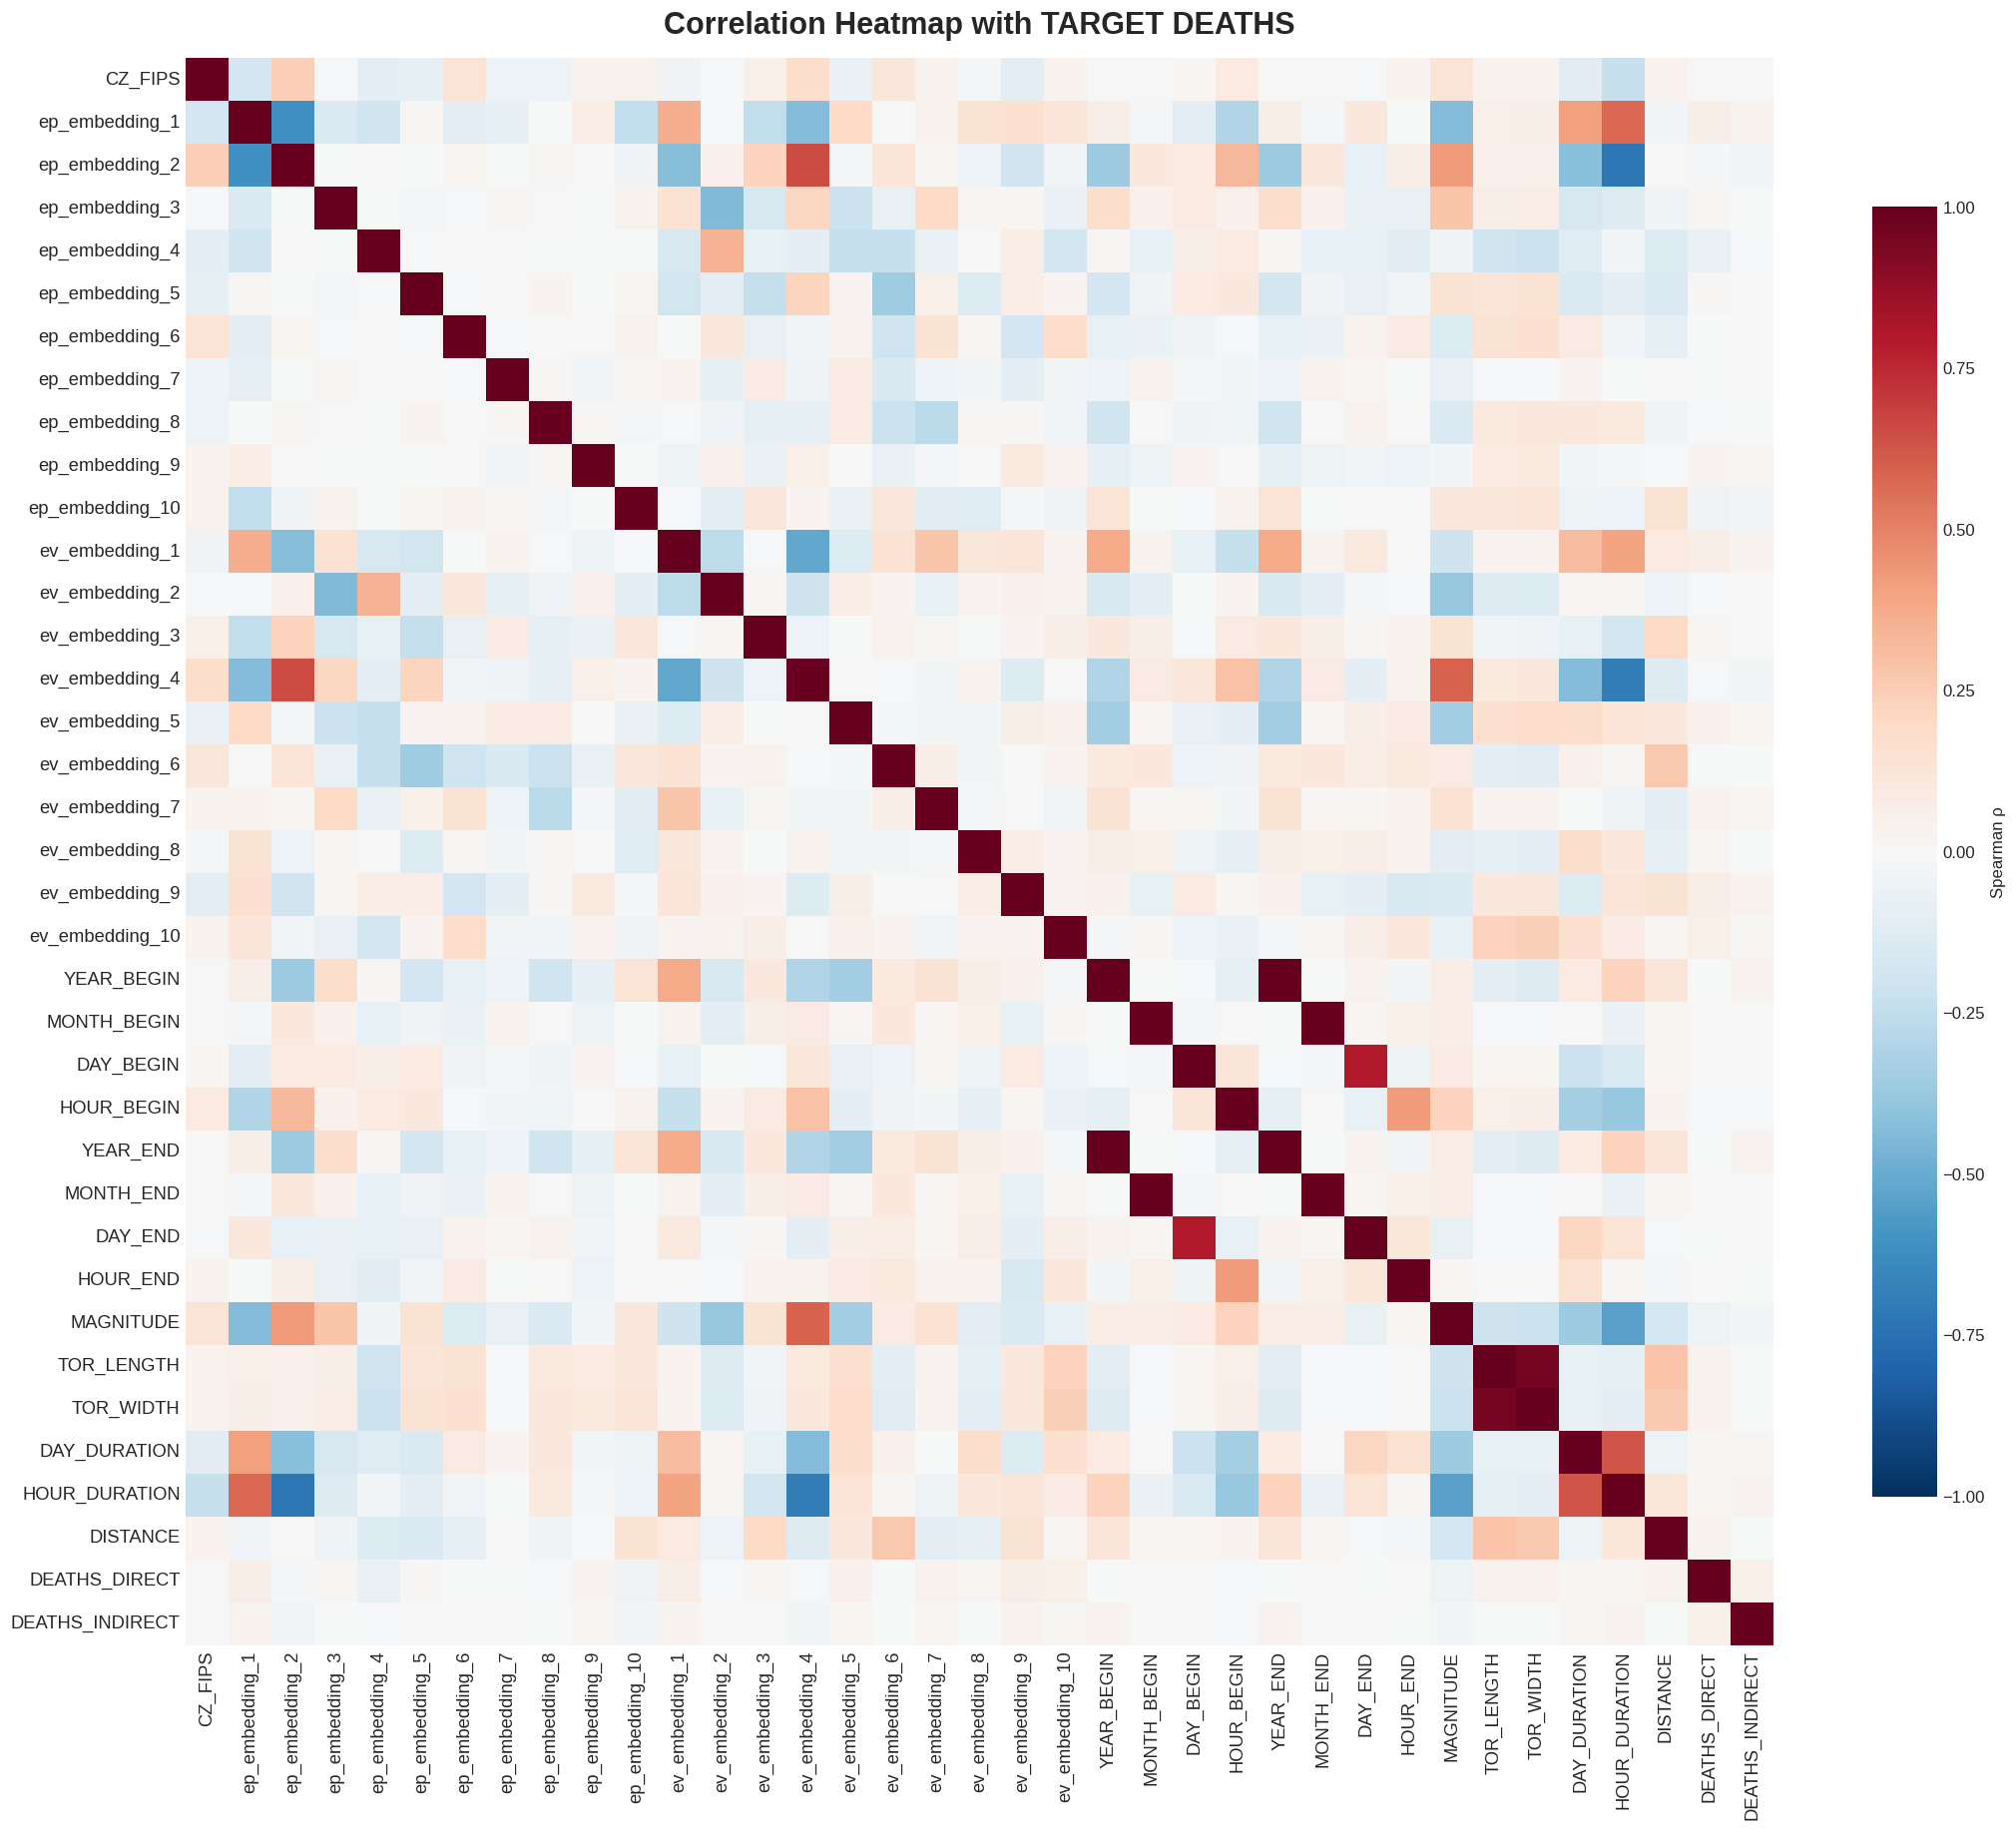

In [39]:
corr_heatmap(df_death, label='DEATHS')

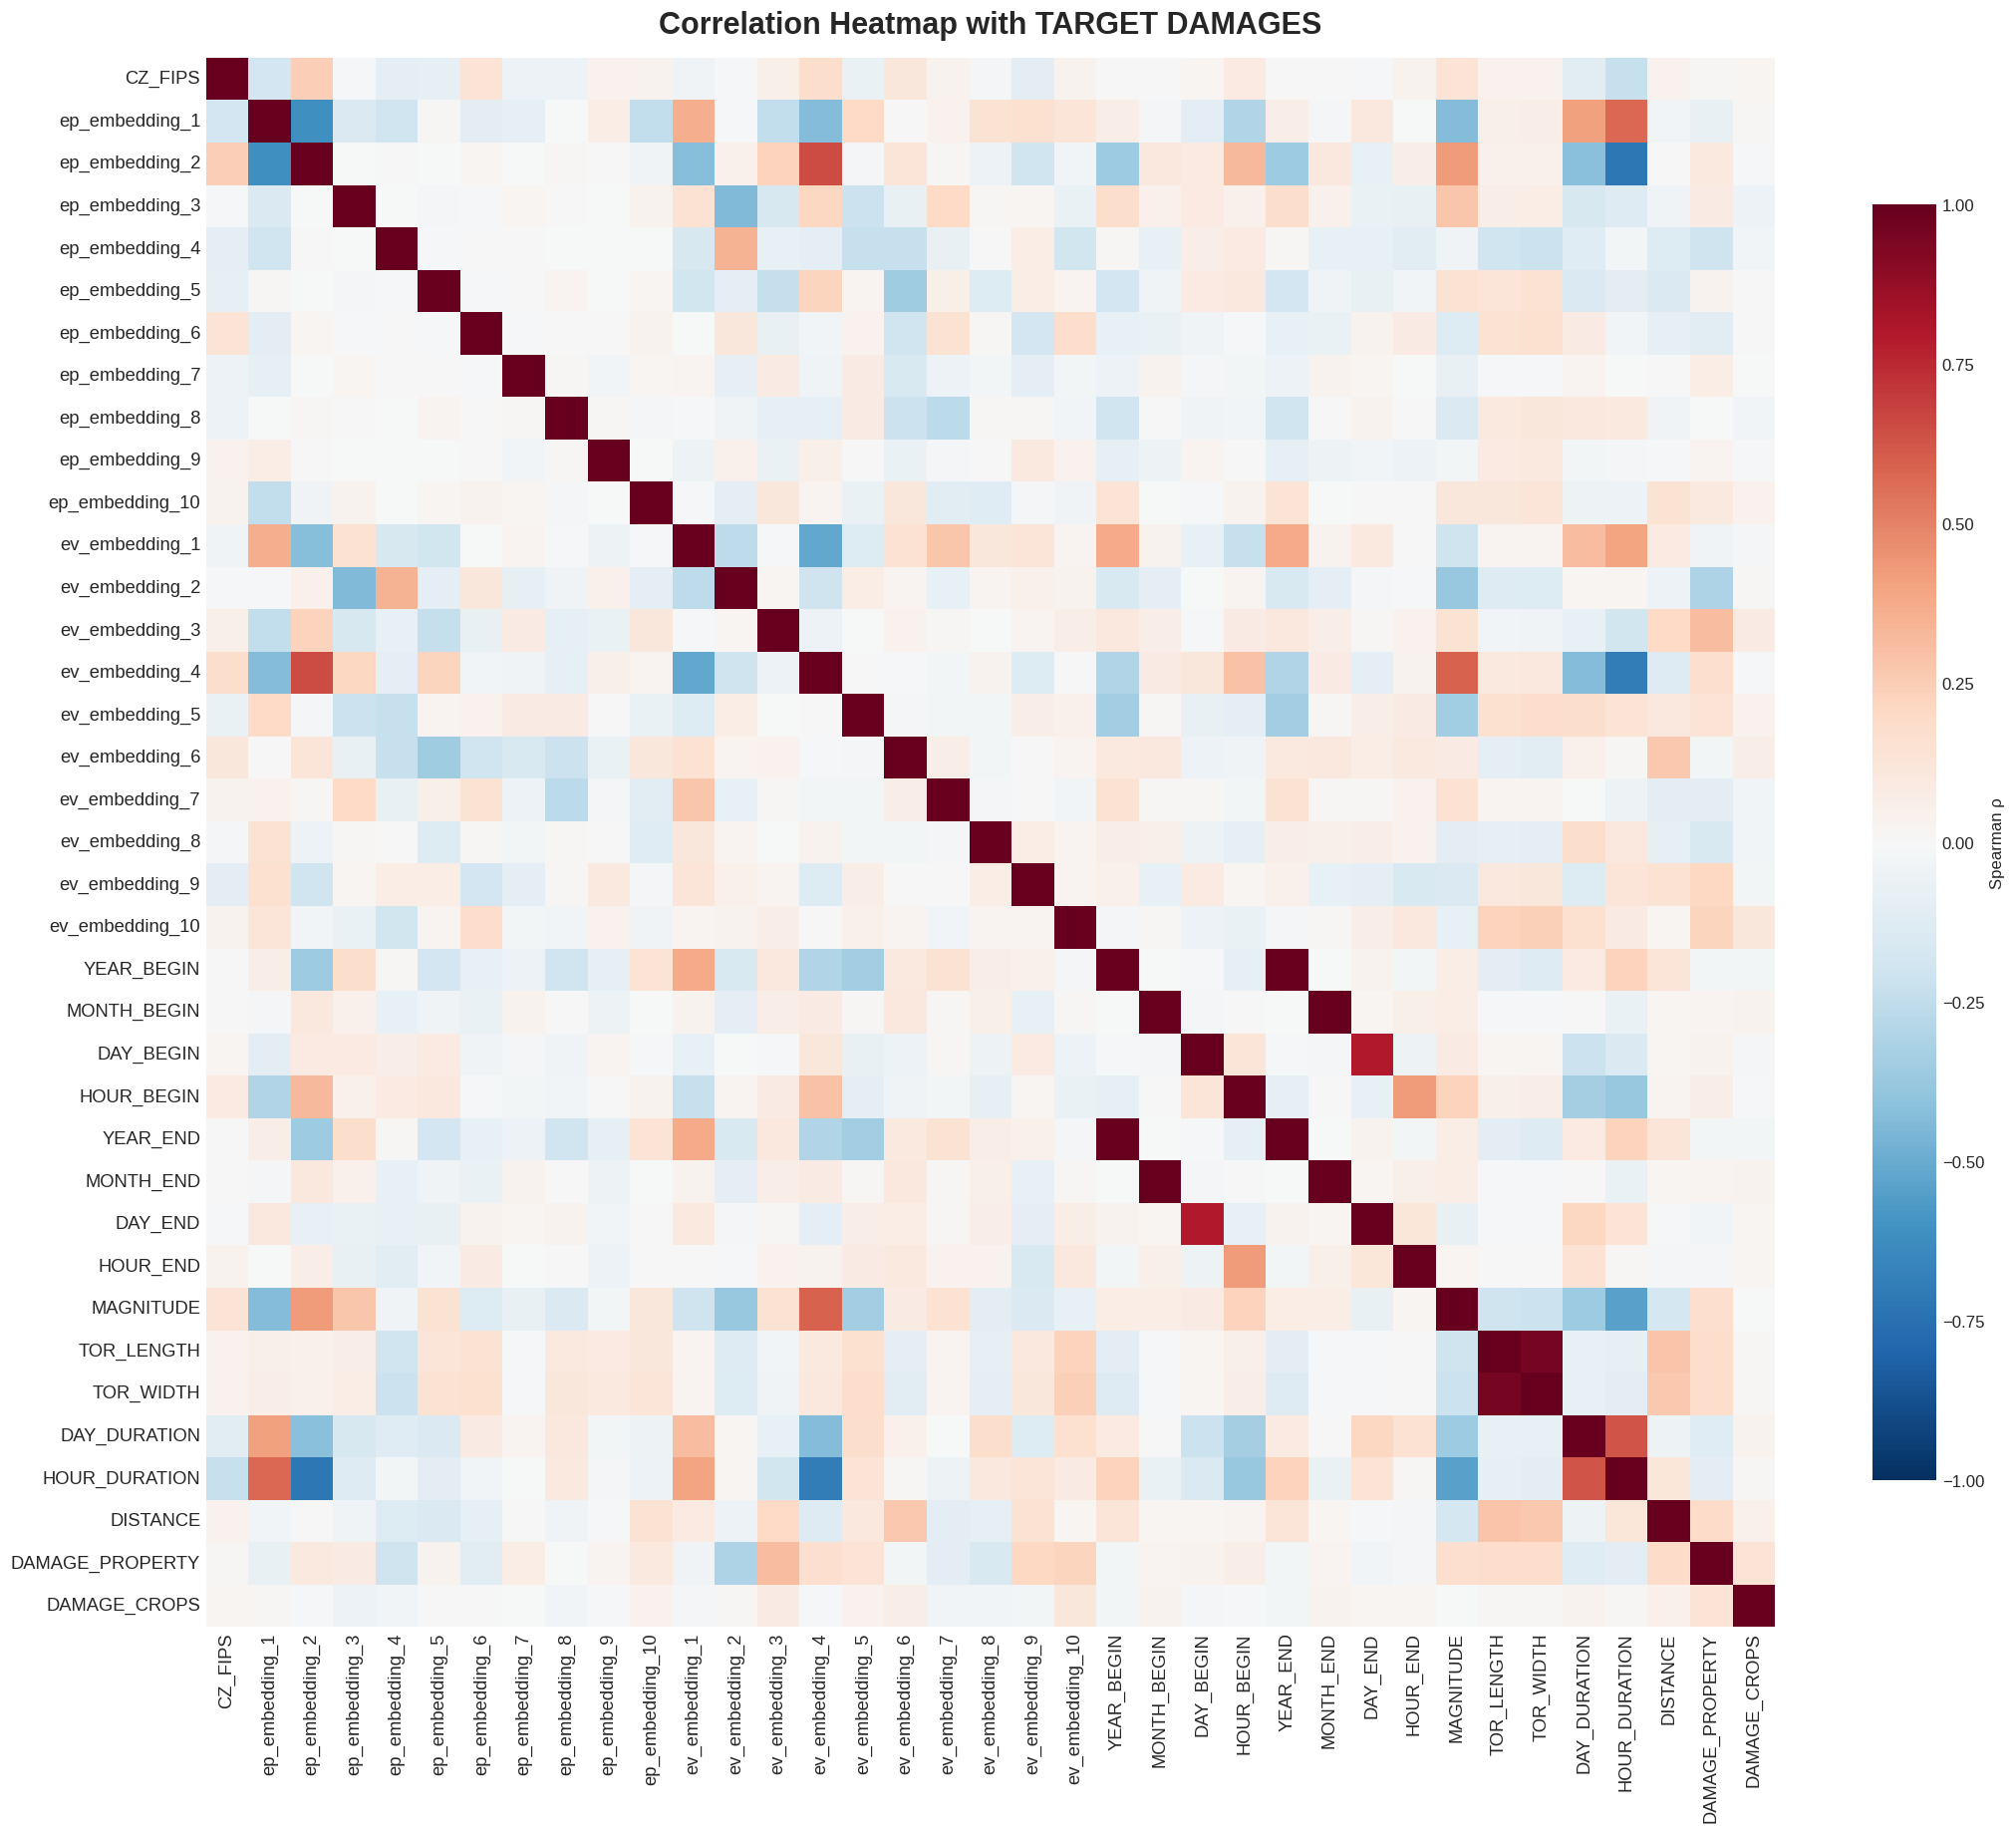

In [40]:
corr_heatmap(df_damage, label='DAMAGES')

## Narrative Text Analysis

In [41]:
# ── Word Cloud from EVENT_NARRATIVE ──────────────────
def text_wordcloud(data, label):
    narratives = data[label].dropna()
    # Sample to keep it manageable
    sample_narr = narratives.sample(n=min(50_000, len(narratives)), random_state=0)
    text = ' '.join(sample_narr.values)

    wc = WordCloud(width=1200, height=600, max_words=150,
               background_color='white', colormap='inferno',
               collocations=False, random_state=42).generate(text)

    fig, ax = plt.subplots(figsize=(16, 8))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud — {label}', fontsize=16, pad=15)
    plt.tight_layout()
    plt.show()

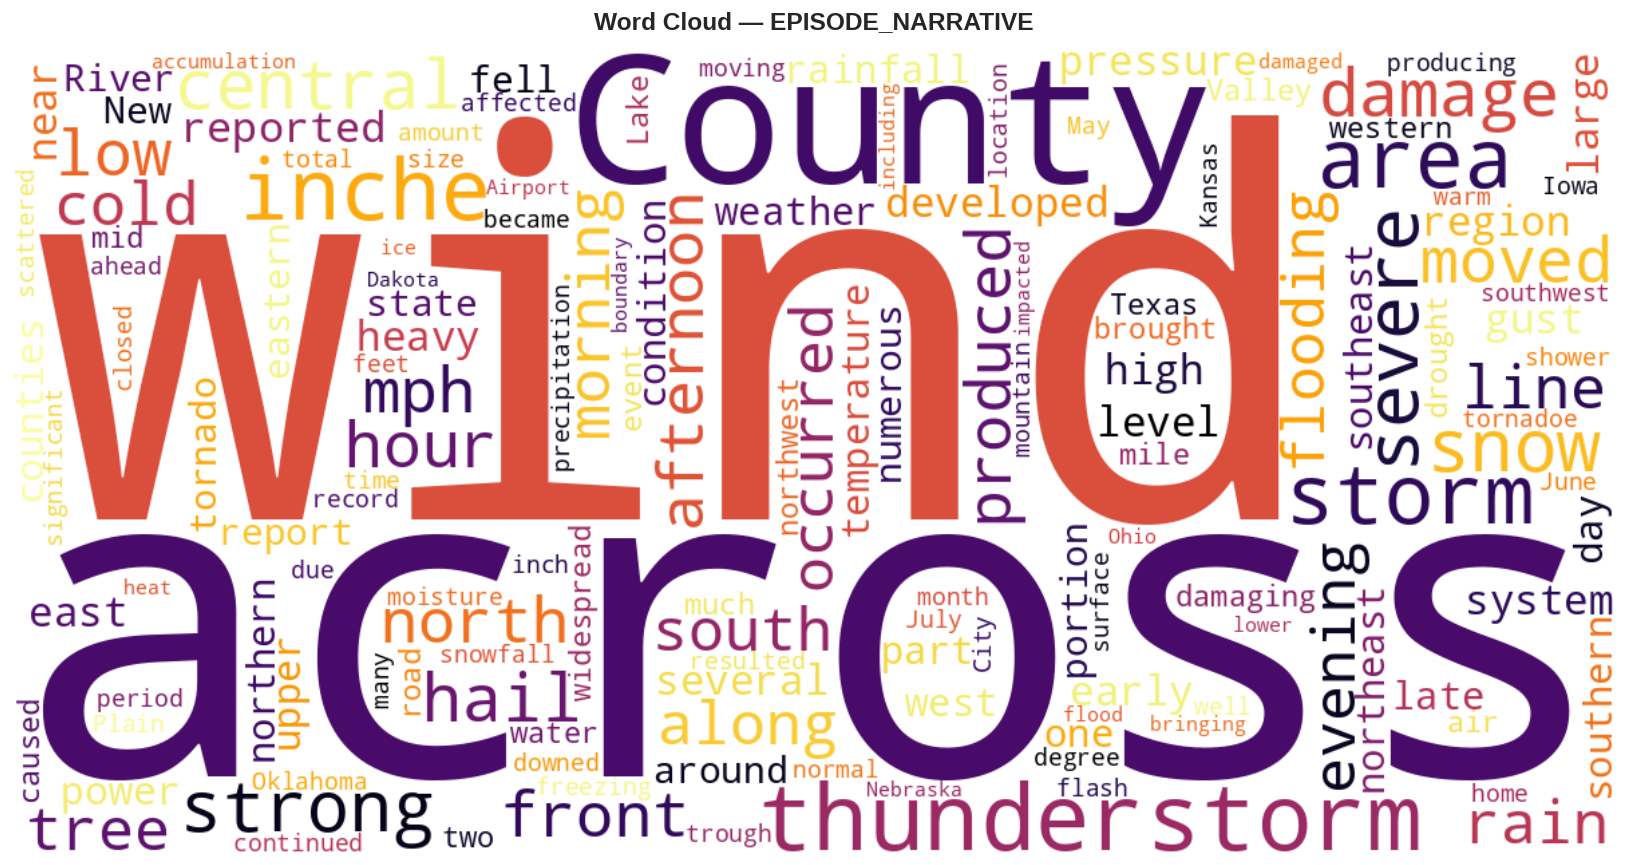

In [42]:
text_wordcloud(df_1, label='EPISODE_NARRATIVE')

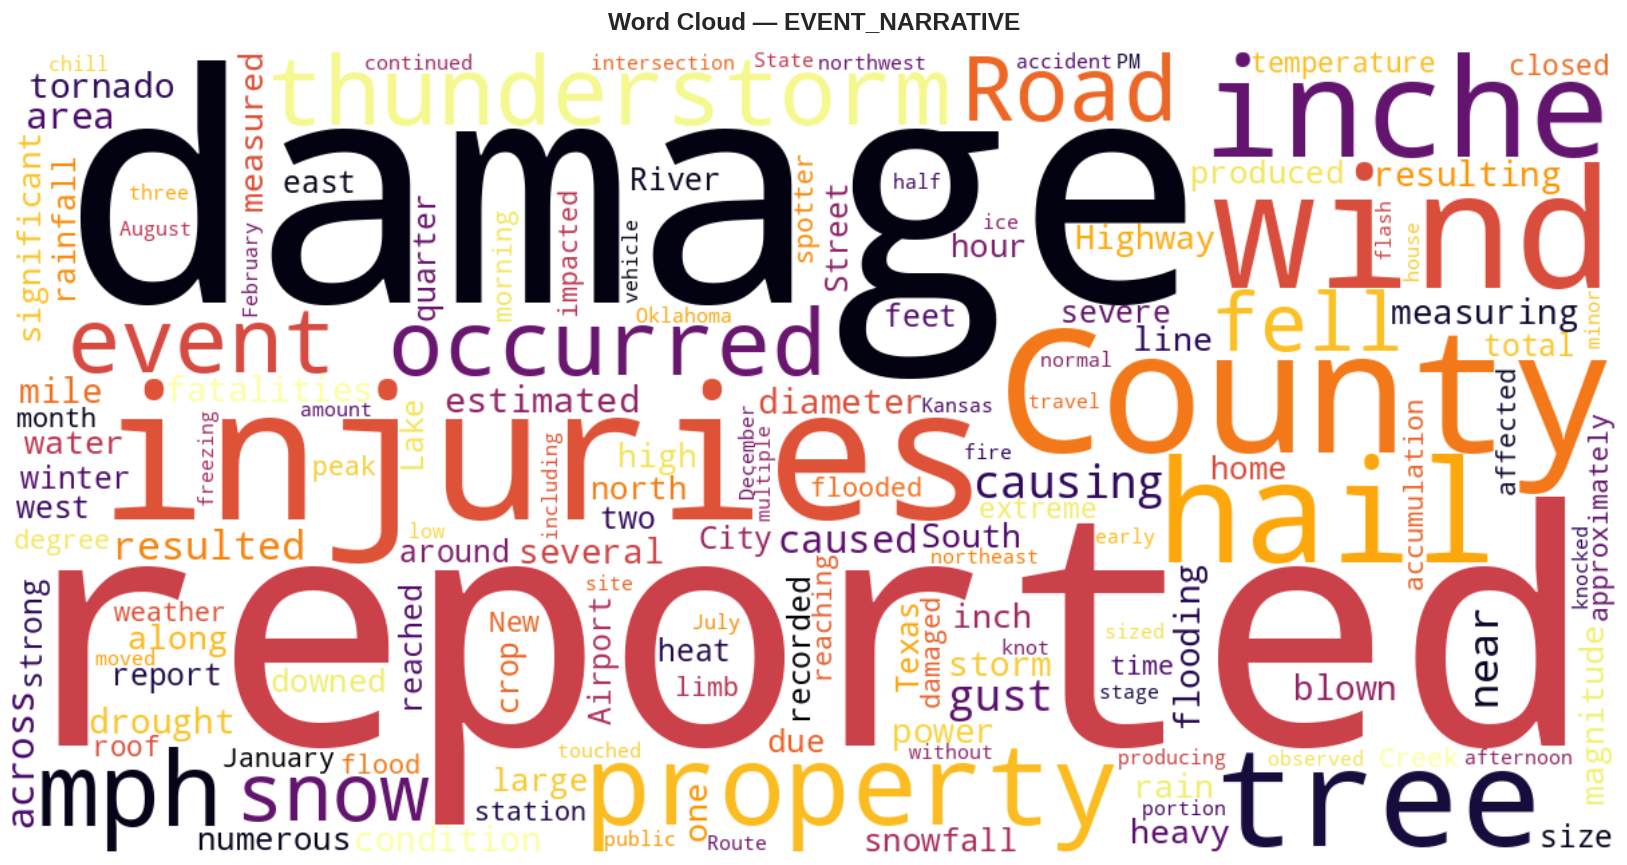

In [43]:
text_wordcloud(df_1, label='EVENT_NARRATIVE')

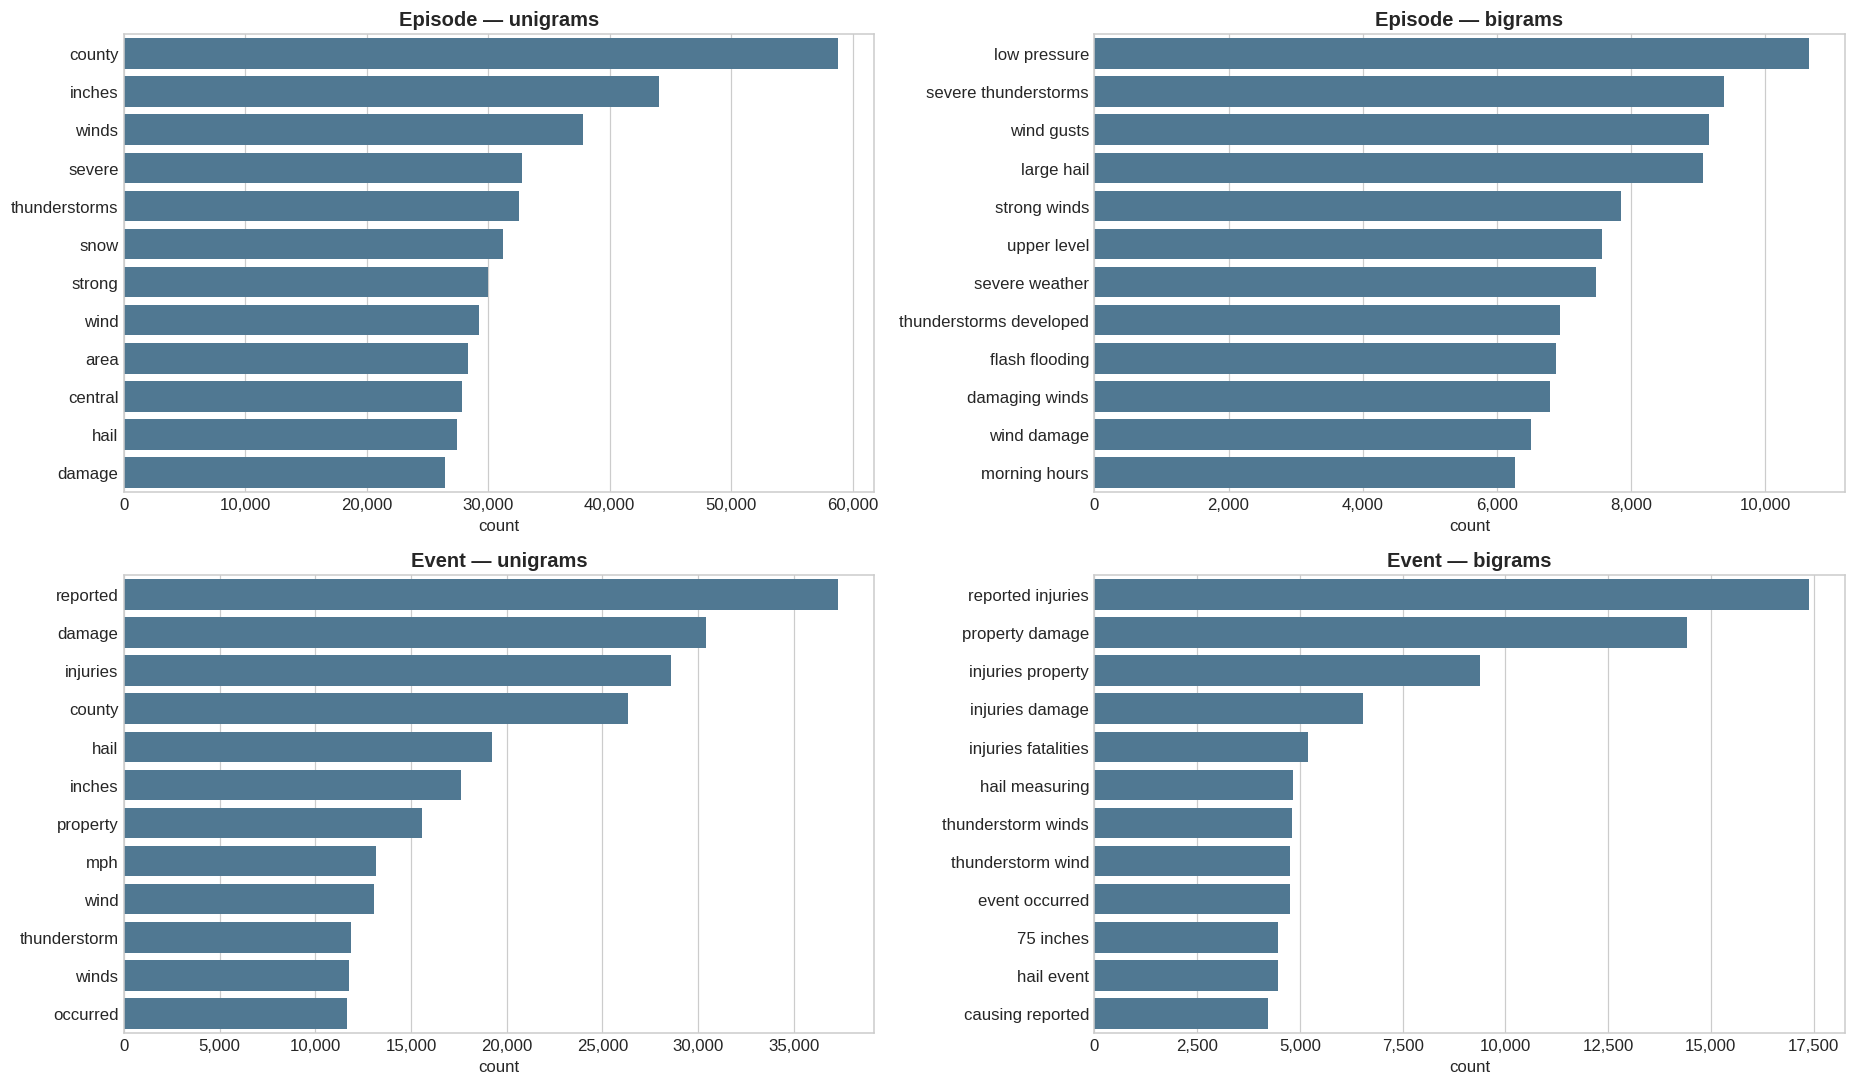

In [44]:
def top_ngrams(corpus, n=12, ngram=1, sample=80_000):
    corpus = corpus.dropna()
    if len(corpus) > sample:
        corpus = corpus.sample(sample, random_state=0)
    docs = corpus.tolist()                       # plain Python strings
    vec = CountVectorizer(ngram_range=(ngram, ngram), stop_words='english', max_features=4000)
    bag = vec.fit_transform(docs)
    freqs = np.asarray(bag.sum(axis=0)).ravel()
    vocab = np.array(vec.get_feature_names_out())
    idx = freqs.argsort()[::-1][:n]
    return pd.DataFrame({'term': vocab[idx], 'count': freqs[idx]})

fig, axes = plt.subplots(2, 2, figsize=(17, 10))
specs = [('EPISODE_NARRATIVE', 1, 'Episode — unigrams'),
         ('EPISODE_NARRATIVE', 2, 'Episode — bigrams'),
         ('EVENT_NARRATIVE',   1, 'Event — unigrams'),
         ('EVENT_NARRATIVE',   2, 'Event — bigrams')]
for ax, (col, ng, title) in zip(axes.ravel(), specs):
    d = top_ngrams(df_1[col], n=12, ngram=ng)
    sns.barplot(data=d, y='term', x='count', ax=ax, color='#457b9d')
    ax.set_title(title); ax.set_ylabel('')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout(); plt.show()

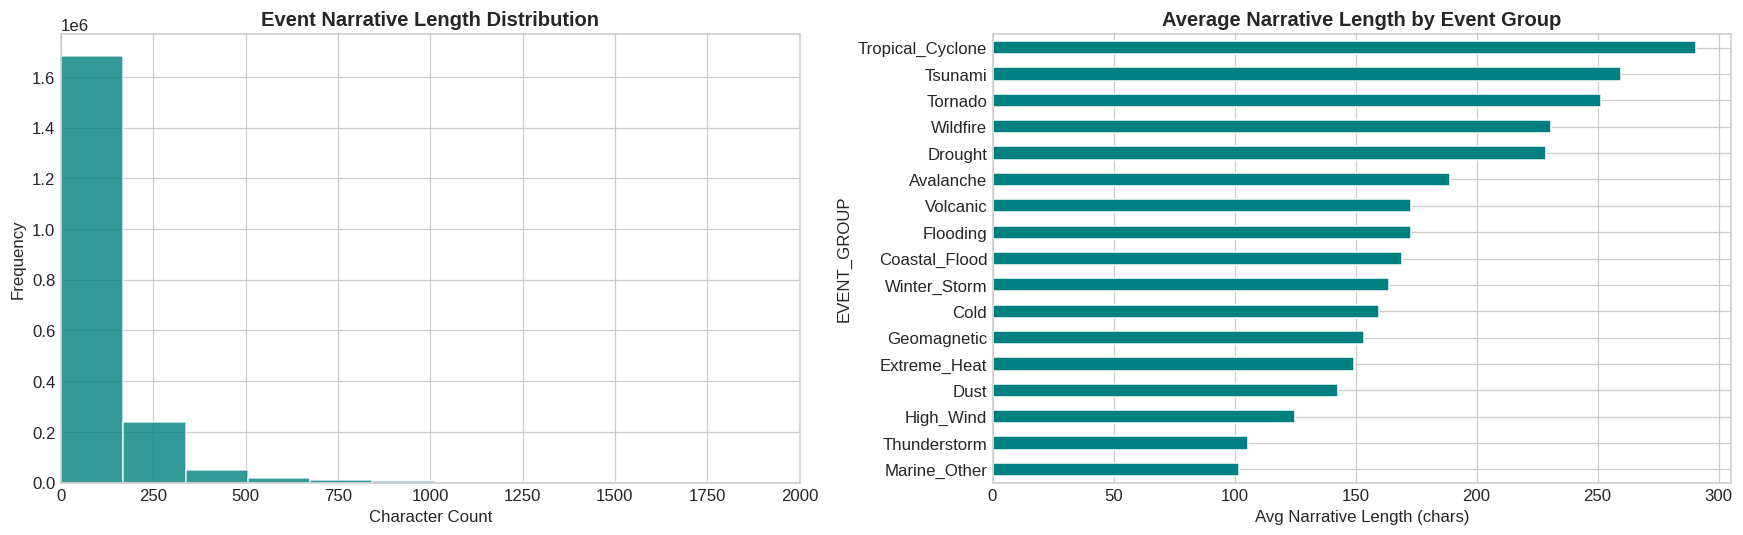

In [45]:
# ── Narrative length analysis ────────────────────────
df_1['NARRATIVE_LEN'] = df_1['EVENT_NARRATIVE'].fillna('').str.len()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df_1.loc[df_1['NARRATIVE_LEN'] > 0, 'NARRATIVE_LEN'],
             bins=80, color='teal', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Event Narrative Length Distribution')
axes[0].set_xlim(0, 2000)

narr_by_group = df_1.groupby('EVENT_GROUP')['NARRATIVE_LEN'].mean().sort_values(ascending=True)
narr_by_group.plot.barh(ax=axes[1], color='teal', edgecolor='white')
axes[1].set_xlabel('Avg Narrative Length (chars)')
axes[1].set_title('Average Narrative Length by Event Group')

plt.tight_layout()
plt.show()

In [46]:
# ── Notebook run timer — END ─────────────────────────────────────────
NB_END_WALL = datetime.now()
elapsed = time.perf_counter() - NB_START
h, rem = divmod(elapsed, 3600)
m, s = divmod(rem, 60)
print(f'Notebook started : {NB_START_WALL:%Y-%m-%d %H:%M:%S}')
print(f'Notebook finished: {NB_END_WALL:%Y-%m-%d %H:%M:%S}')
print(f'Total run time   : {int(h)}h {int(m)}m {s:.1f}s   ({elapsed:,.1f} seconds)')

Notebook started : 2026-08-08 09:40:18
Notebook finished: 2026-08-08 09:44:39
Total run time   : 0h 4m 21.0s   (261.0 seconds)
